# 03 — LP Optimization & Results

Goals:
- Define battery parameters (SOFAR ME3000SP, BYD LFP 5 kWh / 3 kW)
- Solve LP optimization day-by-day over 522 days of real household data
- Compare strategies: LP optimal (dag/nacht & EPEX+markup), rule-based threshold, real SOFAR inverter
- Compute monthly-normalised annual savings in EUR

## 0. Imports & configuration

In [2]:
import sys
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import warnings
warnings.filterwarnings("ignore")
_nb_dir = Path(globals()["__vsc_ipynb_file__"]).parent
_src    = (_nb_dir / "../src").resolve()
sys.path.insert(0, str(_src))
from solar_utils import optimize_day, threshold_strategy, backtest

plt.rcParams.update({"figure.dpi": 120,
                     "axes.grid": True,
                     "grid.alpha": 0.3,
                     "axes.spines.top": False,
                     "axes.spines.right": False})

DATA_FILE = "../../Data/real_load/Final/optimization_input.csv"

# Battery — SOFAR ME3000SP
S_MAX  = 5.0   # kWh — usable capacity
P_KW   = 3.0   # kW  — max charge/discharge power
P_MAX  = P_KW * 0.25  # kWh per 15-min slot
ETA_C  = 0.97; ETA_D = 0.97
S_MIN  = 0.10 * S_MAX; S_INIT = 0.50 * S_MAX
DEG    = 0.10  # EUR/kWh = 3000 / (6000 EFC * 5 kWh)  — corrected for S_MAX=5 kWh

# Tariff parameters
MARKUP      = 0.17  # EUR/kWh added to EPEX wholesale for all-in dynamic price
PRICE_DAG   = 0.30  # EUR/kWh all-in day tariff
PRICE_NACHT = 0.22  # EUR/kWh all-in night tariff
PRICE_INJ   = 0.0   # EUR/kWh injection rate — no selling back to grid
print("S_max:", S_MAX, "kWh | P_max:", P_MAX, "kWh/slot | deg:", DEG, "EUR/kWh")
print("MARKUP:", MARKUP, "euro | Dag price:", PRICE_DAG, "| Nacht price:", PRICE_NACHT, "| Inj price:", PRICE_INJ)
print("src:", _src)

def monthly_annual(series):
    """Annual EUR estimate via calendar-month normalisation.
    Each month averaged across all available years — no data discarded."""
    s = series.dropna().copy()
    s.index = pd.to_datetime(s.index)
    avg  = s.groupby(s.index.month).mean()
    days = {1:31, 2:28.25, 3:31, 4:30, 5:31, 6:30,
            7:31,  8:31,  9:30, 10:31, 11:30, 12:31}
    return sum(avg.get(m, 0.0) * days[m] for m in range(1, 13))

S_max: 5.0 kWh | P_max: 0.75 kWh/slot | deg: 0.1 EUR/kWh
MARKUP: 0.17 euro | Dag price: 0.3 | Nacht price: 0.22 | Inj price: 0.0
src: C:\Users\ummsa\DataScientist_Syntra\Stage\DinamischeTarief\battery-optimization-belgium\personal_optimization\src


## 1. Load data

In [3]:
# Columns: price_eur_kwh, tarief, verbruik_kwh, ev_energie_kwh (ref),
#          sl_productie_kwh, afname_kwh, injectie_kwh, bat_laden_kwh_kw, bat_ontladen_kwh_kw
df = pd.read_csv(DATA_FILE, parse_dates=["kwartier"], index_col="kwartier")
df = df.sort_index()
df["price_dag_nacht"] = df["tarief"].map({"dag": PRICE_DAG, "nacht": PRICE_NACHT})
df["price_allin"] = df["price_eur_kwh"] + MARKUP
print(f"Rows: {len(df):,}  Range: {df.index.min()} -> {df.index.max()}")
print(f"Tarief NaN: {df['price_dag_nacht'].isna().sum()}")
print(df[["price_eur_kwh", "price_dag_nacht", "price_allin", "verbruik_kwh"]].describe().round(4))
prices_df    = df[["price_eur_kwh"]].copy()
prices_dn_df = df[["price_dag_nacht"]].rename(columns={"price_dag_nacht": "price_eur_kwh"})
load_df      = df.rename(columns={"verbruik_kwh": "consumption"})[["consumption"]].copy()
solar_df        = df.rename(columns={"sl_productie_kwh": "solar"})[["solar"]].copy()
prices_allin_df = df[["price_allin"]].rename(columns={"price_allin": "price_eur_kwh"})
print(f"prices_df: {len(prices_df):,} | prices_dn_df: {len(prices_dn_df):,} | load: {len(load_df):,} | solar: {len(solar_df):,}")

Rows: 50,112  Range: 2024-11-01 00:00:00 -> 2026-04-06 23:45:00
Tarief NaN: 0
       price_eur_kwh  price_dag_nacht  price_allin  verbruik_kwh
count     50112.0000       50112.0000   50112.0000    50112.0000
mean          0.0876           0.2538       0.2576        0.1779
std           0.0481           0.0395       0.0481        0.1645
min          -0.5135           0.2200      -0.3435        0.0000
25%           0.0670           0.2200       0.2370        0.0670
50%           0.0908           0.2200       0.2608        0.1450
75%           0.1138           0.3000       0.2838        0.2500
max           0.5858           0.3000       0.7558        1.6040
prices_df: 50,112 | prices_dn_df: 50,112 | load: 50,112 | solar: 50,112


## 2. LP solver — single day

Date: 2025-05-20  (96 slots)
Solar total: 3.94 kWh  |  Load total: 9.60 kWh

                                         EUR
--------------------------------------------
Baseline (solar, no battery)          0.9926
LP — grid bill                        0.5217  (saving +0.4709)
LP — battery wear                     0.3966
LP — net saving                       0.0743
Threshold — net saving                0.0636


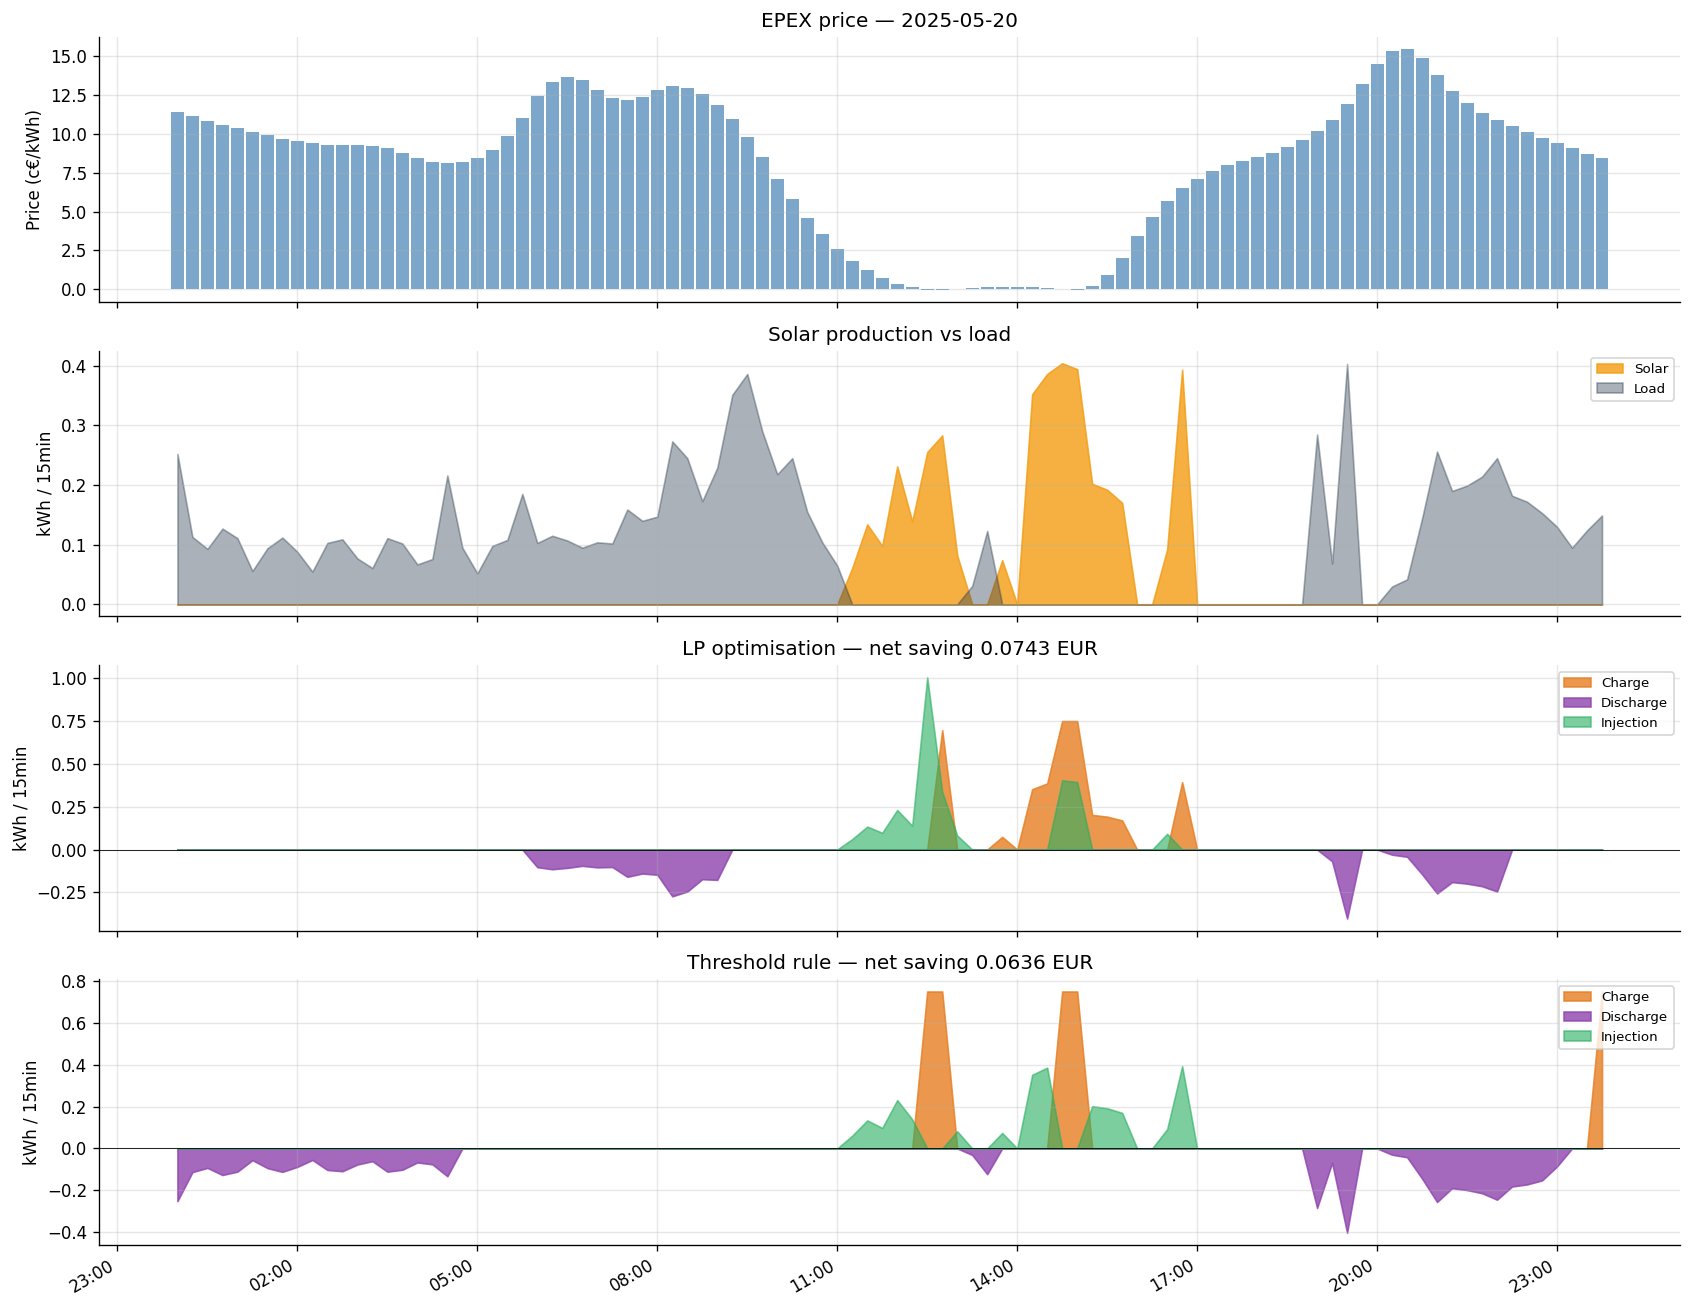

In [4]:
# Single-day demo — sunny spring day with real data
DEMO_DATE = "2025-05-20"

day = df.loc[DEMO_DATE]
p_day   = day["price_eur_kwh"].values
l_day   = day["verbruik_kwh"].values
sol_day = day["sl_productie_kwh"].values
slots   = range(len(p_day))  # 96 slots (15-min)

res_lp   = optimize_day(p_day, l_day, S_MAX, P_MAX, ETA_C, ETA_D, S_INIT,
                        cyclic=True, binary=True, deg_cost=DEG, S_min=S_MIN,
                        solar=sol_day, price_inj=PRICE_INJ)
res_rule = threshold_strategy(p_day, l_day, S_MAX, P_MAX, ETA_C, ETA_D, S_INIT,
                              cyclic=True, deg_cost=DEG, S_min=S_MIN,
                              solar=sol_day, price_inj=PRICE_INJ)

# Baseline: solar but no battery
gin_base  = np.maximum(l_day - sol_day, 0)
gout_base = np.maximum(sol_day - l_day, 0)
cost_base = float(np.dot(p_day, gin_base) - PRICE_INJ * gout_base.sum())

print(f"Date: {DEMO_DATE}  ({len(p_day)} slots)")
print(f"Solar total: {sol_day.sum():.2f} kWh  |  Load total: {l_day.sum():.2f} kWh")
print()
print(f"{'':35s}  {'EUR':>7}")
print(f"{'-'*44}")
print(f"{'Baseline (solar, no battery)':35s}  {cost_base:7.4f}")
print(f"{'LP — grid bill':35s}  {res_lp['cost_electricity']:7.4f}  (saving {cost_base - res_lp['cost_electricity']:+.4f})")
print(f"{'LP — battery wear':35s}  {res_lp['cost_degradation']:7.4f}")
print(f"{'LP — net saving':35s}  {cost_base - res_lp['cost']:7.4f}")
print(f"{'Threshold — net saving':35s}  {cost_base - res_rule['cost']:7.4f}")

# Plot
times = day.index
fig, axes = plt.subplots(4, 1, figsize=(14, 11), sharex=True)

ax = axes[0]
ax.bar(times, p_day * 100, color="steelblue", alpha=0.7, width=0.009)
ax.set_ylabel("Price (c€/kWh)")
ax.set_title(f"EPEX price — {DEMO_DATE}")

ax = axes[1]
ax.fill_between(times, sol_day, alpha=0.8, color="#f39c12", label="Solar")
ax.fill_between(times, l_day,   alpha=0.4, color="#2c3e50", label="Load")
ax.set_ylabel("kWh / 15min")
ax.set_title("Solar production vs load")
ax.legend(fontsize=8)

for ax, res, title in [(axes[2], res_lp, "LP optimisation"), (axes[3], res_rule, "Threshold rule")]:
    ax.fill_between(times, res["c"],              alpha=0.8, color="#e67e22", label="Charge")
    ax.fill_between(times, [-v for v in res["d"]], alpha=0.8, color="#8e44ad", label="Discharge")
    ax.fill_between(times, res["g_out"],           alpha=0.6, color="#27ae60", label="Injection")
    ax.axhline(0, color="black", lw=0.5)
    saving = cost_base - res["cost"]
    ax.set_ylabel("kWh / 15min")
    ax.set_title(f"{title} — net saving {saving:.4f} EUR")
    ax.legend(fontsize=8, loc="upper right")

axes[-1].xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))
axes[-1].xaxis.set_major_locator(mdates.HourLocator(interval=3))
fig.autofmt_xdate(rotation=30, ha="right")
plt.tight_layout()
plt.show()

## 3. Backtesting — full dataset 2024–2026

In [5]:
import time
from pathlib import Path
RECOMPUTE = False   # True -> rerun backtests (~10-15 min)
out_dir = Path('../results')
out_dir.mkdir(exist_ok=True)
bt_kwargs = dict(
    S_max=S_MAX, P_max=P_MAX, eta_c=ETA_C, eta_d=ETA_D,
    S_init=S_INIT, deg_cost=DEG, S_min=S_MIN,
    solar_df=solar_df, price_inj=PRICE_INJ,
)
if RECOMPUTE:
    t0 = time.time()
    bt_rule = backtest(prices_df, load_df, strategy='threshold', **bt_kwargs)
    print(f'Threshold (EPEX)      done: {len(bt_rule)} days  ({time.time()-t0:.1f}s)')
    t0 = time.time()
    bt_rule_dn = backtest(prices_dn_df, load_df, strategy='threshold', **bt_kwargs)
    print(f'Threshold (dag/nacht) done: {len(bt_rule_dn)} days  ({time.time()-t0:.1f}s)')
    t0 = time.time()
    bt_lp = backtest(prices_df, load_df, strategy='lp', binary=True, **bt_kwargs)
    print(f'LP (EPEX)             done: {len(bt_lp)} days  ({time.time()-t0:.1f}s)')
    t0 = time.time()
    bt_dn = backtest(prices_dn_df, load_df, strategy='lp', binary=True, **bt_kwargs)
    print(f'LP (dag/nacht)        done: {len(bt_dn)} days  ({time.time()-t0:.1f}s)')
    t0 = time.time()
    bt_lp_allin = backtest(prices_allin_df, load_df, strategy='lp', binary=True, **bt_kwargs)
    print(f'LP (EPEX+markup)      done: {len(bt_lp_allin)} days  ({time.time()-t0:.1f}s)')
    t0 = time.time()
    bt_rule_allin = backtest(prices_allin_df, load_df, strategy='threshold', **bt_kwargs)
    print(f'Rule (EPEX+markup)    done: {len(bt_rule_allin)} days  ({time.time()-t0:.1f}s)')
    bt_rule.to_csv(out_dir / 'backtest_rule_epex.csv')
    bt_rule_dn.to_csv(out_dir / 'backtest_rule_dagNacht.csv')
    bt_lp.to_csv(out_dir / 'backtest_lp_epex.csv')
    bt_dn.to_csv(out_dir / 'backtest_lp_dagNacht.csv')
    bt_lp_allin.to_csv(out_dir / 'backtest_lp_allin.csv')
    bt_rule_allin.to_csv(out_dir / 'backtest_rule_allin.csv')
    print(f'Saved to {out_dir.resolve()}')
else:
    bt_rule       = pd.read_csv(out_dir / 'backtest_rule_epex.csv',     index_col=0, parse_dates=True)
    bt_rule_dn    = pd.read_csv(out_dir / 'backtest_rule_dagNacht.csv',  index_col=0, parse_dates=True)
    bt_lp         = pd.read_csv(out_dir / 'backtest_lp_epex.csv',       index_col=0, parse_dates=True)
    bt_dn         = pd.read_csv(out_dir / 'backtest_lp_dagNacht.csv',    index_col=0, parse_dates=True)
    bt_lp_allin   = pd.read_csv(out_dir / 'backtest_lp_allin.csv',      index_col=0, parse_dates=True)
    _p = out_dir / 'backtest_rule_allin.csv'
    if _p.exists():
        bt_rule_allin = pd.read_csv(_p, index_col=0, parse_dates=True)
    else:
        bt_rule_allin = backtest(prices_allin_df, load_df, strategy='threshold', **bt_kwargs)
        bt_rule_allin.to_csv(_p)
        print('Rule EPEX+markup computed and cached.')
    print(f'Loaded {len(bt_lp)} days from CSV')
# ── Summary — monthly-normalised annual figures ──────────────────────────────
period_days = len(bt_dn)
date_from   = bt_dn.index[0].date()  if hasattr(bt_dn.index[0],  'date') else bt_dn.index[0]
date_to     = bt_dn.index[-1].date() if hasattr(bt_dn.index[-1], 'date') else bt_dn.index[-1]

# Annual estimates via calendar-month normalisation (all data used)
ann_bt = {
    'base_dn':   monthly_annual(bt_dn['cost_baseline']),
    'cost_dn':   monthly_annual(bt_dn['cost']),
    'save_dn':   monthly_annual(bt_dn['saving_net']),
    'base_ep':   monthly_annual(bt_lp_allin['cost_baseline']),
    'cost_ep':   monthly_annual(bt_lp_allin['cost']),
    'save_ep':   monthly_annual(bt_lp_allin['saving_net']),
    'cost_rule': monthly_annual(bt_rule_allin['cost']),
    'save_rule': monthly_annual(bt_rule_allin['saving_net']),
    'base_raw':  monthly_annual(bt_lp['cost_baseline']),
    'cost_raw':  monthly_annual(bt_lp['cost']),
    'save_raw':  monthly_annual(bt_lp['saving_net']),
    'cost_rraw': monthly_annual(bt_rule['cost']),
    'save_rraw': monthly_annual(bt_rule['saving_net']),
}

def _row(name, cost_yr, saving_yr, is_baseline=False):
    s_str = '—  (baseline)' if is_baseline else f'{saving_yr:+.0f} EUR/year'
    print(f'  {name:<52} {cost_yr:>8.0f}   {s_str}')

hdr = f"  {'Scenario':<52} {'Cost/yr':>8}   {'Battery saves'}"
sep = '  ' + '-' * 80

print()
print(f'Period: {date_from} -> {date_to}  ({period_days} days — monthly normalised)')
print()

print('-- Dag/nacht tariff (actual contract) ' + '-'*42)
print(hdr); print(sep)
_row('Solar only, no battery  <- TODAY',
     ann_bt['base_dn'], 0, is_baseline=True)
_row('LP dag/nacht  * PRIMARY',
     ann_bt['cost_dn'], ann_bt['save_dn'])
print()

print('-- EPEX + markup tariff (if switching contract) ' + '-'*32)
print(hdr); print(sep)
_row('Solar only, no battery  <- if on EPEX+markup',
     ann_bt['base_ep'], 0, is_baseline=True)
_row('LP EPEX+markup           (new optimised controller)',
     ann_bt['cost_ep'], ann_bt['save_ep'])
_row('Rule EPEX+markup         (proxy: current SOFAR on dynamic tariff)',
     ann_bt['cost_rule'], ann_bt['save_rule'])
print()

print('-- EPEX raw prices (reference only) ' + '-'*44)
print(hdr); print(sep)
_row('Solar only, no battery',
     ann_bt['base_raw'], 0, is_baseline=True)
_row('LP EPEX raw',
     ann_bt['cost_raw'], ann_bt['save_raw'])
_row('Rule EPEX raw',
     ann_bt['cost_rraw'], ann_bt['save_rraw'])

Loaded 522 days from CSV

Period: 2024-11-01 -> 2026-04-06  (522 days — monthly normalised)

-- Dag/nacht tariff (actual contract) ------------------------------------------
  Scenario                                              Cost/yr   Battery saves
  --------------------------------------------------------------------------------
  Solar only, no battery  <- TODAY                         1501   —  (baseline)
  LP dag/nacht  * PRIMARY                                  1409   +92 EUR/year

-- EPEX + markup tariff (if switching contract) --------------------------------
  Scenario                                              Cost/yr   Battery saves
  --------------------------------------------------------------------------------
  Solar only, no battery  <- if on EPEX+markup             1574   —  (baseline)
  LP EPEX+markup           (new optimised controller)      1454   +120 EUR/year
  Rule EPEX+markup         (proxy: current SOFAR on dynamic tariff)     1567   +8 EUR/year

-- EPEX


Annual saving — simple scaling vs monthly normalisation:
                                        simple (×scale)   monthly norm
  -------------------------------------------------------------------
  LP dag/nacht total cost                          1502           1409  (-93 EUR/yr)
  LP EPEX+markup total cost                        1571           1454  (-116 EUR/yr)
  Real SOFAR elec + wear                           1594           1497  (-97 EUR/yr)
Period: 2024-11-01 00:00:00 -> 2026-04-06 00:00:00  (522 days — monthly normalised)
Degradation cost rate: DEG = 0.1 EUR/kWh charged

== 1. DAG/NACHT tariff (actual contract) =====================================
  Scenario                                           EUR/period   EUR/year  vs S0 (solar)
  --------------------------------------------------------------------------------------
  Solar only, no battery (S0)                           2259.95       1501            +0
  Real SOFAR — electricity only (S1)                    2078.35 

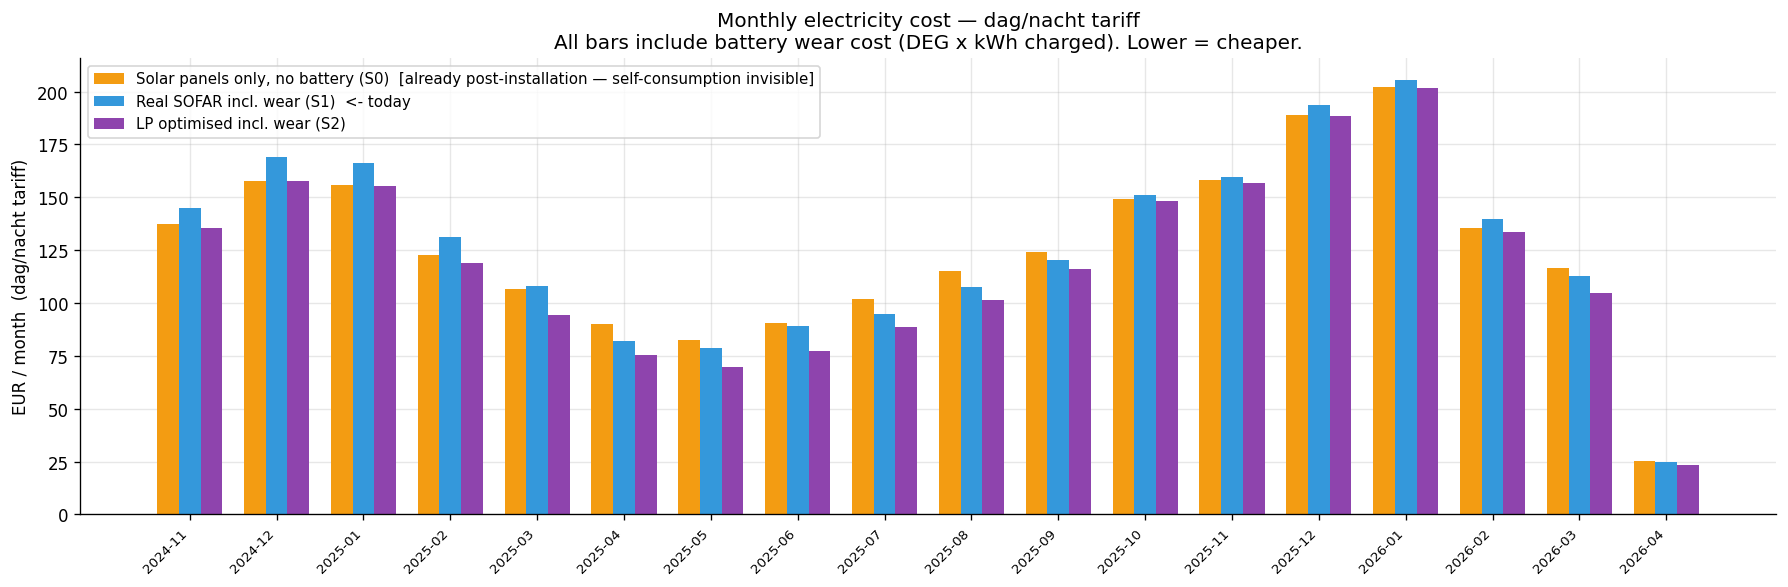

In [6]:
# Full savings decomposition: dag/nacht vs EPEX+markup
# Real SOFAR wear = real bat_laden * DEG (same cost rate as LP — assumption).
# This makes the comparison fair: both LP and SOFAR include battery wear cost.

# EV lump-sum: session energy recorded as one value at session start, not per slot.
# clip(lower=0) causes ~201 kWh/yr underestimation (~2.5% of grid import);
# error is systematic across all scenarios — see 01_eda_real_load.ipynb.
afname_no_ev   = (df['afname_kwh'] - df['ev_energie_kwh'].fillna(0)).clip(lower=0)
sofar_wear_day = df['bat_laden_kwh_kw'].clip(lower=0, upper=0.75).resample('D').sum() * DEG
sofar_wear_day.index = sofar_wear_day.index.date

sofar_dn = (afname_no_ev * df['price_dag_nacht']).resample('D').sum() \
         - (df['injectie_kwh'] * PRICE_INJ).resample('D').sum()
sofar_dn.index = sofar_dn.index.date

sofar_ep = (afname_no_ev * df['price_allin']).resample('D').sum() \
         - (df['injectie_kwh'] * PRICE_INJ).resample('D').sum()
sofar_ep.index = sofar_ep.index.date

# Align on common dates
common = bt_dn.index.intersection(bt_lp_allin.index).intersection(sofar_dn.index)
days  = len(common)
scale = 365 / days
date_from, date_to = common[0], common[-1]

# Aggregate totals
s0_dn  = bt_dn['cost_baseline'].reindex(common).sum()
sf_dn  = sofar_dn.reindex(common).sum()
sw_dn  = sofar_wear_day.reindex(common).sum()   # SOFAR wear cost
lp_dn  = bt_dn['cost'].reindex(common).sum()    # already includes wear (LP objective)
dg_dn  = bt_dn['cost_degradation'].reindex(common).sum()
lp_el_dn = bt_dn['cost_electricity'].reindex(common).sum()

s0_ep  = bt_lp_allin['cost_baseline'].reindex(common).sum()
sf_ep  = sofar_ep.reindex(common).sum()
sw_ep  = sofar_wear_day.reindex(common).sum()   # same wear (same physical battery)
lp_ep  = bt_lp_allin['cost'].reindex(common).sum()
dg_ep  = bt_lp_allin['cost_degradation'].reindex(common).sum()
lp_el_ep = bt_lp_allin['cost_electricity'].reindex(common).sum()

# ── Monthly-normalised annual estimates ───────────────────────────────────────
# Replaces simple (total × 365/N_days) scaling.
# Months with 2 observations (Nov–Apr appear in both 2024/25 and 2025/26)
# are averaged; May–Oct use 2025 only. All backtest data is used.
ann_s0_dn = monthly_annual(bt_dn['cost_baseline'].reindex(common))
ann_sf_dn = monthly_annual(sofar_dn.reindex(common))
ann_sw_dn = monthly_annual(sofar_wear_day.reindex(common))
ann_lp_dn = monthly_annual(bt_dn['cost'].reindex(common))
ann_s0_ep = monthly_annual(bt_lp_allin['cost_baseline'].reindex(common))
ann_sf_ep = monthly_annual(sofar_ep.reindex(common))
ann_sw_ep = ann_sw_dn          # same physical battery in all scenarios
ann_lp_ep    = monthly_annual(bt_lp_allin['cost'].reindex(common))
ann_lp_el_dn = monthly_annual(bt_dn['cost_electricity'].reindex(common))
ann_lp_el_ep = monthly_annual(bt_lp_allin['cost_electricity'].reindex(common))

print(f'\nAnnual saving — simple scaling vs monthly normalisation:')
print(f'  {"":35s}  {"simple (×scale)":>16}  {"monthly norm":>13}')
print(f'  {"-"*67}')
for lbl, simple, norm in [
    ('LP dag/nacht total cost',    lp_dn  * scale, ann_lp_dn),
    ('LP EPEX+markup total cost',  lp_ep  * scale, ann_lp_ep),
    ('Real SOFAR elec + wear',    (sf_dn + sw_dn)*scale, ann_sf_dn + ann_sw_dn),
]:
    diff = norm - simple
    print(f'  {lbl:35s}  {simple:>16.0f}  {norm:>13.0f}  ({diff:+.0f} EUR/yr)')

W = 50
COL = '  {:<{}} {:>10}  {:>9}  {:>12}'
SEP = '  ' + '-' * (W + 36)

def hdr():
    print(COL.format('Scenario', W, 'EUR/period', 'EUR/year', 'vs S0 (solar)'))
    print(SEP)

def row(label, cost, ann_cost, ann_ref, note=''):
    diff   = ann_cost - ann_ref
    note_s = '  <- ' + note if note else ''
    print(COL.format(label, W, f'{cost:.2f}', f'{ann_cost:.0f}', f'{diff:+.0f}') + note_s)

def srow(label, ann_saving, extra=''):
    e = '  ' + extra if extra else ''
    print(f'    {label:<{W+2}} {ann_saving:>+8.0f} EUR/year{e}')

print(f'Period: {date_from} -> {date_to}  ({days} days — monthly normalised)')
print(f'Degradation cost rate: DEG = {DEG} EUR/kWh charged')
print()

# ── SECTION 1: dag/nacht ─────────────────────────────────────────────────────
print('== 1. DAG/NACHT tariff (actual contract) ' + '='*37)
hdr()
row('Solar only, no battery (S0)',              s0_dn,       ann_s0_dn,           ann_s0_dn)
row('Real SOFAR — electricity only (S1)',       sf_dn,       ann_sf_dn,           ann_s0_dn, 'current system')
row('Real SOFAR — incl. wear (S1+wear)',        sf_dn+sw_dn, ann_sf_dn+ann_sw_dn, ann_s0_dn, 'fair comparison')
row('LP optimised — electricity only (S2)',     lp_el_dn,    ann_lp_el_dn,        ann_s0_dn)
row('LP optimised — incl. wear (S2+wear)',      lp_dn,       ann_lp_dn,           ann_s0_dn, 'fair comparison')
print()
print('  Battery savings vs S0 (solar only, no battery):')
srow('Real SOFAR on top of solar (S1+wear)',    ann_s0_dn - (ann_sf_dn + ann_sw_dn))
srow('LP on top of solar (S2+wear)',            ann_s0_dn - ann_lp_dn)
srow('LP vs real SOFAR — extra LP gain',        (ann_sf_dn + ann_sw_dn) - ann_lp_dn,
     '(positive = LP is cheaper)')
print()

# ── SECTION 2: EPEX+markup ───────────────────────────────────────────────────
print(f'== 2. EPEX+MARKUP tariff (if switching, markup={MARKUP} EUR/kWh) ' + '='*20)
print('   Assumption: SOFAR schedule unchanged (same wear), only energy prices differ.')
hdr()
row('Solar only, no battery (S3b)',             s0_ep,       ann_s0_ep,           ann_s0_ep)
row('Real SOFAR — electricity only (S4)',       sf_ep,       ann_sf_ep,           ann_s0_ep)
row('Real SOFAR — incl. wear (S4+wear)',        sf_ep+sw_ep, ann_sf_ep+ann_sw_ep, ann_s0_ep, 'fair comparison')
row('LP optimised — electricity only (S3)',     lp_el_ep,    ann_lp_el_ep,        ann_s0_ep)
row('LP optimised — incl. wear (S3+wear)',      lp_ep,       ann_lp_ep,           ann_s0_ep, 'fair comparison')
print()
print('  Battery savings vs S0 (solar only, no battery):')
srow('Real SOFAR on top of solar (S4+wear)',    ann_s0_ep - (ann_sf_ep + ann_sw_ep))
srow('LP on top of solar (S3+wear)',            ann_s0_ep - ann_lp_ep)
srow('LP vs real SOFAR — extra LP gain',        (ann_sf_ep + ann_sw_ep) - ann_lp_ep,
     '(positive = LP is cheaper)')
print()

# ── SECTION 3: switch tariff comparison ──────────────────────────────────────
print('== 3. SWITCH TARIFF? dag/nacht vs EPEX+markup ' + '='*30)
print('   Negative diff = EPEX+markup cheaper; positive = dag/nacht cheaper.')
print('   All rows include battery wear for fair comparison.')
print()
FMT = '  {:<44} {:>11}  {:>13}  {:>13}'
print(FMT.format('Scenario', 'dag/nacht', 'EPEX+markup', 'diff (EP-DN)'))
print('  ' + '-' * 86)
for lbl, dn_ann, ep_ann in [
    ('Solar only (S0 / S3b) — reference',  ann_s0_dn,       ann_s0_ep),
    ('Real SOFAR incl. wear (S1 / S4)', ann_sf_dn+ann_sw_dn, ann_sf_ep+ann_sw_ep),
    ('LP incl. wear (S2 / S3)',         ann_lp_dn,           ann_lp_ep),
]:
    diff = ep_ann - dn_ann
    print(FMT.format(lbl, f'{dn_ann:.0f} EUR/yr', f'{ep_ann:.0f} EUR/yr', f'{diff:+.0f} EUR/yr'))

# ── Monthly bar chart: dag/nacht ─────────────────────────────────────────────
s = bt_dn.reindex(common).copy()
s['cost_sofar']    = sofar_dn.reindex(common).values
s['cost_sofar_w']  = (sofar_dn + sofar_wear_day).reindex(common).values
s['lp_total']      = s['cost']
s['month_dt']      = [str(d)[:7] for d in s.index]
mo = s.groupby('month_dt').agg(
    solar      = ('cost_baseline','sum'),
    sofar_w    = ('cost_sofar_w', 'sum'),
    lp_total   = ('lp_total',     'sum'),
)

fig, ax = plt.subplots(figsize=(15, 5))
x = range(len(mo))
w = 0.25
ax.bar([i - w for i in x], mo['solar'],    width=w, color='#f39c12', label='Solar panels only, no battery (S0)  [already post-installation — self-consumption invisible]')
ax.bar([i         for i in x], mo['sofar_w'],  width=w, color='#3498db', label='Real SOFAR incl. wear (S1)  <- today')
ax.bar([i + w     for i in x], mo['lp_total'], width=w, color='#8e44ad', label='LP optimised incl. wear (S2)')
ax.set_xticks(list(x))
ax.set_xticklabels(list(mo.index), rotation=45, ha='right', fontsize=8)
ax.set_ylabel('EUR / month  (dag/nacht tariff)')
ax.set_title(
    'Monthly electricity cost — dag/nacht tariff\n'
    'All bars include battery wear cost (DEG x kWh charged). Lower = cheaper.'
)
ax.legend(fontsize=9)
ax.yaxis.grid(True, alpha=0.3)
ax.set_axisbelow(True)
plt.tight_layout()
plt.show()

## 4. Compare scenarios

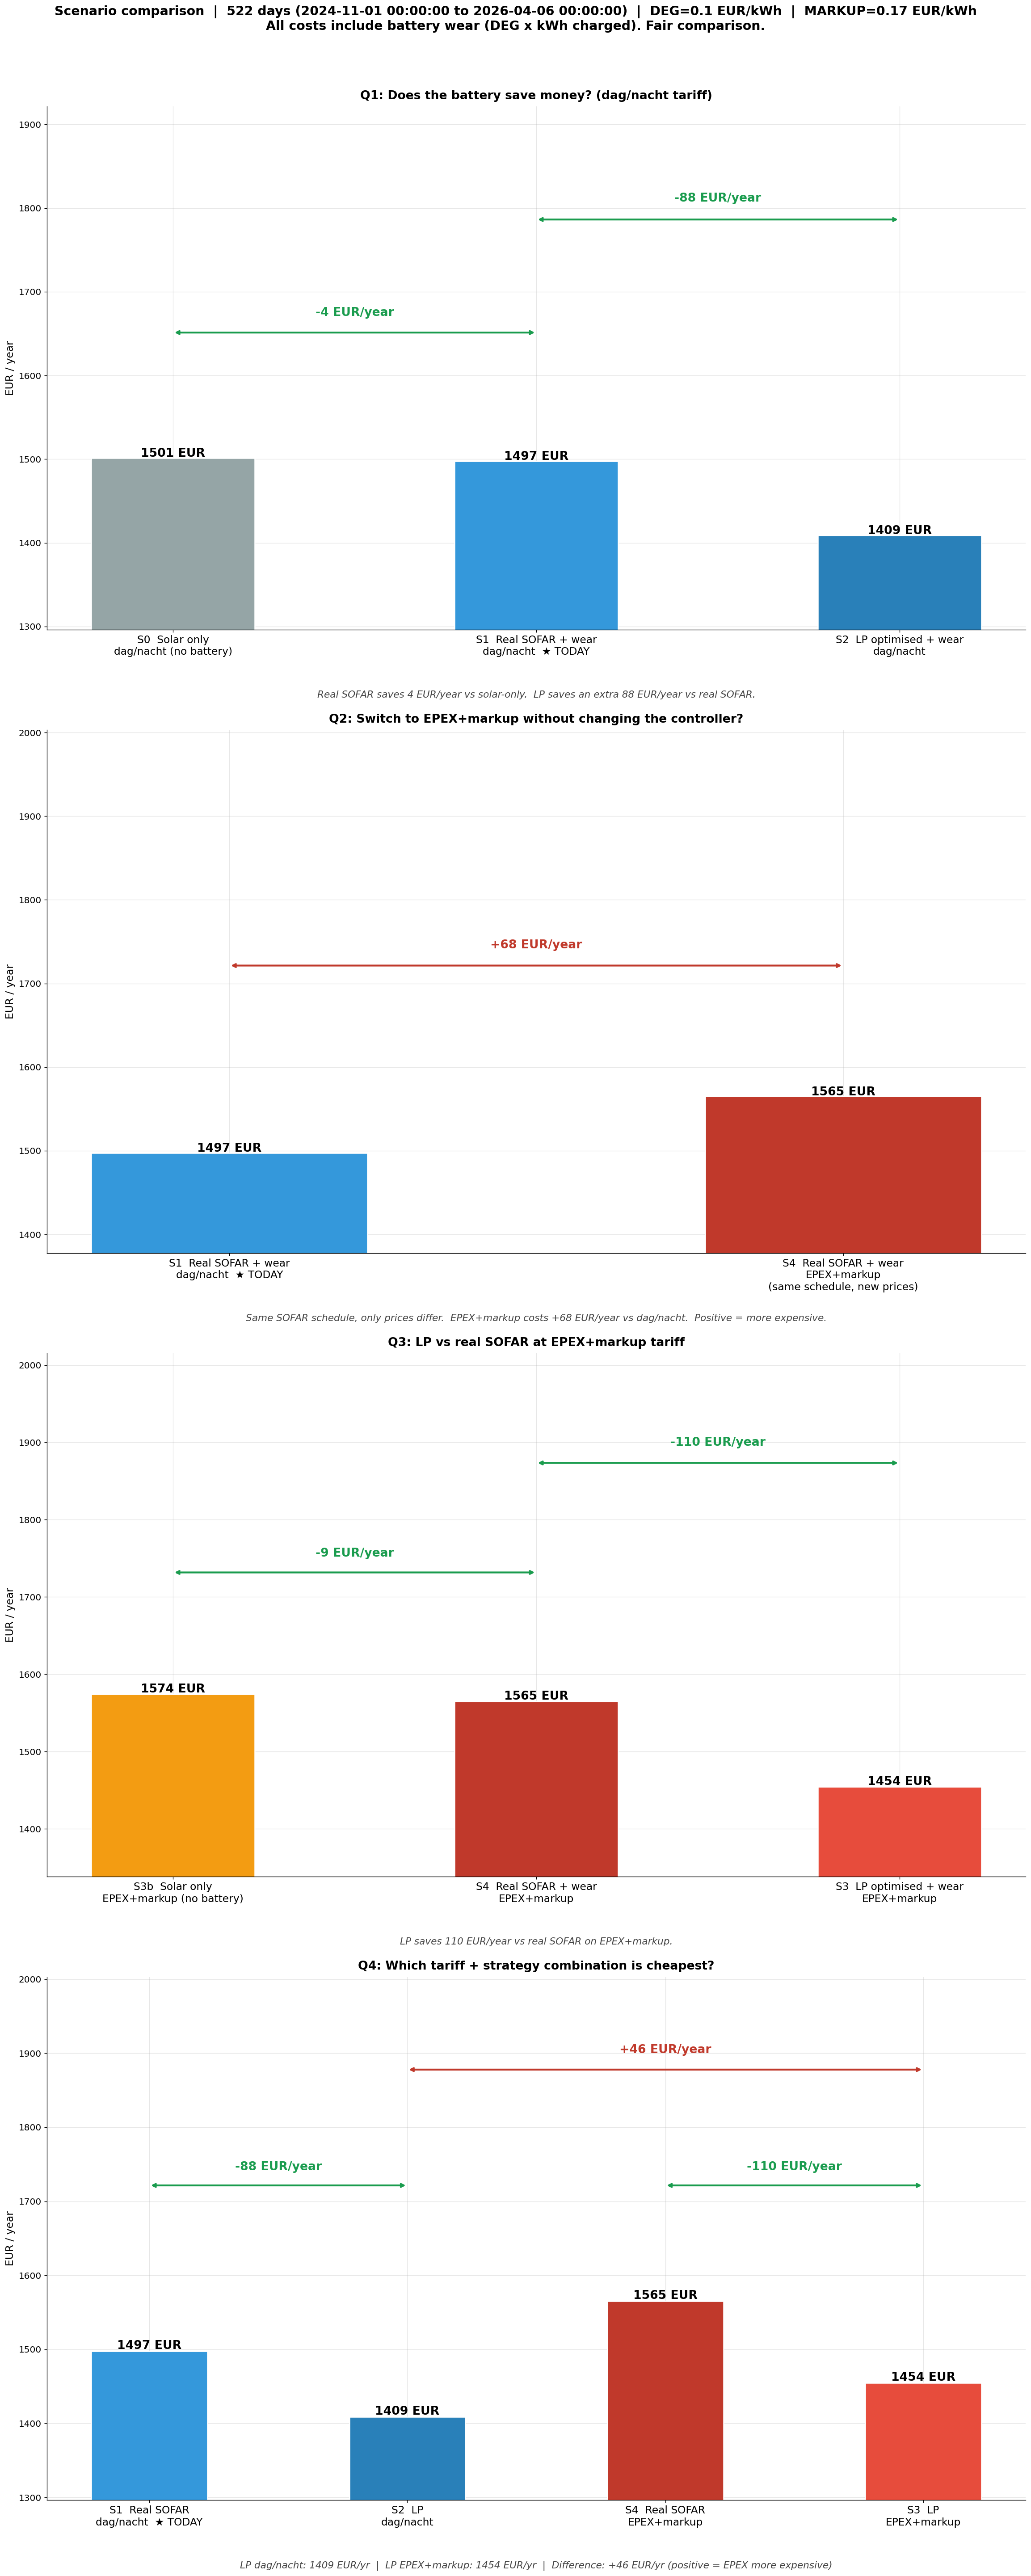

In [7]:
# ── Define annualised scenario costs from variables computed in §3 ───────────
# All values already available from the savings decomposition cell.
# yr[...] = EUR/year (annualised over the backtest period).
yr = {
    'S0':  ann_s0_dn,   # solar only, dag/nacht
    'S1':  ann_sf_dn,   # real SOFAR electricity, dag/nacht
    'S2':  ann_lp_dn,   # LP dag/nacht (includes wear)
    'S3b': ann_s0_ep,   # solar only, EPEX+markup
    'S3':  ann_lp_ep,   # LP EPEX+markup (includes wear)
    'S4':  ann_sf_ep,   # real SOFAR electricity, EPEX+markup
}
yr_sw  = ann_sw_dn
yr_s1w = yr['S1'] + yr_sw
yr_s4w = yr['S4'] + yr_sw

# ── Chart helpers ─────────────────────────────────────────────────────────────
C = {'S0':'#95a5a6', 'S1w':'#3498db', 'S2':'#2980b9',
     'S3b':'#f39c12', 'S3':'#e74c3c', 'S4w':'#c0392b'}

def add_arrow(ax, x1, x2, yref, diff, fs=16):
    sign  = '+' if diff > 0 else ''
    color = '#c0392b' if diff > 0 else '#1a9c4e'
    ax.annotate('', xy=(x2, yref), xytext=(x1, yref),
                arrowprops=dict(arrowstyle='<->', color=color, lw=2.5))
    ax.text((x1+x2)/2, yref*1.012, f'{sign}{diff:.0f} EUR/year',
            ha='center', fontsize=fs, fontweight='bold', color=color)

def bar_panel(ax, labels, values, colors, title, note):
    rng = max(values) - min(values) if max(values) != min(values) else max(values)*0.05
    ax.bar(range(len(values)), values, color=colors, width=0.45,
           edgecolor='white', linewidth=1.5)
    for i, v in enumerate(values):
        ax.text(i, v + rng*0.02, f'{v:.0f} EUR', ha='center', fontsize=16, fontweight='bold')
    ax.set_xticks(range(len(labels)))
    ax.set_xticklabels(labels, fontsize=14)
    ax.set_ylabel('EUR / year', fontsize=14)
    ax.set_ylim(min(values)*0.92, max(values)*1.28)
    ax.yaxis.grid(True, alpha=0.3); ax.set_axisbelow(True)
    ax.tick_params(axis='y', labelsize=12)
    ax.set_title(title, fontsize=16, fontweight='bold', pad=10)
    ax.text(0.5, -0.13, note, transform=ax.transAxes,
            ha='center', fontsize=13, color='#444', style='italic')

fig, axes = plt.subplots(4, 1, figsize=(20, 48))
fig.suptitle(
    f'Scenario comparison  |  {days} days ({common[0]} to {common[-1]})  |'
    f'  DEG={DEG} EUR/kWh  |  MARKUP={MARKUP} EUR/kWh\n'
    'All costs include battery wear (DEG x kWh charged). Fair comparison.',
    fontsize=17, fontweight='bold', y=1.002)

# ── Panel 1: Battery value at dag/nacht ──────────────────────────────────────
ax = axes[0]
vals = [yr['S0'], yr_s1w, yr['S2']]
lbls = ['S0  Solar only\ndag/nacht (no battery)',
        'S1  Real SOFAR + wear\ndag/nacht  ★ TODAY',
        'S2  LP optimised + wear\ndag/nacht']
bar_panel(ax, lbls, vals, [C['S0'], C['S1w'], C['S2']],
    'Q1: Does the battery save money? (dag/nacht tariff)',
    f'Real SOFAR saves {yr["S0"]-yr_s1w:.0f} EUR/year vs solar-only.  '
    f'LP saves an extra {yr_s1w-yr["S2"]:.0f} EUR/year vs real SOFAR.')
add_arrow(ax, 0, 1, max(vals)*1.10, yr_s1w - yr['S0'])
add_arrow(ax, 1, 2, max(vals)*1.19, yr['S2'] - yr_s1w)

# ── Panel 2: Switch tariff, same controller ───────────────────────────────────
ax = axes[1]
vals = [yr_s1w, yr_s4w]
lbls = ['S1  Real SOFAR + wear\ndag/nacht  ★ TODAY',
        'S4  Real SOFAR + wear\nEPEX+markup\n(same schedule, new prices)']
bar_panel(ax, lbls, vals, [C['S1w'], C['S4w']],
    'Q2: Switch to EPEX+markup without changing the controller?',
    f'Same SOFAR schedule, only prices differ.  '
    f'EPEX+markup costs {yr_s4w-yr_s1w:+.0f} EUR/year vs dag/nacht.'
    f'  Positive = more expensive.')
add_arrow(ax, 0, 1, max(vals)*1.10, yr_s4w - yr_s1w)

# ── Panel 3: LP gain on EPEX+markup vs real SOFAR ────────────────────────────
ax = axes[2]
vals = [yr['S3b'], yr_s4w, yr['S3']]
lbls = ['S3b  Solar only\nEPEX+markup (no battery)',
        'S4  Real SOFAR + wear\nEPEX+markup',
        'S3  LP optimised + wear\nEPEX+markup']
bar_panel(ax, lbls, vals, [C['S3b'], C['S4w'], C['S3']],
    'Q3: LP vs real SOFAR at EPEX+markup tariff',
    f'LP saves {yr_s4w-yr["S3"]:.0f} EUR/year vs real SOFAR on EPEX+markup.')
add_arrow(ax, 0, 1, max(vals)*1.10, yr_s4w - yr['S3b'])
add_arrow(ax, 1, 2, max(vals)*1.19, yr['S3'] - yr_s4w)

# ── Panel 4: Best of each tariff ─────────────────────────────────────────────
ax = axes[3]
vals = [yr_s1w, yr['S2'], yr_s4w, yr['S3']]
lbls = ['S1  Real SOFAR\ndag/nacht  ★ TODAY',
        'S2  LP\ndag/nacht',
        'S4  Real SOFAR\nEPEX+markup',
        'S3  LP\nEPEX+markup']
bar_panel(ax, lbls, vals, [C['S1w'], C['S2'], C['S4w'], C['S3']],
    'Q4: Which tariff + strategy combination is cheapest?',
    f'LP dag/nacht: {yr["S2"]:.0f} EUR/yr  |  '
    f'LP EPEX+markup: {yr["S3"]:.0f} EUR/yr  |  '
    f'Difference: {yr["S3"]-yr["S2"]:+.0f} EUR/yr (positive = EPEX more expensive)')
add_arrow(ax, 0, 1, max(vals)*1.10, yr['S2'] - yr_s1w)
add_arrow(ax, 2, 3, max(vals)*1.10, yr['S3'] - yr_s4w)
add_arrow(ax, 1, 3, max(vals)*1.20, yr['S3'] - yr['S2'])

plt.tight_layout(pad=3.5)
plt.show()

## 5. Backtesting results — cost & monthly breakdown

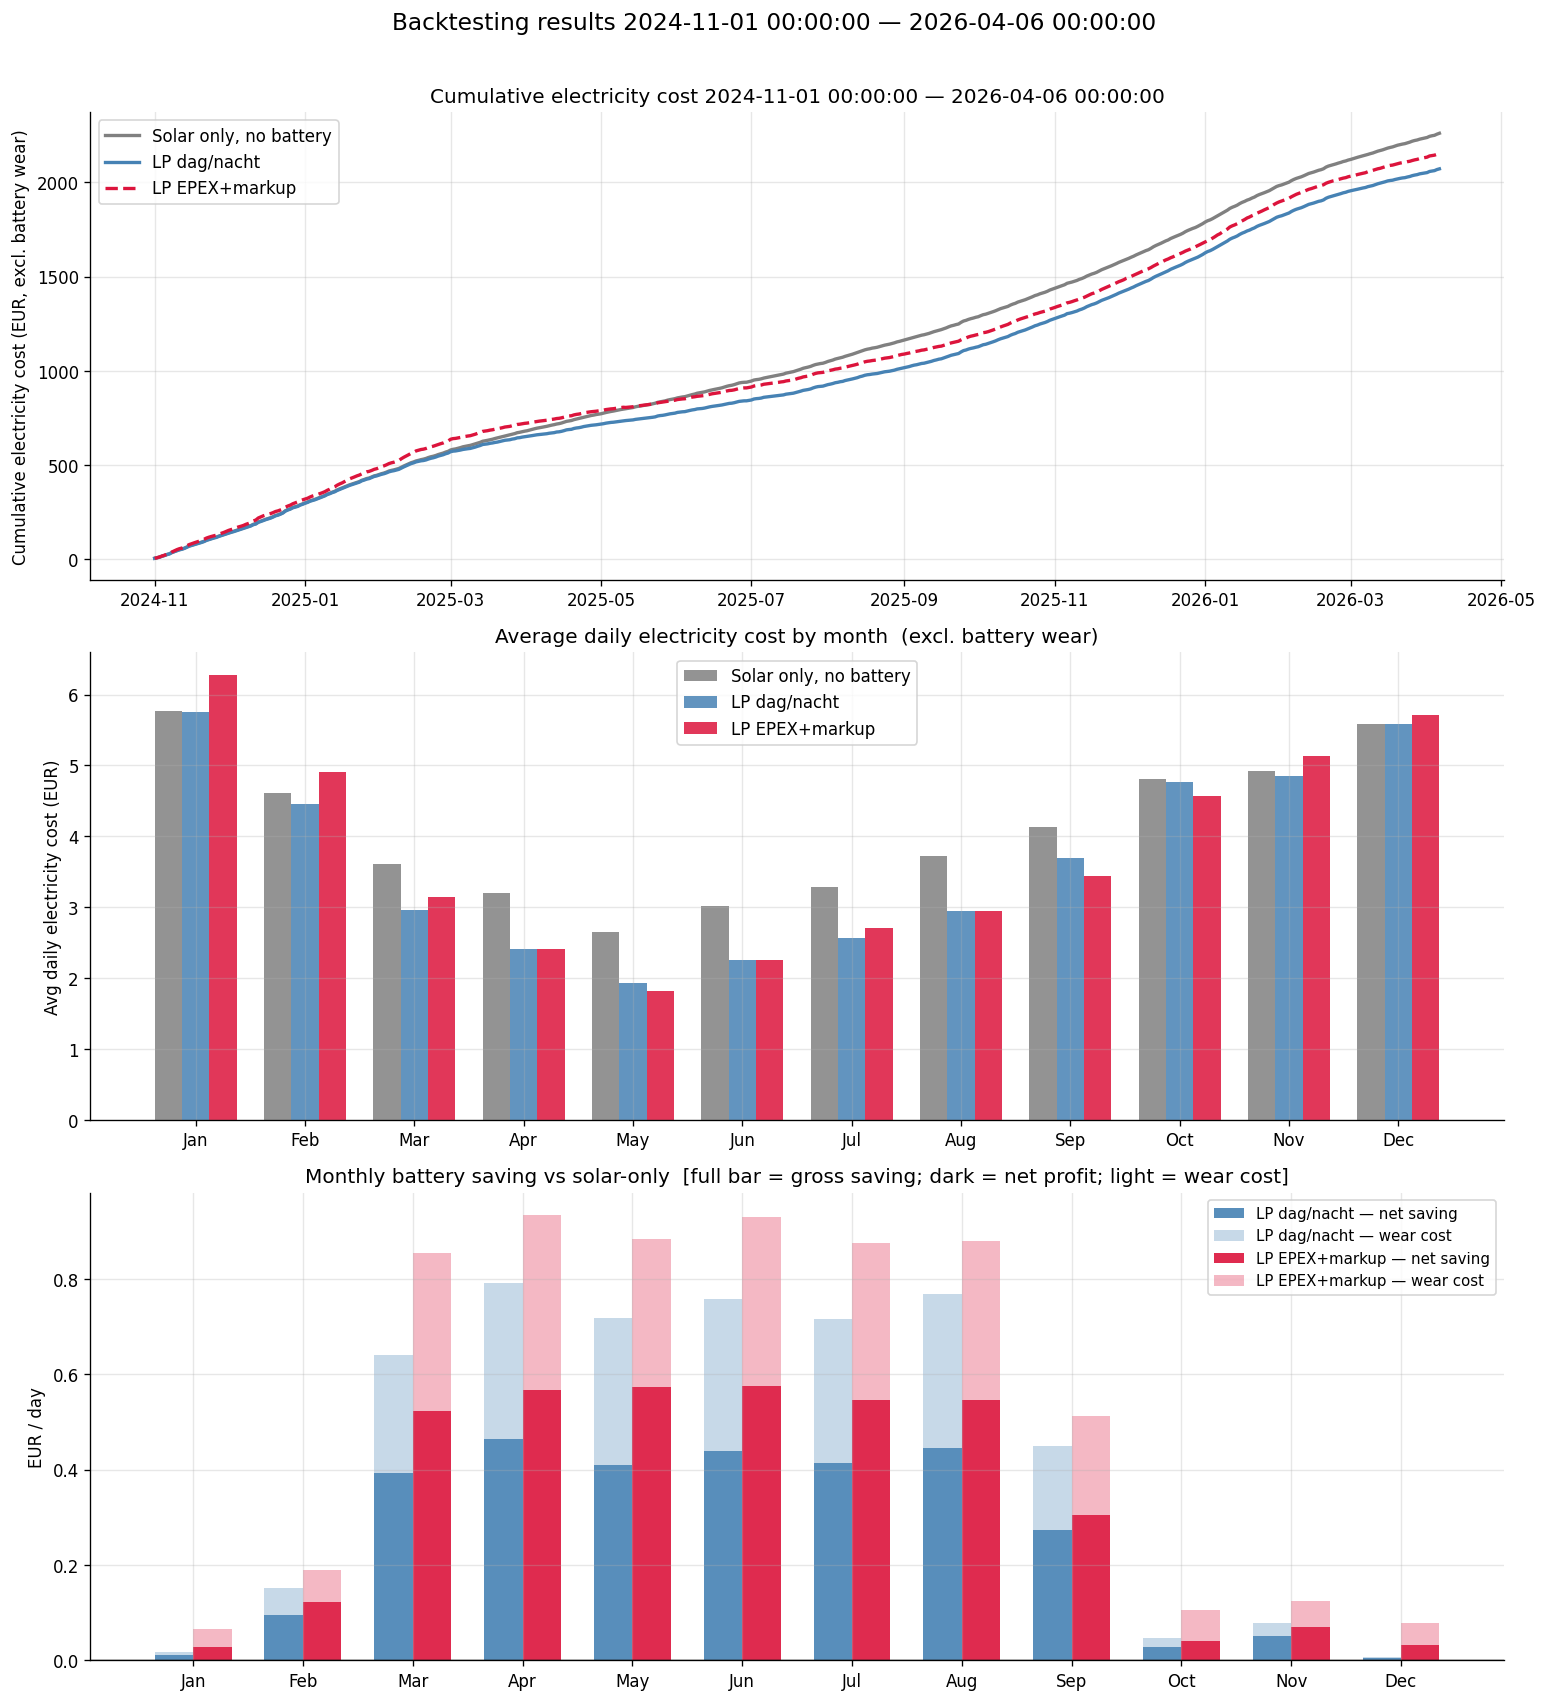

In [8]:
MONTH_NAMES = ['Jan','Feb','Mar','Apr','May','Jun',
               'Jul','Aug','Sep','Oct','Nov','Dec']

# Primary: dag/nacht (actual contract).  Comparison: EPEX+markup (realistic dynamic tariff).
fig, axes = plt.subplots(3, 1, figsize=(13, 14))

# ── Panel 1: Cumulative electricity cost (excl. wear) ─────────────────────────
ax = axes[0]
ax.plot(pd.to_datetime(bt_dn.index),       bt_dn['cost_baseline'].cumsum(),
        color='gray',      lw=2, label='Solar only, no battery')
ax.plot(pd.to_datetime(bt_dn.index),       bt_dn['cost_electricity'].cumsum(),
        color='steelblue', lw=2, label='LP dag/nacht')
ax.plot(pd.to_datetime(bt_lp_allin.index), bt_lp_allin['cost_electricity'].cumsum(),
        color='crimson',   lw=2, ls='--', label='LP EPEX+markup')
ax.set_ylabel('Cumulative electricity cost (EUR, excl. battery wear)')
ax.set_title(f'Cumulative electricity cost {bt_dn.index[0]} — {bt_dn.index[-1]}')
ax.legend()

# ── Panel 2: Average daily electricity cost by month (excl. wear) ─────────────
ax2 = axes[1]
x = np.arange(1, 13)
w = 0.25
for arr, shift, color, label in [
    (bt_dn.groupby('month')['cost_baseline'].mean(),          -w, 'gray',      'Solar only, no battery'),
    (bt_dn.groupby('month')['cost_electricity'].mean(),         0, 'steelblue', 'LP dag/nacht'),
    (bt_lp_allin.groupby('month')['cost_electricity'].mean(),   w, 'crimson',   'LP EPEX+markup'),
]:
    ax2.bar(x + shift, arr.reindex(x, fill_value=0).values, width=w,
            color=color, alpha=0.85, label=label)
ax2.set_xticks(x); ax2.set_xticklabels(MONTH_NAMES)
ax2.set_ylabel('Avg daily electricity cost (EUR)')
ax2.set_title('Average daily electricity cost by month  (excl. battery wear)')
ax2.legend()

# ── Panel 3: Monthly battery saving vs solar-only baseline ───────────────────
ax3 = axes[2]
x = np.arange(1, 13)
w = 0.35
for bt, shift, color, label in [
    (bt_dn,       -w/2, 'steelblue', 'LP dag/nacht'),
    (bt_lp_allin,  w/2, 'crimson',   'LP EPEX+markup'),
]:
    net = bt.groupby('month')['saving_net'].mean().reindex(x, fill_value=0).values
    deg = bt.groupby('month')['cost_degradation'].mean().reindex(x, fill_value=0).values
    ax3.bar(x + shift, net, width=w, color=color, alpha=0.9, label=f'{label} — net saving')
    ax3.bar(x + shift, deg, width=w, color=color, alpha=0.3,
            bottom=net, label=f'{label} — wear cost')
ax3.axhline(0, color='black', lw=0.8)
ax3.set_xticks(x); ax3.set_xticklabels(MONTH_NAMES)
ax3.set_ylabel('EUR / day')
ax3.set_title('Monthly battery saving vs solar-only  '
              '[full bar = gross saving; dark = net profit; light = wear cost]')
ax3.legend(fontsize=9)

plt.suptitle(f'Backtesting results {bt_dn.index[0]} — {bt_dn.index[-1]}', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

## 5b. Multi-day optimizer behavior — 4 consecutive days

Run LP day-by-day (same as the backtest), carry SOC forward between days, and plot
the full 96-hour schedule to see how the optimizer behaves across day boundaries.

In [9]:
# ── Find the best 4-day window using actual LP all-in backtest results ─────────
# Use backtest_lp_allin.csv (EPEX+markup). Raw EPEX can fall below PRICE_INJ=0.04,
# which makes the LP unbounded. All-in prices (min ~0.09) are always above 0.04.

import os
RESULTS_DIR   = os.path.join("..", "results")
bt_allin_file = os.path.join(RESULTS_DIR, "backtest_lp_allin.csv")

bt_lp_all = pd.read_csv(bt_allin_file, parse_dates=["date"], index_col="date").sort_index()

N_WINDOW = 4
dates = bt_lp_all.index.tolist()
rows  = []
for i in range(len(dates) - N_WINDOW + 1):
    window = bt_lp_all.iloc[i : i + N_WINDOW]
    delta  = (dates[i + N_WINDOW - 1] - dates[i]).days
    if delta != N_WINDOW - 1:
        continue
    saving   = window["saving_net"].sum()
    n_active = (window["saving_net"] > 0.05).sum()
    rows.append({"start": dates[i].date(), "total_saving": saving,
                 "days_active": n_active,
                 "min_daily": window["saving_net"].min()})

windows = pd.DataFrame(rows).set_index("start")

print("── Top 10: all 4 days with LP saving > 0.05 EUR ───────────────")
all4 = windows[windows["days_active"] == 4].nlargest(10, "total_saving")
print(all4[["total_saving", "min_daily"]].round(3))

print("\n── Top 10: at least 3 active days ─────────────────────────────")
any3 = windows[windows["days_active"] >= 3].nlargest(10, "total_saving")
print(any3[["total_saving", "days_active", "min_daily"]].round(3))

best_pool = all4 if len(all4) > 0 else any3
BEST_START = str(best_pool.index[0])
print(f"\n>>> Best START_DATE for cell 18: {BEST_START}")
print(f"    (total LP saving over 4 days: {best_pool.iloc[0]['total_saving']:.3f} EUR)")


── Top 10: all 4 days with LP saving > 0.05 EUR ───────────────
            total_saving  min_daily
start                              
2025-05-11         4.705      0.447
2025-05-10         4.592      0.334
2025-05-08         4.423      0.334
2025-05-09         4.327      0.334
2026-03-17         3.578      0.668
2025-08-10         3.415      0.638
2025-06-30         3.398      0.211
2025-06-19         3.351      0.644
2025-06-29         3.350      0.163
2025-03-03         3.344      0.789

── Top 10: at least 3 active days ─────────────────────────────
            total_saving  days_active  min_daily
start                                           
2025-05-11         4.705            4      0.447
2025-05-10         4.592            4      0.334
2025-05-08         4.423            4      0.334
2025-05-09         4.327            4      0.334
2026-03-17         3.578            4      0.668
2025-08-10         3.415            4      0.638
2025-06-30         3.398            4      0.21

Window: 2025-05-11 + 4 days → 384 slots
Price range: -0.343 – 0.322 EUR/kWh  (slots < PRICE_INJ: 14)
N-day LP status: Optimal

Backtest vs forecast — per-day comparison:
            cost_baseline  saving_backtest  s_final_backtest  saving_forecast  \
date                                                                            
2025-05-11          2.259            3.393               0.5            3.093   
2025-05-12          2.297            0.712               0.5            0.745   
2025-05-13          2.279            0.652               0.5            0.880   
2025-05-14          2.139            0.447               0.5            0.951   

            s_final_forecast  
date                          
2025-05-11             2.564  
2025-05-12             2.603  
2025-05-13             2.372  
2025-05-14             0.500  

Total saving — day-by-day backtest : 5.203 EUR
Total saving — 4-day forecast  : 5.669 EUR
Extra value of longer forecast       : +0.466 EUR


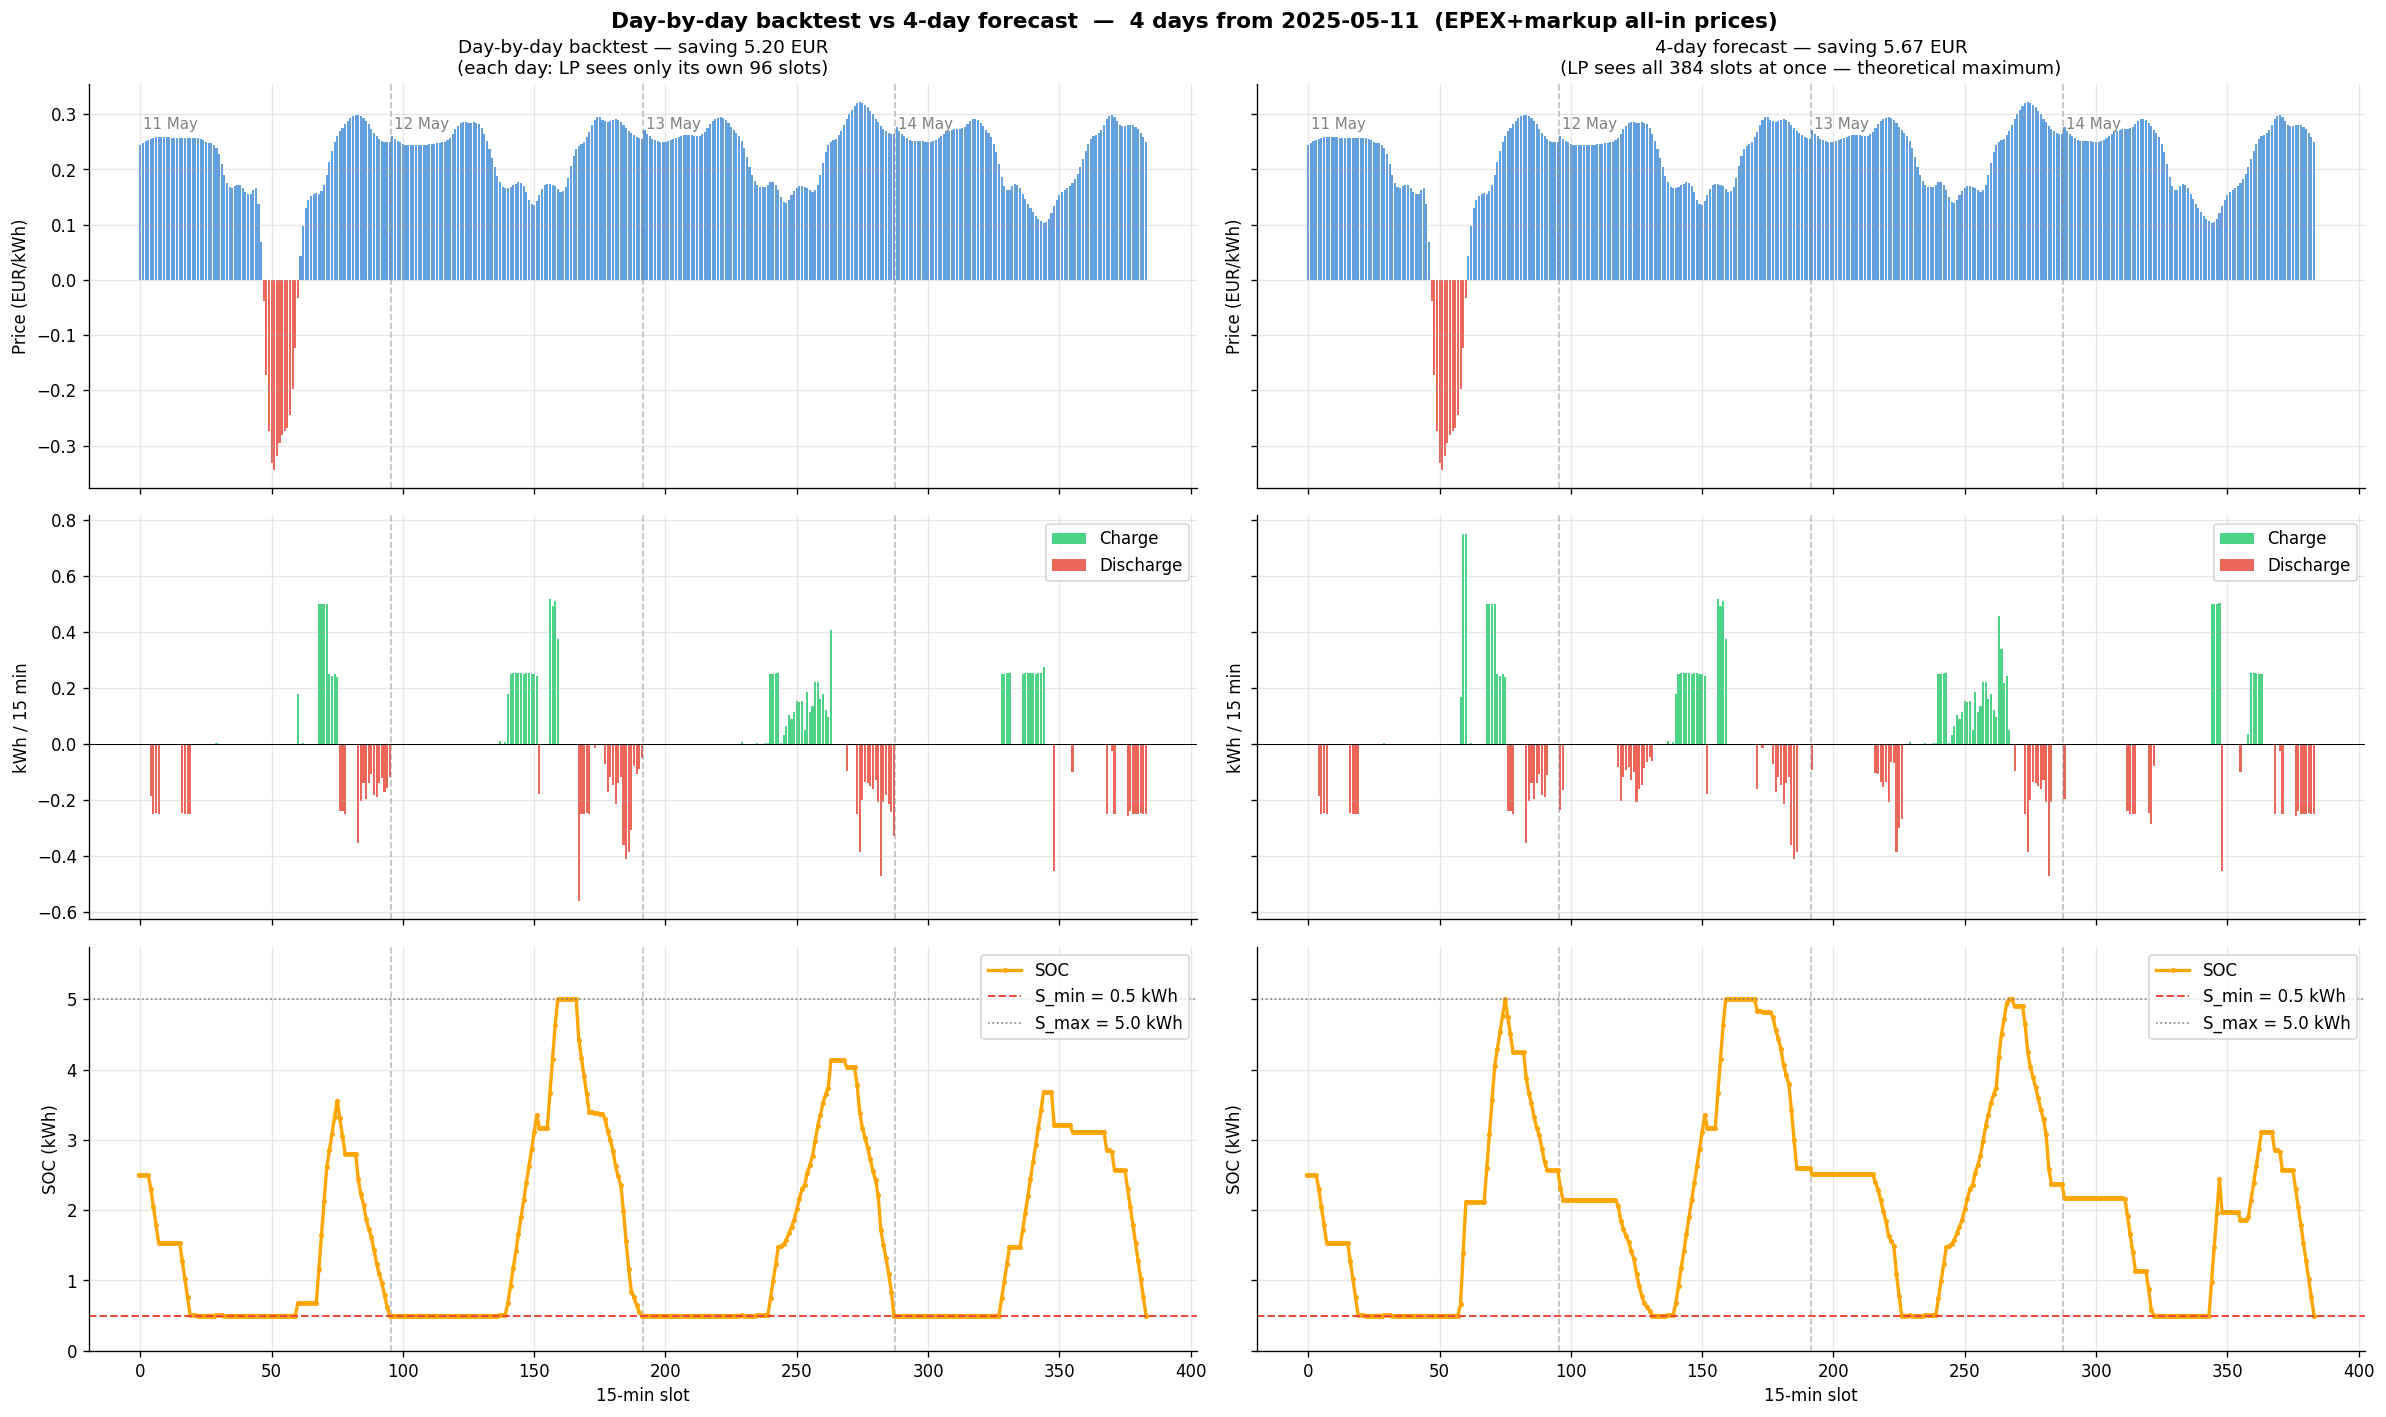

In [10]:
START_DATE = BEST_START   # set by cell 17; override here if needed
N_DAYS     = 4

# all DataFrames have tz-naive index
start_ts = pd.Timestamp(START_DATE)
end_ts   = start_ts + pd.Timedelta(days=N_DAYS)

# ── Slice data (use all-in prices — see cell 17 comment) ─────────────────────
prices_4d = prices_allin_df[(prices_allin_df.index >= start_ts) & (prices_allin_df.index < end_ts)]
load_4d   = load_df[(load_df.index >= start_ts) & (load_df.index < end_ts)]
solar_4d  = solar_df[(solar_df.index >= start_ts) & (solar_df.index < end_ts)]

prices_4d_n = prices_4d.copy()
load_4d_n   = load_4d.copy()
solar_4d_n  = solar_4d.copy()

p_all   = prices_4d_n["price_eur_kwh"].values
l_all   = load_4d_n["consumption"].values
sol_all = solar_4d_n["solar"].values
T       = len(p_all)

def _align(a, n):
    if len(a) >= n: return a[:n]
    return np.append(a, np.repeat(a[-1], n - len(a)))

l_all   = _align(l_all,   T)
sol_all = _align(sol_all, T)

print(f"Window: {START_DATE} + {N_DAYS} days → {T} slots")
print(f"Price range: {p_all.min():.3f} – {p_all.max():.3f} EUR/kWh  "
      f"(slots < PRICE_INJ: {(p_all < PRICE_INJ).sum()})")

# ── Strategy A: day-by-day backtest ──────────────────────────────────────────
bt_4d = backtest(prices_4d, load_4d, S_MAX, P_MAX, ETA_C, ETA_D, S_INIT,
                 strategy="lp", binary=False, deg_cost=DEG, S_min=S_MIN,
                 solar_df=solar_4d, price_inj=PRICE_INJ)

c_bt, d_bt, s_bt = [], [], []
s = S_INIT
for date_ts in pd.to_datetime(bt_4d.index):
    d   = date_ts.date()
    msk = prices_4d_n.index.date == d
    p   = prices_4d_n.loc[msk, "price_eur_kwh"].values
    l   = load_4d_n.loc[msk, "consumption"].values
    sol = solar_4d_n.loc[msk, "solar"].values
    res = optimize_day(p, l, S_MAX, P_MAX, ETA_C, ETA_D, s,
                       cyclic=False, binary=False, deg_cost=DEG, S_min=S_MIN,
                       solar=sol, price_inj=PRICE_INJ)
    c_bt.extend(res["c"]); d_bt.extend(res["d"])
    s_bt.append(s); s_bt.extend(res["s"])
    s = res["s_final"]

# ── Strategy B: full N-day forecast ──────────────────────────────────────────
res_fc = optimize_day(p_all, l_all, S_MAX, P_MAX, ETA_C, ETA_D, S_INIT,
                      cyclic=False, binary=False, deg_cost=DEG, S_min=S_MIN,
                      solar=sol_all, price_inj=PRICE_INJ)

print(f"N-day LP status: {res_fc['status']}")

saving_bt = bt_4d["saving_net"].sum()

# Per-day saving for the forecast
s_fc_eod, saving_fc_day = [], []
for i in range(N_DAYS):
    h      = slice(i * 96, (i + 1) * 96)
    gin_h  = np.array(res_fc["g_in"][h])
    gout_h = np.array(res_fc["g_out"][h])
    deg_h  = DEG * float(np.sum(res_fc["c"][h]))
    cost_e = float(np.dot(p_all[h], gin_h) - PRICE_INJ * gout_h.sum())
    saving_fc_day.append(bt_4d["cost_baseline"].iloc[i] - cost_e - deg_h)
    s_fc_eod.append(float(res_fc["s"][(i + 1) * 96 - 1]))

saving_fc = sum(saving_fc_day)

comparison = bt_4d[["cost_baseline", "saving_net", "s_final"]].copy()
comparison.columns = ["cost_baseline", "saving_backtest", "s_final_backtest"]
comparison["saving_forecast"] = saving_fc_day
comparison["s_final_forecast"] = s_fc_eod
print("\nBacktest vs forecast — per-day comparison:")
print(comparison.round(3))
print(f"\nTotal saving — day-by-day backtest : {saving_bt:.3f} EUR")
print(f"Total saving — {N_DAYS}-day forecast  : {saving_fc:.3f} EUR")
print(f"Extra value of longer forecast       : {saving_fc - saving_bt:+.3f} EUR")

# ── Plot ──────────────────────────────────────────────────────────────────────
s_fc_plot = [S_INIT] + [float(v) for v in res_fc["s"]]
x_slots   = list(range(T))
x_soc_bt  = []
for i in range(N_DAYS):
    x_soc_bt.extend([i * 96 - 0.5] + list(range(i * 96, i * 96 + 96)))
x_soc_fc = [-0.5] + x_slots

bar_colors = ["#e74c3c" if p < 0 else "#4a90d9" for p in p_all]
p_max_val  = max(p_all) if max(p_all) > 0 else 0.1

fig, axes = plt.subplots(3, 2, figsize=(20, 12), sharex="col", sharey="row")
fig.suptitle(
    f"Day-by-day backtest vs {N_DAYS}-day forecast  —  {N_DAYS} days from {START_DATE}"
    f"  (EPEX+markup all-in prices)",
    fontsize=13, fontweight="bold"
)

for col, (title, c_v, d_v, s_v, x_s) in enumerate([
    (f"Day-by-day backtest — saving {saving_bt:.2f} EUR\n"
     f"(each day: LP sees only its own 96 slots)",
     c_bt, d_bt, s_bt, x_soc_bt),
    (f"{N_DAYS}-day forecast — saving {saving_fc:.2f} EUR\n"
     f"(LP sees all {T} slots at once — theoretical maximum)",
     res_fc["c"], res_fc["d"], s_fc_plot, x_soc_fc),
]):
    for i in range(1, N_DAYS):
        bnd = i * 96 - 0.5
        for row in range(3):
            axes[row, col].axvline(bnd, color="gray", lw=1, ls="--", alpha=0.5)
        lbl = (pd.Timestamp(START_DATE) + pd.Timedelta(days=i)).strftime("%d %b")
        axes[0, col].text(bnd + 1, p_max_val * 0.85, lbl, fontsize=9, color="gray")
    axes[0, col].text(1, p_max_val * 0.85,
                      pd.Timestamp(START_DATE).strftime("%d %b"), fontsize=9, color="gray")

    axes[0, col].bar(x_slots, p_all, color=bar_colors, alpha=0.85)
    axes[0, col].set_title(title, fontsize=11)
    axes[0, col].set_ylabel("Price (EUR/kWh)")

    axes[1, col].bar(x_slots, c_v[:T], color="#2ecc71", alpha=0.85, label="Charge")
    axes[1, col].bar(x_slots, [-d for d in d_v[:T]], color="#e74c3c", alpha=0.85, label="Discharge")
    axes[1, col].axhline(0, color="black", lw=0.6)
    axes[1, col].set_ylabel("kWh / 15 min")
    axes[1, col].legend(fontsize=10)

    axes[2, col].plot(x_s, s_v, color="orange", lw=2, marker="o", ms=2, label="SOC")
    axes[2, col].axhline(S_MIN, color="#e74c3c", lw=1.2, ls="--", label=f"S_min = {S_MIN} kWh")
    axes[2, col].axhline(S_MAX, color="gray",    lw=1,   ls=":",  label=f"S_max = {S_MAX} kWh")
    axes[2, col].set_ylim(0, S_MAX * 1.15)
    axes[2, col].set_ylabel("SOC (kWh)")
    axes[2, col].set_xlabel("15-min slot")
    axes[2, col].legend(fontsize=10)

plt.tight_layout()
plt.show()


## 5c. Real SOFAR vs LP forecast — day-by-day comparison

Run LP optimisation day-by-day (as a day-ahead forecast) for a short window in 2026.
Compare three schedules on the same time axis:
- **Real SOFAR** — what the inverter actually did (from `bat_laden_kwh_kw` / `bat_ontladen_kwh_kw`)
- **LP EPEX+markup** — optimal schedule using day-ahead EPEX prices
- **LP dag/nacht** — optimal schedule using fixed day/night tariff

Change `START_DATE` and `N_DAYS` to explore any period.

Cost summary — 4 days from 2026-03-17  (all incl. battery wear)
  Date           Real SOFAR   LP dag/nacht  LP EPEX+markup
  ----------------------------------------------------
  2026-03-17         3.216          2.127       2.395  EUR
  2026-03-18         2.334          2.041       2.148  EUR
  2026-03-19         4.251          4.083       4.140  EUR
  2026-03-20         3.602          3.465       3.926  EUR
  ----------------------------------------------------
  TOTAL             13.403         11.717      12.610  EUR

  LP dag/nacht saves +1.686 EUR vs real SOFAR over 4 days
  LP EPEX+markup saves +0.793 EUR vs real SOFAR over 4 days
  (positive = LP is cheaper; negative = SOFAR was cheaper this window)


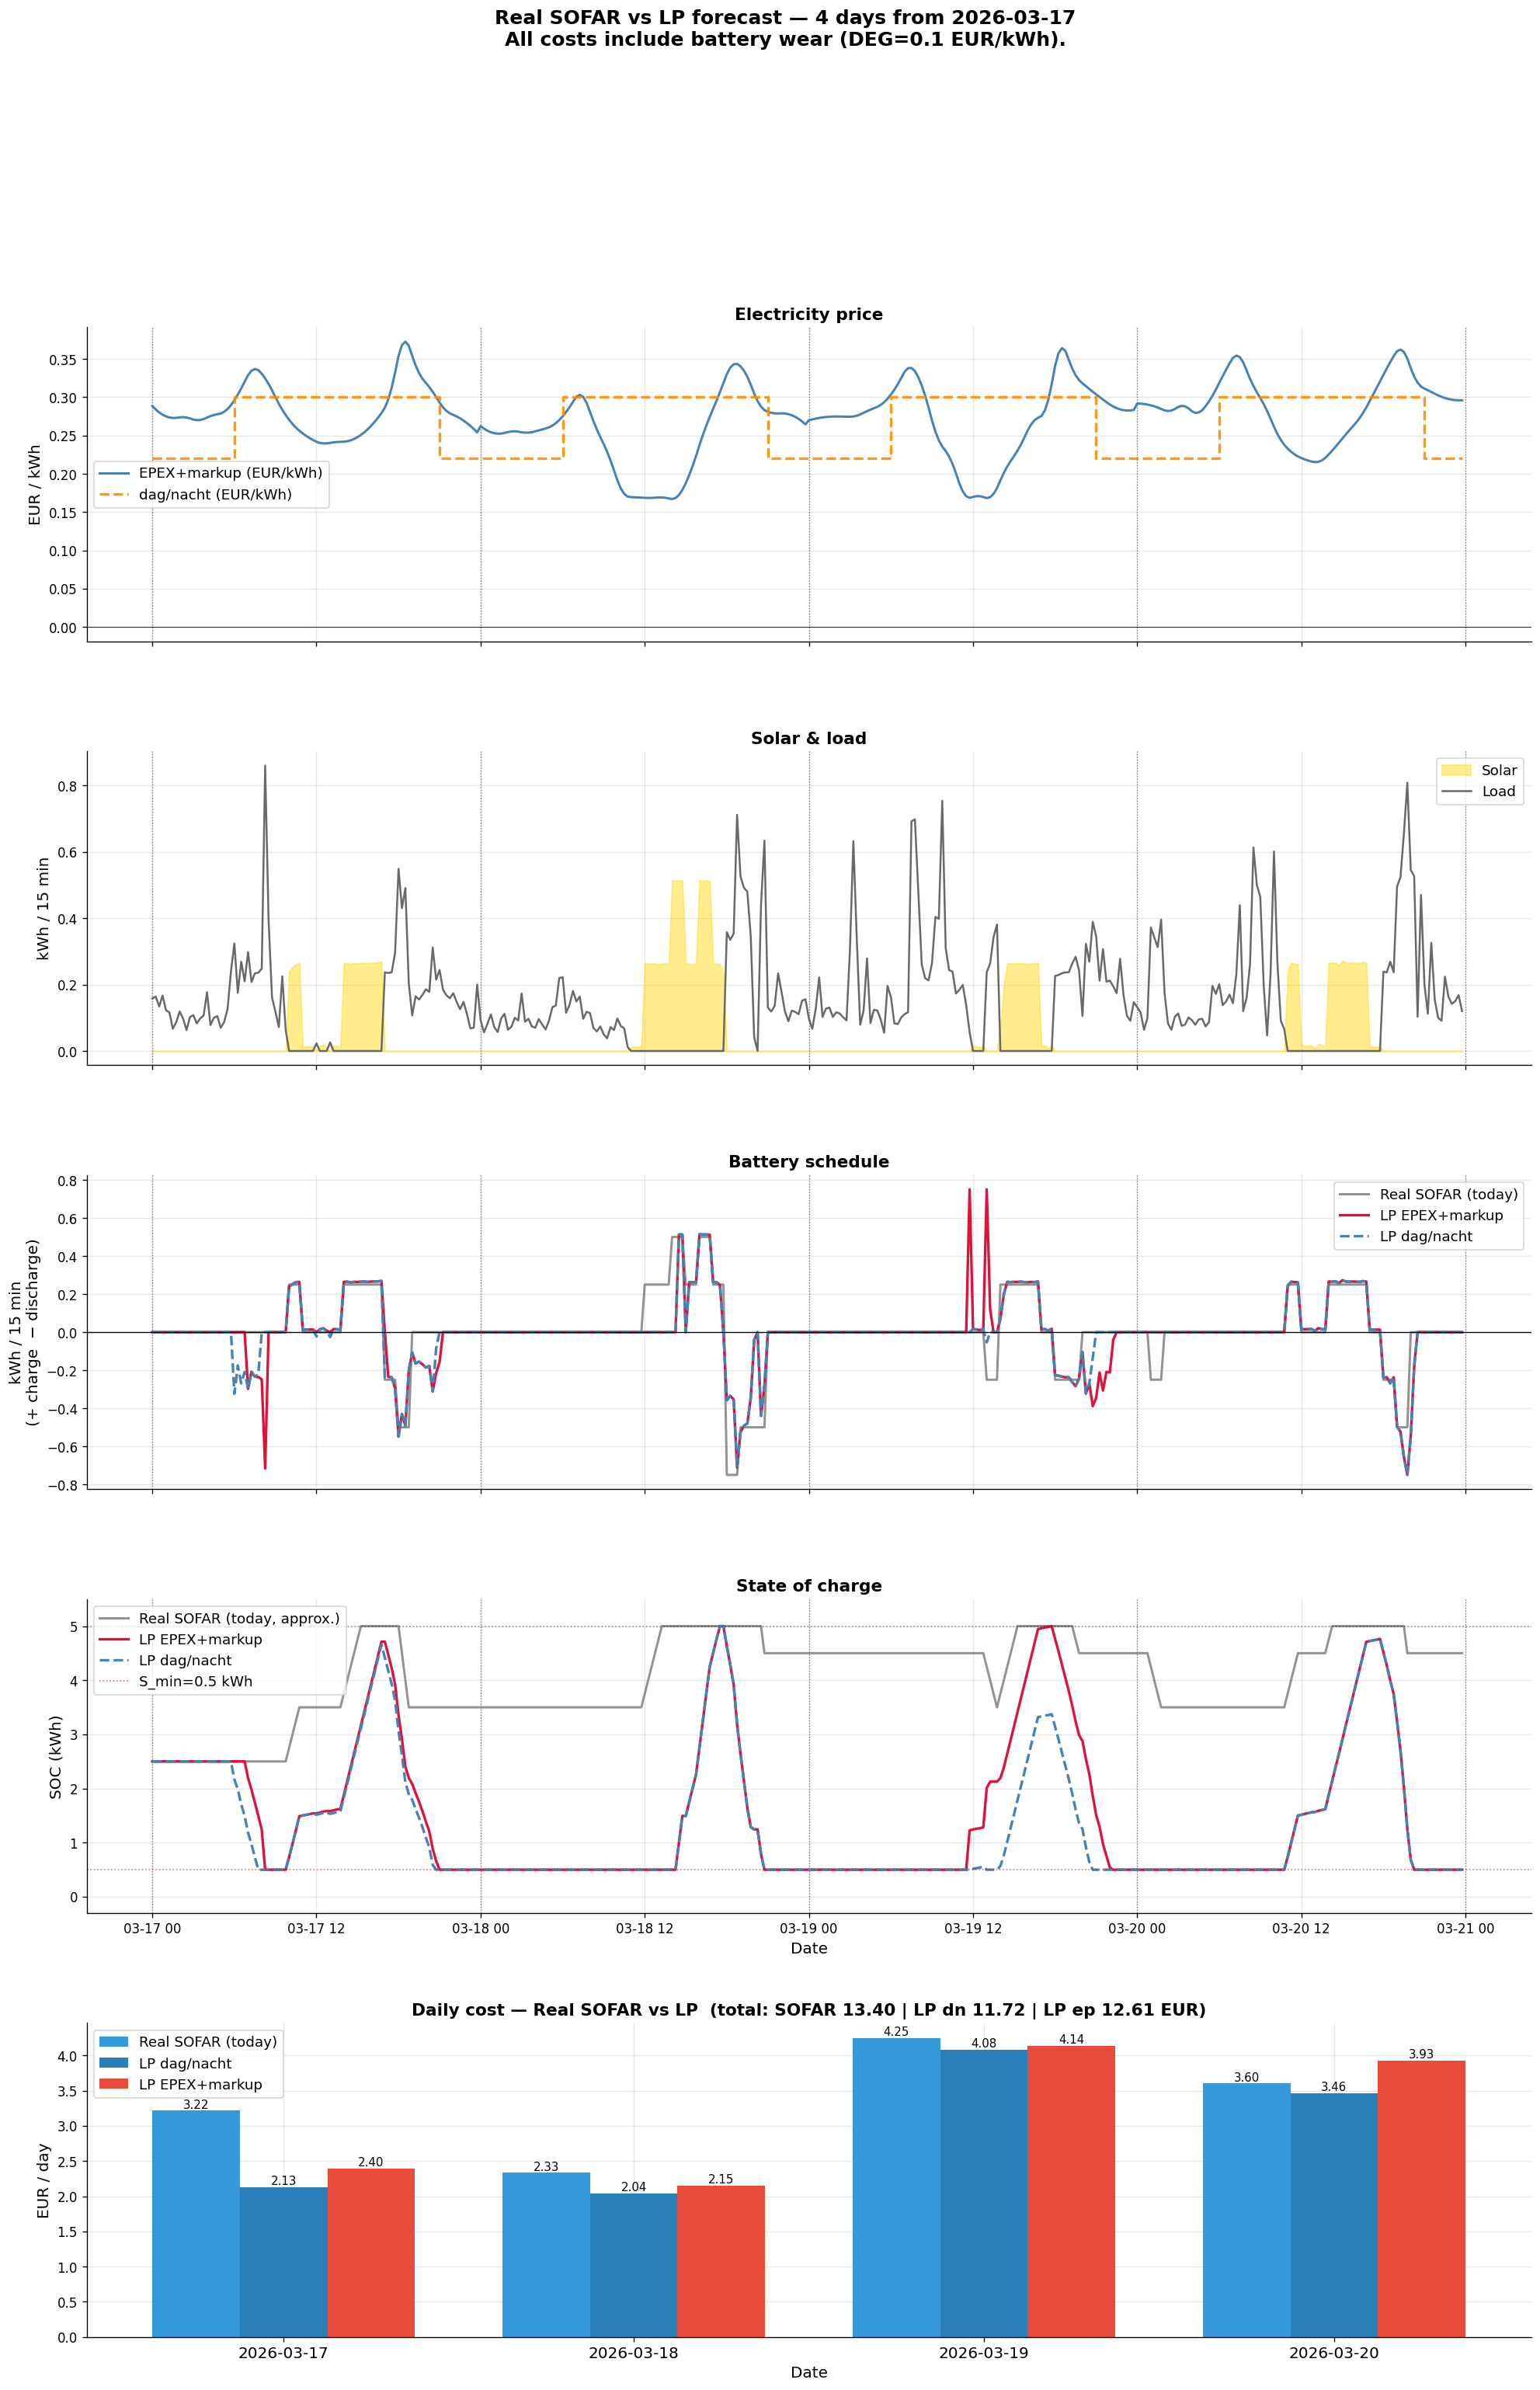

In [11]:
START_DATE = '2026-03-17'   # 4 days with real SOFAR activity + solar in 2026
N_DAYS     = 4

start_ts = pd.Timestamp(START_DATE)
end_ts   = start_ts + pd.Timedelta(days=N_DAYS)
sl = df[(df.index >= start_ts) & (df.index < end_ts)].copy()

if len(sl) == 0:
    print('No data for this date range — check START_DATE')
else:
    # ── Run LP for each day; carry SOC forward per strategy ──────────────────
    c_ep, d_ep, s_ep = [], [], []
    c_dn, d_dn, s_dn = [], [], []
    cost_ep_days, cost_dn_days, dates_run = [], [], []
    s_ep_now = S_INIT
    s_dn_now = S_INIT

    for day_offset in range(N_DAYS):
        date = (start_ts + pd.Timedelta(days=day_offset)).date()
        mask = sl.index.date == date
        if not mask.any():
            continue

        p_ep  = sl.loc[mask, 'price_allin'].values
        p_dn_ = sl.loc[mask, 'price_dag_nacht'].values
        l_day = sl.loc[mask, 'verbruik_kwh'].values
        sol   = sl.loc[mask, 'sl_productie_kwh'].values

        res_ep = optimize_day(p_ep,  l_day, S_MAX, P_MAX, ETA_C, ETA_D, s_ep_now,
                              cyclic=False, binary=True, deg_cost=DEG, S_min=S_MIN,
                              solar=sol, price_inj=PRICE_INJ)
        res_dn = optimize_day(p_dn_, l_day, S_MAX, P_MAX, ETA_C, ETA_D, s_dn_now,
                              cyclic=False, binary=True, deg_cost=DEG, S_min=S_MIN,
                              solar=sol, price_inj=PRICE_INJ)

        c_ep.extend(res_ep['c']);  d_ep.extend(res_ep['d']);  s_ep.extend(res_ep['s'])
        c_dn.extend(res_dn['c']);  d_dn.extend(res_dn['d']);  s_dn.extend(res_dn['s'])
        cost_ep_days.append(res_ep['cost'])
        cost_dn_days.append(res_dn['cost'])
        dates_run.append(date)
        s_ep_now = res_ep['s_final']
        s_dn_now = res_dn['s_final']

    T     = len(sl)
    times = sl.index

    # ── Real SOFAR cost over the same window ─────────────────────────────────
    afname_no_ev_sl = (sl['afname_kwh'] - sl['ev_energie_kwh'].fillna(0)).clip(lower=0)
    sofar_wear_sl   = sl['bat_laden_kwh_kw'].clip(lower=0, upper=0.75) * DEG

    cost_real_dn_daily = (
        (afname_no_ev_sl * sl['price_dag_nacht']).resample('D').sum()
        - (sl['injectie_kwh'] * PRICE_INJ).resample('D').sum()
        + sofar_wear_sl.resample('D').sum()
    )
    cost_real_dn_days = [cost_real_dn_daily.iloc[i] if i < len(cost_real_dn_daily) else 0
                         for i in range(len(dates_run))]

    # ── Approximate SOFAR SOC ─────────────────────────────────────────────────
    net_real = sl['bat_laden_kwh_kw'].clip(lower=0, upper=0.75).values - sl['bat_ontladen_kwh_kw'].values
    s_real   = np.clip(S_INIT + np.cumsum(net_real), 0, S_MAX)
    net_ep   = np.array(c_ep[:T]) - np.array(d_ep[:T])
    net_dn   = np.array(c_dn[:T]) - np.array(d_dn[:T])

    # ── Print cost summary ────────────────────────────────────────────────────
    print(f'Cost summary — {N_DAYS} days from {START_DATE}  (all incl. battery wear)')
    print(f'  {"Date":<12} {"Real SOFAR":>12}  {"LP dag/nacht":>13}  {"LP EPEX+markup":>10}')
    print('  ' + '-' * 52)
    for d, cr, cdn, cep in zip(dates_run, cost_real_dn_days, cost_dn_days, cost_ep_days):
        print(f'  {str(d):<12} {cr:>11.3f}  {cdn:>13.3f}  {cep:>10.3f}  EUR')
    print('  ' + '-' * 52)
    total_r  = sum(cost_real_dn_days)
    total_dn = sum(cost_dn_days)
    total_ep = sum(cost_ep_days)
    print(f'  {"TOTAL":<12} {total_r:>11.3f}  {total_dn:>13.3f}  {total_ep:>10.3f}  EUR')
    print()
    print(f'  LP dag/nacht saves {total_r - total_dn:+.3f} EUR vs real SOFAR over {N_DAYS} days')
    print(f'  LP EPEX+markup saves {total_r - total_ep:+.3f} EUR vs real SOFAR over {N_DAYS} days')
    print(f'  (positive = LP is cheaper; negative = SOFAR was cheaper this window)')

    # ── Plots ─────────────────────────────────────────────────────────────────
    # Panels 0-3: timeseries (shared x). Panel 4: bar chart (separate x).
    fig = plt.figure(figsize=(20, 28))
    gs  = fig.add_gridspec(5, 1, hspace=0.35)
    ax0 = fig.add_subplot(gs[0])
    ax1 = fig.add_subplot(gs[1], sharex=ax0)
    ax2 = fig.add_subplot(gs[2], sharex=ax0)
    ax3 = fig.add_subplot(gs[3], sharex=ax0)
    ax4 = fig.add_subplot(gs[4])          # bar chart — independent x-axis
    axes = [ax0, ax1, ax2, ax3, ax4]

    # hide x tick labels on shared panels except ax3
    for ax in [ax0, ax1, ax2]:
        plt.setp(ax.get_xticklabels(), visible=False)

    fig.suptitle(
        f'Real SOFAR vs LP forecast — {N_DAYS} days from {START_DATE}\n'
        f'All costs include battery wear (DEG={DEG} EUR/kWh).',
        fontsize=15, fontweight='bold', y=1.002)

    # day-separator lines on timeseries panels only
    for d_off in range(N_DAYS + 1):
        ts = start_ts + pd.Timedelta(days=d_off)
        for ax in axes[:4]:
            ax.axvline(ts, color='black', lw=0.8, ls=':', alpha=0.5)

    # Panel 0 — prices
    ax0.plot(times, sl['price_allin'],   color='steelblue', lw=1.8, label='EPEX+markup (EUR/kWh)')
    ax0.step(times, sl['price_dag_nacht'], color='darkorange', lw=2, ls='--',
             alpha=0.9, label='dag/nacht (EUR/kWh)', where='post')
    ax0.axhline(0, color='black', lw=0.5)
    ax0.set_ylabel('EUR / kWh', fontsize=12)
    ax0.set_title('Electricity price', fontsize=13, fontweight='bold')
    ax0.legend(fontsize=11); ax0.yaxis.grid(True, alpha=0.3); ax0.set_axisbelow(True)

    # Panel 1 — solar + load
    ax1.fill_between(times, sl['sl_productie_kwh'].values, alpha=0.45,
                     color='gold', label='Solar')
    ax1.plot(times, sl['verbruik_kwh'].values, color='dimgray', lw=1.5, label='Load')
    ax1.set_ylabel('kWh / 15 min', fontsize=12)
    ax1.set_title('Solar & load', fontsize=13, fontweight='bold')
    ax1.legend(fontsize=11); ax1.yaxis.grid(True, alpha=0.3); ax1.set_axisbelow(True)

    # Panel 2 — charge / discharge
    ax2.plot(times, net_real, color='gray',      lw=1.8, alpha=0.85, label='Real SOFAR (today)')
    ax2.plot(times, net_ep,   color='crimson',   lw=2.0, label='LP EPEX+markup')
    ax2.plot(times, net_dn,   color='steelblue', lw=2.0, ls='--', label='LP dag/nacht')
    ax2.axhline(0, color='black', lw=0.8)
    ax2.set_ylabel('kWh / 15 min\n(+ charge  − discharge)', fontsize=12)
    ax2.set_title('Battery schedule', fontsize=13, fontweight='bold')
    ax2.legend(fontsize=11); ax2.yaxis.grid(True, alpha=0.3); ax2.set_axisbelow(True)

    # Panel 3 — SOC
    ax3.plot(times, s_real,   color='gray',      lw=1.8, alpha=0.85, label='Real SOFAR (today, approx.)')
    ax3.plot(times, s_ep[:T], color='crimson',   lw=2.0, label='LP EPEX+markup')
    ax3.plot(times, s_dn[:T], color='steelblue', lw=2.0, ls='--', label='LP dag/nacht')
    ax3.axhline(S_MIN, color='red',   lw=1, ls=':', alpha=0.6, label=f'S_min={S_MIN} kWh')
    ax3.axhline(S_MAX, color='black', lw=1, ls=':', alpha=0.4)
    ax3.set_ylabel('SOC (kWh)', fontsize=12)
    ax3.set_ylim(-0.3, S_MAX + 0.5)
    ax3.set_title('State of charge', fontsize=13, fontweight='bold')
    ax3.legend(fontsize=11); ax3.yaxis.grid(True, alpha=0.3); ax3.set_axisbelow(True)
    ax3.set_xlabel('Date', fontsize=12)

    # Panel 4 — daily cost bar chart (independent x-axis)
    x  = np.arange(len(dates_run))
    w  = 0.25
    b1 = ax4.bar(x - w, cost_real_dn_days, width=w, color='#3498db', label='Real SOFAR (today)')
    b2 = ax4.bar(x,     cost_dn_days,      width=w, color='#2980b9', label='LP dag/nacht')
    b3 = ax4.bar(x + w, cost_ep_days,      width=w, color='#e74c3c', label='LP EPEX+markup')
    ax4.set_xticks(x)
    ax4.set_xticklabels([str(d) for d in dates_run], fontsize=12)
    ax4.set_ylabel('EUR / day', fontsize=12)
    ax4.set_xlabel('Date', fontsize=12)
    ax4.set_title(
        f'Daily cost — Real SOFAR vs LP  '
        f'(total: SOFAR {total_r:.2f} | LP dn {total_dn:.2f} | LP ep {total_ep:.2f} EUR)',
        fontsize=13, fontweight='bold')
    ax4.legend(fontsize=11)
    ax4.yaxis.grid(True, alpha=0.3); ax4.set_axisbelow(True)
    for bar in list(b1) + list(b2) + list(b3):
        ax4.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
                 f'{bar.get_height():.2f}', ha='center', va='bottom', fontsize=9)

    plt.show()

## 6. Sensitivity analysis — EPEX markup breakeven

At what markup level does switching from dag/nacht to a dynamic EPEX tariff become profitable?

**Setup:**
- **Current contract** — dag/nacht: PRICE_DAG=0.30, PRICE_NACHT=0.22, PRICE_INJ=0.0 EUR/kWh
- **Dynamic tariff** — EPEX spot + markup; injection stays at PRICE_INJ=0.0 EUR/kWh
- Markup = distribution, taxes, and network costs on top of raw EPEX spot price
- The LP controller re-optimises its schedule for each markup value

**Question:** as the markup decreases, at what point does LP on EPEX+markup cost less than staying on dag/nacht?

LP loaded from ..\results\sensitivity\markup_breakeven.csv
Rule loaded from ..\results\sensitivity\markup_breakeven_rule.csv

Markup sensitivity — annual cost (incl. battery wear)
    Markup     LP EPEX    Rule EPEX
  ----------------------------------
      0.05       806.6        854.2
      0.06       861.2        913.8
      0.07       915.6        973.1
      0.08       969.8       1032.4
      0.09      1024.0       1091.7
      0.10      1078.0       1151.1
      0.11      1132.0       1210.2
      0.12      1185.8       1269.6
      0.13      1239.6       1329.0
      0.14      1293.4       1388.4
      0.15      1347.1       1447.8
      0.16      1400.8       1507.1
      0.17      1454.5       1566.5  <- current
      0.18      1508.1       1625.9
      0.19      1561.8       1685.3
      0.20      1615.4       1744.7
      0.21      1669.0       1804.1
      0.22      1722.6       1863.5
      0.23      1776.2       1922.9
      0.24      1829.9       1982.3
      0.25     

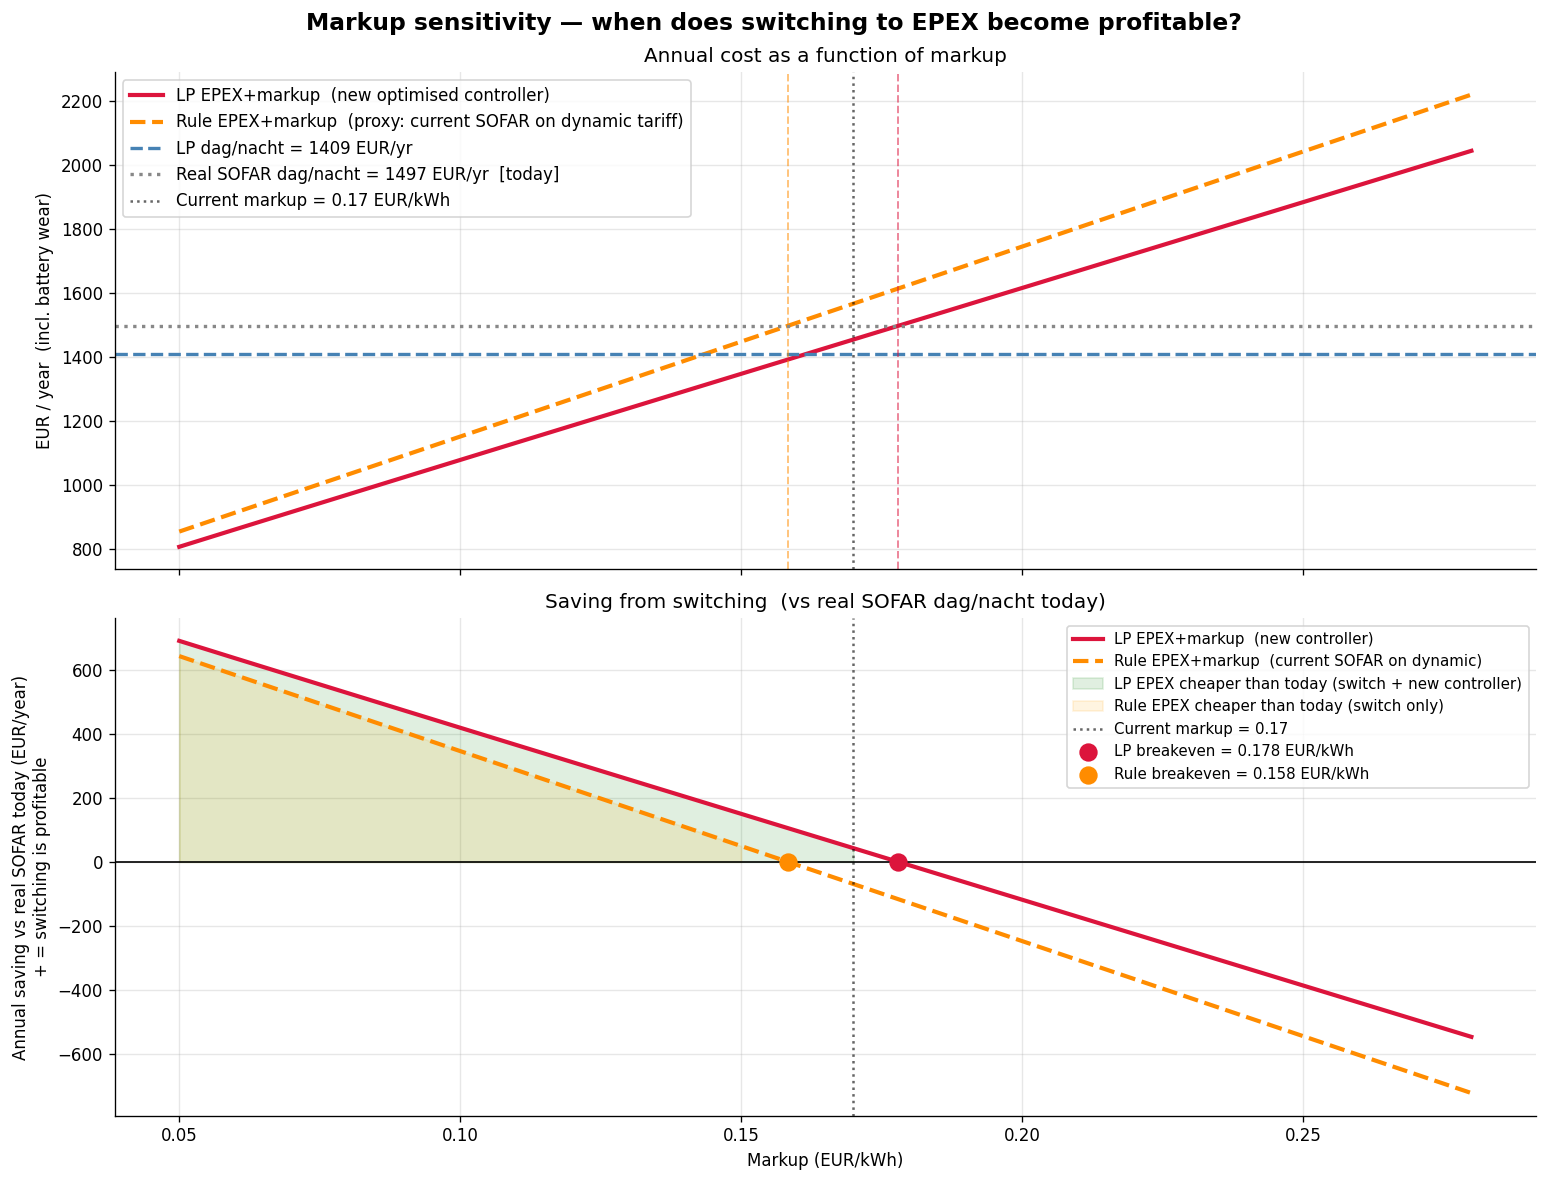

In [12]:
import time
from pathlib import Path

RECOMPUTE_SENS = False
SENS_FILE = Path('../results/sensitivity/markup_breakeven.csv')      # LP sweep
RULE_FILE = Path('../results/sensitivity/markup_breakeven_rule.csv') # Rule sweep
SENS_FILE.parent.mkdir(parents=True, exist_ok=True)

markup_vals = np.round(np.arange(0.05, 0.29, 0.01), 3)   # 0.05 to 0.28

# ── LP sweep (slow, ~10 min) ─────────────────────────────────────────────
if RECOMPUTE_SENS or not SENS_FILE.exists():
    t0 = time.time()
    rows = []
    for m in markup_vals:
        prices_m = pd.DataFrame({'price_eur_kwh': df['price_eur_kwh'] + m}, index=df.index)
        bt_m = backtest(prices_m, load_df, S_MAX, P_MAX, ETA_C, ETA_D, S_INIT,
                        strategy='lp', binary=False, deg_cost=DEG, S_min=S_MIN,
                        solar_df=solar_df, price_inj=PRICE_INJ)
        for dt, val in zip(bt_m.index, bt_m['cost'].values):
            rows.append({'markup': m, 'date': str(dt), 'cost': val})
        print(f'  LP markup={m:.2f}  cost={rows[-1]["cost"]:.1f} EUR  ({time.time()-t0:.0f}s)')
    pd.DataFrame(rows).to_csv(SENS_FILE, index=False)
    print(f'LP done ({time.time()-t0:.0f}s). Saved -> {SENS_FILE}')
else:
    print(f'LP loaded from {SENS_FILE}')

# ── Rule sweep (fast, ~2 min) ─────────────────────────────────────────────
if RECOMPUTE_SENS or not RULE_FILE.exists():
    t0 = time.time()
    rows_r = []
    for m in markup_vals:
        prices_m = pd.DataFrame({'price_eur_kwh': df['price_eur_kwh'] + m}, index=df.index)
        bt_m = backtest(prices_m, load_df, S_MAX, P_MAX, ETA_C, ETA_D, S_INIT,
                        strategy='threshold', deg_cost=DEG, S_min=S_MIN,
                        solar_df=solar_df, price_inj=PRICE_INJ)
        for dt, val in zip(bt_m.index, bt_m['cost'].values):
            rows_r.append({'markup': m, 'date': str(dt), 'cost': val})
    pd.DataFrame(rows_r).to_csv(RULE_FILE, index=False)
    print(f'Rule done ({time.time()-t0:.0f}s). Saved -> {RULE_FILE}')
else:
    print(f'Rule loaded from {RULE_FILE}')

_lp   = pd.read_csv(SENS_FILE)
_rule = pd.read_csv(RULE_FILE)

if 'date' in _lp.columns:
    # New format: daily series per markup -> apply monthly_annual exactly
    markup_vals   = np.sort(_lp['markup'].unique())
    costs_lp_yr   = np.array([
        monthly_annual(
            _lp[_lp['markup'] == m]
            .set_index(pd.to_datetime(_lp[_lp['markup'] == m]['date']))['cost']
        ) for m in markup_vals
    ])
    costs_rule_yr = np.array([
        monthly_annual(
            _rule[_rule['markup'] == m]
            .set_index(pd.to_datetime(_rule[_rule['markup'] == m]['date']))['cost']
        ) for m in markup_vals
    ])
else:
    # Legacy format (sum only): apply proportional correction factor
    markup_vals   = _lp['markup'].values
    _norm_factor  = ann_lp_ep / (lp_ep * scale)
    costs_lp_yr   = _lp['cost'].values * scale * _norm_factor
    costs_rule_yr = _rule['cost'].values * scale * _norm_factor

# ── References (annualised, both include battery wear) ───────────────────
ref_lp_dn    = ann_lp_dn                  # monthly-normalised EUR/year
ref_sofar_dn = ann_sf_dn + ann_sw_dn      # monthly-normalised EUR/year

def interp_breakeven(x_arr, y_arr, ref):
    # Linear interpolation: x where y_arr (increasing) crosses ref
    idx = int(np.searchsorted(y_arr, ref))
    if idx == 0:
        return float(x_arr[0])
    if idx >= len(x_arr):
        return None
    x0, x1 = x_arr[idx - 1], x_arr[idx]
    y0, y1 = y_arr[idx - 1], y_arr[idx]
    return float(x0 + (ref - y0) / (y1 - y0) * (x1 - x0))

be_lp_vs_dn       = interp_breakeven(markup_vals, costs_lp_yr,   ref_lp_dn)
be_lp_vs_sofar    = interp_breakeven(markup_vals, costs_lp_yr,   ref_sofar_dn)
be_rule_vs_sofar  = interp_breakeven(markup_vals, costs_rule_yr, ref_sofar_dn)

idx_cur       = int(np.argmin(np.abs(markup_vals - MARKUP)))
cost_lp_cur   = costs_lp_yr[idx_cur]
cost_rule_cur = costs_rule_yr[idx_cur]

# ── Print summary ─────────────────────────────────────────────────────────
print(f'\nMarkup sensitivity — annual cost (incl. battery wear)')
print(f'  {"Markup":>8}  {"LP EPEX":>10}  {"Rule EPEX":>11}')
print(f'  {"-"*34}')
for m, cl, cr in zip(markup_vals, costs_lp_yr, costs_rule_yr):
    tag = '  <- current' if abs(m - MARKUP) < 0.005 else ''
    print(f'  {m:>8.2f}  {cl:>10.1f}  {cr:>11.1f}{tag}')
print()
print(f'  Reference  LP dag/nacht:              {ref_lp_dn:.1f} EUR/year')
print(f'  Reference  Real SOFAR dag/nacht:       {ref_sofar_dn:.1f} EUR/year')
print(f'  LP EPEX+markup at {MARKUP:.2f}:           {cost_lp_cur:.1f} EUR/year')
print(f'  Rule EPEX+markup at {MARKUP:.2f}:         {cost_rule_cur:.1f} EUR/year')
print()
print('  LP EPEX+markup (new optimised controller):')
if be_lp_vs_dn:
    print(f'    -> beats LP dag/nacht  when markup <= {be_lp_vs_dn:.3f} EUR/kWh')
else:
    print('    -> never beats LP dag/nacht in tested range')
if be_lp_vs_sofar:
    print(f'    -> beats real SOFAR    when markup <= {be_lp_vs_sofar:.3f} EUR/kWh')
else:
    print('    -> never beats real SOFAR in tested range')
print('  Rule EPEX+markup (proxy: current SOFAR on dynamic tariff):')
if be_rule_vs_sofar:
    print(f'    -> beats real SOFAR    when markup <= {be_rule_vs_sofar:.3f} EUR/kWh')
else:
    print('    -> NEVER beats real SOFAR — switching without new controller is a bad idea')

# ── Plot ─────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(13, 10), sharex=True)
fig.suptitle('Markup sensitivity — when does switching to EPEX become profitable?',
             fontsize=14, fontweight='bold')

# Panel 1: absolute annual costs
ax = axes[0]
ax.plot(markup_vals, costs_lp_yr,   color='crimson',    lw=2.5,
        label='LP EPEX+markup  (new optimised controller)')
ax.plot(markup_vals, costs_rule_yr, color='darkorange',  lw=2.5, ls='--',
        label='Rule EPEX+markup  (proxy: current SOFAR on dynamic tariff)')
ax.axhline(ref_lp_dn,    color='steelblue', lw=2, ls='--',
           label=f'LP dag/nacht = {ref_lp_dn:.0f} EUR/yr')
ax.axhline(ref_sofar_dn, color='#888888',   lw=2, ls=':',
           label=f'Real SOFAR dag/nacht = {ref_sofar_dn:.0f} EUR/yr  [today]')
ax.axvline(MARKUP, color='black', lw=1.5, ls=':', alpha=0.6,
           label=f'Current markup = {MARKUP:.2f} EUR/kWh')
if be_lp_vs_sofar:
    ax.axvline(be_lp_vs_sofar,   color='crimson',   lw=1.2, alpha=0.5, ls='--')
if be_rule_vs_sofar:
    ax.axvline(be_rule_vs_sofar, color='darkorange', lw=1.2, alpha=0.5, ls='--')
ax.set_ylabel('EUR / year  (incl. battery wear)')
ax.set_title('Annual cost as a function of markup')
ax.legend(fontsize=10); ax.yaxis.grid(True, alpha=0.3); ax.set_axisbelow(True)

# Panel 2: saving vs real SOFAR dag/nacht (the practical reference)
ax2 = axes[1]
save_lp   = ref_sofar_dn - costs_lp_yr
save_rule = ref_sofar_dn - costs_rule_yr
ax2.plot(markup_vals, save_lp,   color='crimson',   lw=2.5,
         label='LP EPEX+markup  (new controller)')
ax2.plot(markup_vals, save_rule, color='darkorange', lw=2.5, ls='--',
         label='Rule EPEX+markup  (current SOFAR on dynamic)')
ax2.axhline(0, color='black', lw=1)
ax2.fill_between(markup_vals, save_lp, 0,
                 where=save_lp > 0,  alpha=0.12, color='green',
                 label='LP EPEX cheaper than today (switch + new controller)')
ax2.fill_between(markup_vals, save_rule, 0,
                 where=save_rule > 0, alpha=0.12, color='orange',
                 label='Rule EPEX cheaper than today (switch only)')
ax2.axvline(MARKUP, color='black', lw=1.5, ls=':', alpha=0.6,
            label=f'Current markup = {MARKUP:.2f}')
if be_lp_vs_sofar:
    ax2.scatter([be_lp_vs_sofar], [0], color='crimson', s=100, zorder=5,
                label=f'LP breakeven = {be_lp_vs_sofar:.3f} EUR/kWh')
if be_rule_vs_sofar:
    ax2.scatter([be_rule_vs_sofar], [0], color='darkorange', s=100, zorder=5,
                label=f'Rule breakeven = {be_rule_vs_sofar:.3f} EUR/kWh')
ax2.set_xlabel('Markup (EUR/kWh)')
ax2.set_ylabel('Annual saving vs real SOFAR today (EUR/year)\n+ = switching is profitable')
ax2.set_title('Saving from switching  (vs real SOFAR dag/nacht today)')
ax2.legend(fontsize=9); ax2.yaxis.grid(True, alpha=0.3); ax2.set_axisbelow(True)

plt.tight_layout()
plt.show()

## 6b. Sensitivity — battery capacity & power

**What if the household had a different battery system?**

We keep everything fixed (EPEX + markup tariff, same solar panels, same household load) and vary two physical parameters:

| Parameter | Values tested | Current SOFAR |
|---|---|---|
| **S_max** — usable capacity (kWh) | 2.5 · 5 · 7.5 · 10 | **5 kWh** |
| **P_max** — charge/discharge power (kW) | 1.5 · 3 · 5 · 7.5 | **3 kW** |

> Note: LP relaxation (`binary=False`) used for speed — directionally accurate.
>
> ⚠️ Results are **not directly comparable** with the synthetic-data sensitivity (in `02_optimization.ipynb`): this model includes solar, grid injection, and no `d[t] <= load[t]` constraint.
>
> DEG = 0.10 EUR/kWh is held constant for all combinations — valid if battery cost scales proportionally with capacity (market pricing).

Loaded 8352 rows from ..\results\sensitivity\battery_params_sensitivity.csv


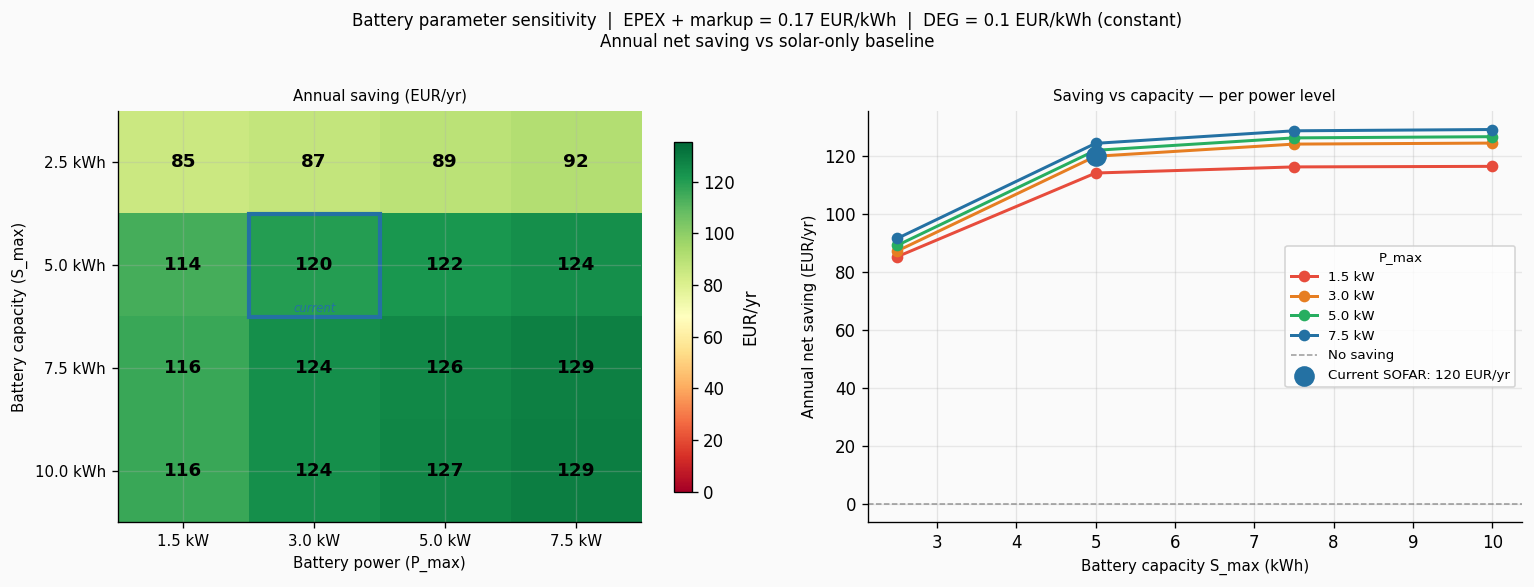


Annual saving (EUR/yr) — rows=S_max, cols=P_max:
p_kw     1.5    3.0    5.0    7.5
s_max                            
2.5     85.0   87.0   89.0   92.0
5.0    114.0  120.0  122.0  124.0
7.5    116.0  124.0  126.0  129.0
10.0   116.0  124.0  127.0  129.0


In [13]:
import time
RECOMPUTE_SENS2 = False
SENS2_FILE = Path('../results/sensitivity/battery_params_sensitivity.csv')

S_MAX_VALS = [2.5, 5.0, 7.5, 10.0]   # kWh capacity
P_KW_VALS  = [1.5, 3.0, 5.0, 7.5]    # kW power

if RECOMPUTE_SENS2:
    from itertools import product as iproduct
    rows, t_all = [], time.time()
    for s_max, p_kw in iproduct(S_MAX_VALS, P_KW_VALS):
        p_max = p_kw / 4;  s_min = 0.10 * s_max;  s = 0.50 * s_max;  t0 = time.time()
        for date in sorted(set(df.index.date)):
            day = df.loc[str(date)]
            p   = (day['price_eur_kwh'] + MARKUP).values
            l   = day['verbruik_kwh'].values
            sol = day['sl_productie_kwh'].values
            T   = len(p)
            if T not in [92, 96, 100]:
                continue
            cost_b = float(np.dot(p, np.maximum(l - sol, 0)))
            res = optimize_day(p, l, s_max, p_max, ETA_C, ETA_D, s,
                               cyclic=False, binary=False, deg_cost=DEG,
                               S_min=s_min, solar=sol, price_inj=PRICE_INJ)
            rows.append({'date': date, 's_max': s_max, 'p_kw': p_kw,
                         'cost': res['cost'], 'cost_baseline': cost_b})
            s = res['s_final']
        print(f'  S_max={s_max:.1f} kWh, P={p_kw:.1f} kW -> {time.time()-t0:.0f}s')
    print(f'Total: {time.time()-t_all:.0f}s')
    df_s2 = pd.DataFrame(rows)
    SENS2_FILE.parent.mkdir(parents=True, exist_ok=True)
    df_s2.to_csv(SENS2_FILE, index=False)
    print(f'Saved {len(df_s2)} rows -> {SENS2_FILE}')
else:
    df_s2 = pd.read_csv(SENS2_FILE, parse_dates=['date'])
    print(f'Loaded {len(df_s2)} rows from {SENS2_FILE}')

# ── Annual saving per combination ─────────────────────────────────────────────
df_s2['saving'] = df_s2['cost_baseline'] - df_s2['cost']
ann_rows = []
for (s_max, p_kw), grp in df_s2.groupby(['s_max', 'p_kw']):
    ser = grp.set_index('date')['saving']
    ser.index = pd.to_datetime(ser.index)
    ann_rows.append({'s_max': s_max, 'p_kw': p_kw, 'saving_yr': monthly_annual(ser)})
df_ann   = pd.DataFrame(ann_rows)
pivot_hm = df_ann.pivot(index='s_max', columns='p_kw', values='saving_yr')
_S2 = sorted(pivot_hm.index.tolist())
_P2 = sorted(pivot_hm.columns.tolist())

# ── Figure: heatmap (left) + line chart (right) ───────────────────────────────
fig, (ax_hm, ax_ln) = plt.subplots(1, 2, figsize=(13, 5))
fig.patch.set_facecolor('#fafafa')
fig.suptitle(
    f'Battery parameter sensitivity  |  EPEX + markup = {MARKUP} EUR/kWh  |  '
    f'DEG = {DEG} EUR/kWh (constant)\nAnnual net saving vs solar-only baseline',
    fontsize=10
)

_vmin = min(float(pivot_hm.values.min()), 0)
_vmax = float(pivot_hm.values.max()) * 1.05
_im   = ax_hm.imshow(pivot_hm.values, cmap='RdYlGn', aspect='auto', vmin=_vmin, vmax=_vmax)
ax_hm.set_xticks(range(len(_P2)))
ax_hm.set_xticklabels([f'{p:.1f} kW' for p in _P2], fontsize=9)
ax_hm.set_yticks(range(len(_S2)))
ax_hm.set_yticklabels([f'{s:.1f} kWh' for s in _S2], fontsize=9)
ax_hm.set_xlabel('Battery power (P_max)', fontsize=9)
ax_hm.set_ylabel('Battery capacity (S_max)', fontsize=9)
ax_hm.set_title('Annual saving (EUR/yr)', fontsize=9)
for _i, _s in enumerate(_S2):
    for _j, _p in enumerate(_P2):
        _v = pivot_hm.loc[_s, _p]
        ax_hm.text(_j, _i, f'{_v:.0f}', ha='center', va='center', fontsize=11, fontweight='bold',
                   color='white' if _v < _vmax * 0.30 else 'black')
_ci = _S2.index(S_MAX); _cj = _P2.index(P_KW)
ax_hm.add_patch(plt.Rectangle((_cj-0.5, _ci-0.5), 1, 1,
                               fill=False, edgecolor='#2471a3', lw=2.5))
ax_hm.text(_cj, _ci+0.42, 'current', ha='center', va='center',
           fontsize=7, color='#2471a3', style='italic')
plt.colorbar(_im, ax=ax_hm, label='EUR/yr', shrink=0.85)

_p2_cols = ['#e74c3c', '#e67e22', '#27ae60', '#2471a3']
for _pk, _col in zip(_P2, _p2_cols):
    _sub = df_ann[df_ann['p_kw'] == _pk].sort_values('s_max')
    ax_ln.plot(_sub['s_max'], _sub['saving_yr'], marker='o', color=_col,
               lw=1.8, ms=6, label=f'{_pk:.1f} kW')
ax_ln.axhline(0, color='#555', lw=0.9, ls='--', alpha=0.6, label='No saving')
_curr_v = float(pivot_hm.loc[S_MAX, P_KW])
ax_ln.scatter([S_MAX], [_curr_v], s=130, color='#2471a3', zorder=5,
              label=f'Current SOFAR: {_curr_v:.0f} EUR/yr')
ax_ln.set_xlabel('Battery capacity S_max (kWh)', fontsize=9)
ax_ln.set_ylabel('Annual net saving (EUR/yr)', fontsize=9)
ax_ln.set_title('Saving vs capacity — per power level', fontsize=9)
ax_ln.legend(fontsize=8, title='P_max', title_fontsize=8)
ax_ln.set_facecolor('#fafafa')
ax_ln.spines['top'].set_visible(False); ax_ln.spines['right'].set_visible(False)
ax_ln.yaxis.grid(True, alpha=0.25); ax_ln.set_axisbelow(True)

plt.tight_layout(pad=1.5)
plt.show()

print('\nAnnual saving (EUR/yr) — rows=S_max, cols=P_max:')
print(pivot_hm.round(0).to_string())

## 6c. Decomposition — solar self-consumption vs price arbitrage

**Why does the battery save only ~120 EUR/yr even with a perfect forecast?**

This section answers two questions:
1. Where does the saving actually come from — price arbitrage or solar self-consumption?
2. Which factor limits the saving more: battery wear cost (DEG) or EPEX price spread?

**Key insight:** the battery mainly stores **free solar surplus** (otherwise injected at 0 EUR/kWh)
and uses it later — not EPEX price arbitrage. This changes which parameter matters most.

**Purpose:** Decompose the LP battery saving into solar surplus buffering vs price arbitrage, and test sensitivity to DEG cost and EPEX spread — to understand what drives (and limits) the saving.

Profitable spread threshold:  0.213 EUR/kWh
Days spread > threshold:      4%  (96% below — no cycling)
Median daily EPEX spread:     0.106 EUR/kWh

Gross saving decomposition:
  Price arbitrage (est.)            1 EUR/yr  (1%)
  Solar surplus buffering          195 EUR/yr  (99%)
  GROSS total                     196 EUR/yr
  DEG wear cost               -   76 EUR/yr  (39% of gross)
  NET saving                      120 EUR/yr
Battery charged ~ 764 kWh/yr  (2.09 kWh/day avg)


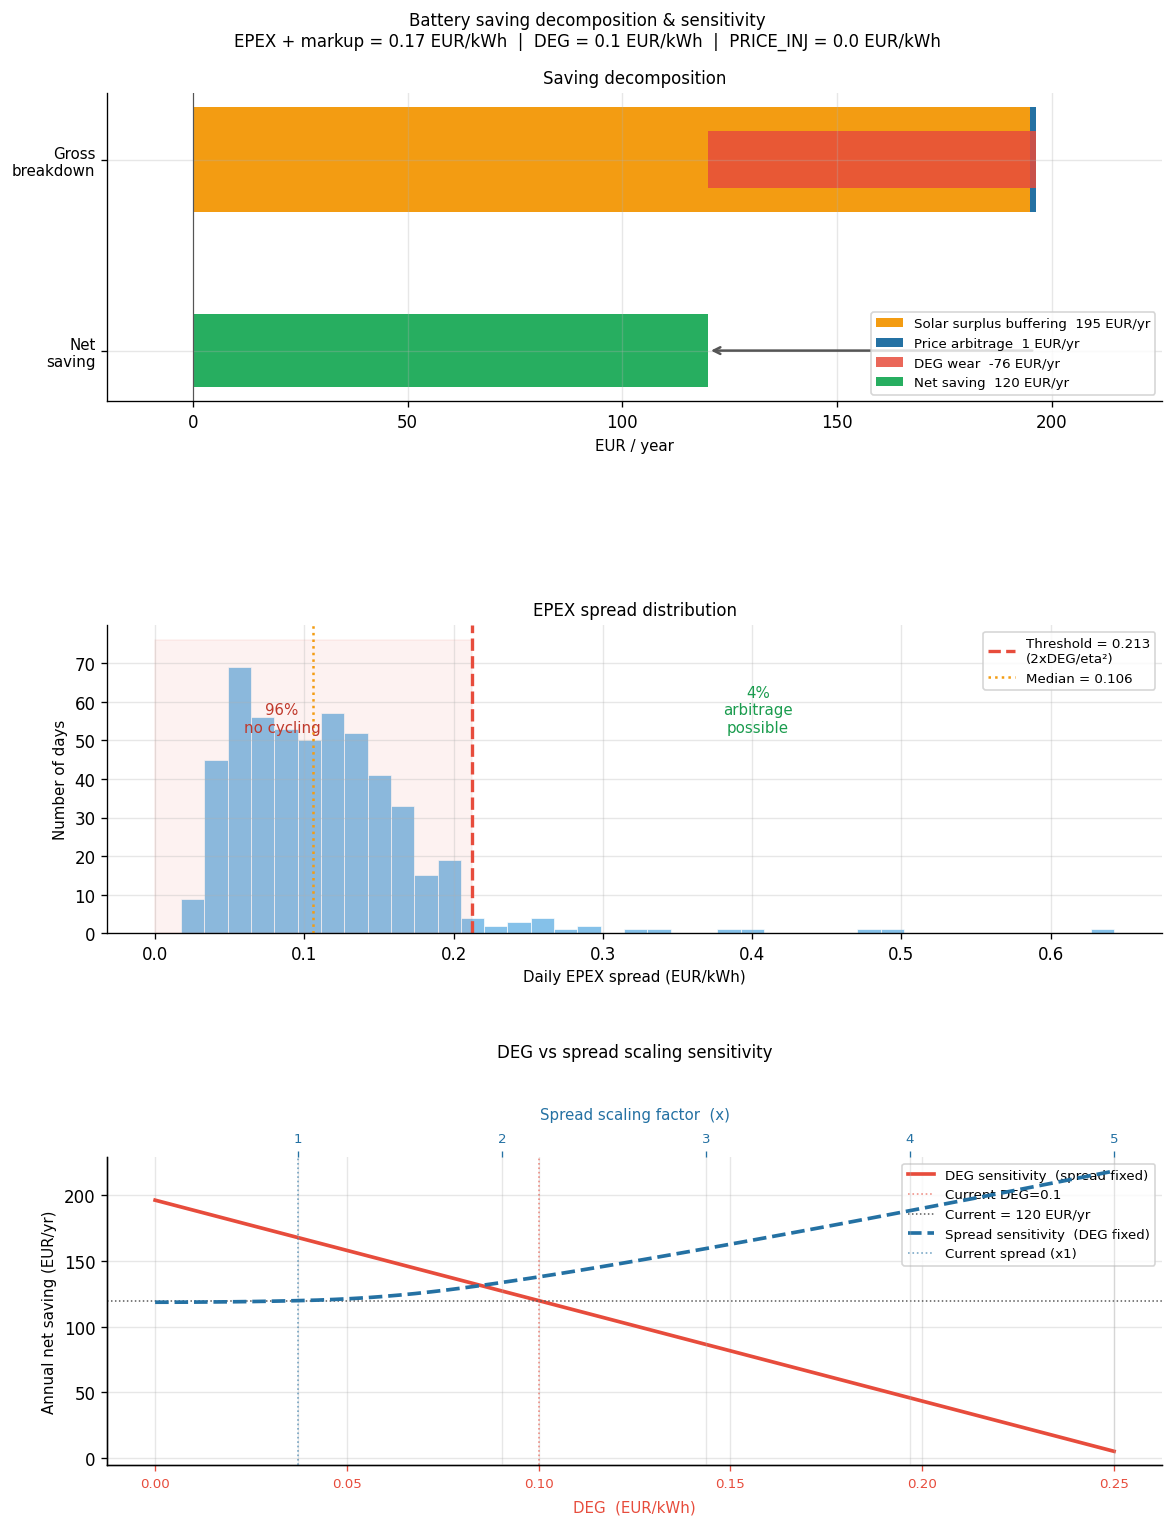


Sensitivity comparison:
  DEG halved (0.05):   +38 EUR/yr  -> 158 EUR/yr
  DEG = 0:             +76 EUR/yr  -> 196 EUR/yr
  Spread x2:           +13 EUR/yr  -> 133 EUR/yr
  Spread x3:           +40 EUR/yr  -> 160 EUR/yr

Conclusion:
  96% of days: spread < threshold -> no profitable arbitrage
  Main saving source: solar surplus buffering (99% of gross)
  DEG bottleneck: 76 EUR/yr wear = 39% of gross
  => DEG is the dominant cost factor, not price spread


In [32]:
# ── Daily EPEX spread distribution ───────────────────────────────────────────
daily_p = df.groupby(df.index.date)['price_eur_kwh'].agg(['min', 'max'])
daily_p['spread'] = daily_p['max'] - daily_p['min']

# Minimum spread for a profitable battery cycle (cover round-trip DEG cost)
MIN_SPREAD = 2 * DEG / (ETA_C * ETA_D)
pct_above  = (daily_p['spread'] > MIN_SPREAD).mean() * 100

# ── Decomposition ─────────────────────────────────────────────────────────────
ann_deg          = monthly_annual(bt_lp_allin['cost_degradation'])
ann_saving_net   = monthly_annual(bt_lp_allin['saving_net'])
ann_saving_gross = ann_saving_net + ann_deg

# Theoretical pure-arbitrage (1 cycle/day on days spread > threshold, net of DEG)
th_arb  = (daily_p['spread'] * P_MAX * ETA_C * ETA_D - DEG * P_MAX * 2).clip(lower=0)
ann_arb = monthly_annual(th_arb)
ann_sc  = ann_saving_gross - ann_arb          # residual = solar surplus buffering (battery stores excess solar at ~0 EUR/kWh, discharges later at grid price)

kWh_charged_yr = ann_deg / DEG   # kWh charged per year (from backtest)

print(f'Profitable spread threshold:  {MIN_SPREAD:.3f} EUR/kWh')
print(f'Days spread > threshold:      {pct_above:.0f}%  ({100-pct_above:.0f}% below — no cycling)')
print(f'Median daily EPEX spread:     {daily_p["spread"].median():.3f} EUR/kWh')
print()
print('Gross saving decomposition:')
print(f'  Price arbitrage (est.)       {ann_arb:>6.0f} EUR/yr  ({ann_arb/ann_saving_gross*100:.0f}%)')
print(f'  Solar surplus buffering       {ann_sc:>6.0f} EUR/yr  ({ann_sc/ann_saving_gross*100:.0f}%)')
print(f'  GROSS total                  {ann_saving_gross:>6.0f} EUR/yr')
print(f'  DEG wear cost               -{ann_deg:>5.0f} EUR/yr  ({ann_deg/ann_saving_gross*100:.0f}% of gross)')
print(f'  NET saving                   {ann_saving_net:>6.0f} EUR/yr')
print(f'Battery charged ~ {kWh_charged_yr:.0f} kWh/yr  ({kWh_charged_yr/365:.2f} kWh/day avg)')

# ── Sensitivity arrays ────────────────────────────────────────────────────────
# DEG sensitivity: kWh charged constant (approximation)
deg_range    = np.linspace(0.0, 0.25, 60)
saving_vs_deg = np.clip(ann_saving_gross - deg_range * kWh_charged_yr, 0, None)

# Spread scaling: solar SC fixed, arbitrage scales with spread factor
factors = np.linspace(0.3, 5.0, 60)
saving_vs_spread = []
for f in factors:
    sp_f  = daily_p['spread'] * f
    arb_f = monthly_annual((sp_f * P_MAX * ETA_C * ETA_D - DEG * P_MAX * 2).clip(lower=0))
    saving_vs_spread.append(max(ann_sc + arb_f - ann_deg, 0))
saving_vs_spread = np.array(saving_vs_spread)

# ── Figure: 3 panels ─────────────────────────────────────────────────────────
fig, axes = plt.subplots(3, 1, figsize=(10, 13))
fig.suptitle(
    'Battery saving decomposition & sensitivity\n'
    f'EPEX + markup = {MARKUP} EUR/kWh  |  DEG = {DEG} EUR/kWh  |  PRICE_INJ = {PRICE_INJ} EUR/kWh',
    fontsize=10
)

# Panel 1 — Decomposition bar
ax = axes[0]
bar_h = 0.55
# Gross bar: solar SC + arbitrage stacked
ax.barh(1.0, ann_sc,  bar_h, color='#f39c12',
        label=f'Solar surplus buffering  {ann_sc:.0f} EUR/yr')
ax.barh(1.0, ann_arb, bar_h, left=ann_sc, color='#2471a3',
        label=f'Price arbitrage  {ann_arb:.0f} EUR/yr')
# DEG shown as negative extension
ax.barh(1.0, -ann_deg, bar_h * 0.55, left=ann_saving_gross,
        color='#e74c3c', alpha=0.85, label=f'DEG wear  -{ann_deg:.0f} EUR/yr')
# Net saving bar
ax.barh(0.0, ann_saving_net, bar_h * 0.7, color='#27ae60',
        label=f'Net saving  {ann_saving_net:.0f} EUR/yr')
ax.annotate('', xy=(ann_saving_net, 0.0), xytext=(ann_saving_gross, 0.0),
            arrowprops=dict(arrowstyle='->', color='#555', lw=1.5))
ax.set_yticks([1.0, 0.0])
ax.set_yticklabels(['Gross\nbreakdown', 'Net\nsaving'], fontsize=9)
ax.set_xlabel('EUR / year', fontsize=9)
ax.set_title('Saving decomposition', fontsize=10)
ax.legend(fontsize=8, loc='lower right')
ax.axvline(0, color='#555', lw=0.7)
ax.set_xlim(-20, ann_saving_gross * 1.15)
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)

# Panel 2 — Spread histogram
ax = axes[1]
ax.hist(daily_p['spread'], bins=40, color='#85c1e9', edgecolor='white', lw=0.4)
ymax = ax.get_ylim()[1]
ax.axvline(MIN_SPREAD, color='#e74c3c', lw=2.0, ls='--',
           label=f'Threshold = {MIN_SPREAD:.3f}\n(2xDEG/eta²)')
ax.axvline(daily_p['spread'].median(), color='#f39c12', lw=1.5, ls=':',
           label=f'Median = {daily_p["spread"].median():.3f}')
ax.fill_betweenx([0, ymax * 1.05], 0, MIN_SPREAD, color='#e74c3c', alpha=0.07)
ax.text(MIN_SPREAD * 0.40, ymax * 0.72,
        f'{100-pct_above:.0f}%\nno cycling', ha='center', fontsize=9, color='#c0392b')
ax.text(min(MIN_SPREAD * 1.9, daily_p["spread"].max() * 0.75), ymax * 0.72,
        f'{pct_above:.0f}%\narbitrage\npossible', ha='center', fontsize=9, color='#1a9c4e')
ax.set_xlabel('Daily EPEX spread (EUR/kWh)', fontsize=9)
ax.set_ylabel('Number of days', fontsize=9)
ax.set_title('EPEX spread distribution', fontsize=10)
ax.legend(fontsize=8)
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)

# Panel 3 — DEG vs spread sensitivity (dual x-axis)
ax  = axes[2]
ax2 = ax.twiny()
ax.plot(deg_range, saving_vs_deg, color='#e74c3c', lw=2.2,
        label=f'DEG sensitivity  (spread fixed)')
ax.axvline(DEG, color='#e74c3c', lw=1.0, ls=':', alpha=0.6,
           label=f'Current DEG={DEG}')
ax2.plot(factors, saving_vs_spread, color='#2471a3', lw=2.2, ls='--',
         label='Spread sensitivity  (DEG fixed)')
ax2.axvline(1.0, color='#2471a3', lw=1.0, ls=':', alpha=0.6,
            label='Current spread (x1)')
ax.axhline(ann_saving_net, color='#555', lw=0.9, ls=':',
           label=f'Current = {ann_saving_net:.0f} EUR/yr')
ax.set_xlabel('DEG  (EUR/kWh)', fontsize=9, color='#e74c3c', labelpad=6)
ax.set_ylabel('Annual net saving (EUR/yr)', fontsize=9)
ax.set_title('DEG vs spread scaling sensitivity', fontsize=10, pad=30)
ax.tick_params(axis='x', colors='#e74c3c', labelsize=8)
ax2.set_xlabel('Spread scaling factor  (x)', fontsize=9, color='#2471a3', labelpad=8)
ax2.tick_params(axis='x', colors='#2471a3', labelsize=8)
ax2.spines['top'].set_color('#2471a3')
ax2.spines['top'].set_linewidth(1.5)
lines1, lab1 = ax.get_legend_handles_labels()
lines2, lab2 = ax2.get_legend_handles_labels()
ax.legend(lines1 + lines2, lab1 + lab2, fontsize=8, loc='upper right')
ax.spines['right'].set_visible(False)

plt.tight_layout(pad=1.5, h_pad=3.5)
plt.show()

# ── Summary ───────────────────────────────────────────────────────────────────
deg_half  = float(ann_saving_gross - (DEG / 2) * kWh_charged_yr)
deg_zero  = float(ann_saving_gross)
sp2_idx   = int(np.argmin(np.abs(factors - 2.0)))
sp3_idx   = int(np.argmin(np.abs(factors - 3.0)))
print()
print('Sensitivity comparison:')
print(f'  DEG halved (0.05):   +{deg_half - ann_saving_net:.0f} EUR/yr  -> {deg_half:.0f} EUR/yr')
print(f'  DEG = 0:             +{deg_zero - ann_saving_net:.0f} EUR/yr  -> {deg_zero:.0f} EUR/yr')
print(f'  Spread x2:           +{saving_vs_spread[sp2_idx] - ann_saving_net:.0f} EUR/yr  -> {saving_vs_spread[sp2_idx]:.0f} EUR/yr')
print(f'  Spread x3:           +{saving_vs_spread[sp3_idx] - ann_saving_net:.0f} EUR/yr  -> {saving_vs_spread[sp3_idx]:.0f} EUR/yr')
print()
print('Conclusion:')
print(f'  {100-pct_above:.0f}% of days: spread < threshold -> no profitable arbitrage')
print(f'  Main saving source: solar surplus buffering ({ann_sc/ann_saving_gross*100:.0f}% of gross)')
print(f'  DEG bottleneck: {ann_deg:.0f} EUR/yr wear = {ann_deg/ann_saving_gross*100:.0f}% of gross')
print(f'  => DEG is the dominant cost factor, not price spread')


## 7. Payback analysis (illustrative)

> ⚠️ **This section is illustrative.** The full system cost (7 000 EUR) covers solar panels,
> battery, and inverter. A complete payback calculation requires comparing Fluvius bills
> **before** and **after** installation. That data is not available here — all measurements
> start after installation. The battery alone does not pay off at current tariffs (confirmed
> on synthetic data as well — see the earlier synthetic analysis).

What this section *can* show:

- **Battery saving** (measured): LP optimal saves ~92 EUR/yr on dag/nacht tariff vs the
  solar-only baseline. This is the only component directly measurable from the available data.

Read the chart below as: *"How long to recover 7 000 EUR from battery saving alone?"*
The real answer — including solar panels — requires pre-installation Fluvius bills.

**Assumptions for the 10-year projection:**
- Base annual saving = annualised average over the backtest period (522 days), battery only
- **Battery degradation** (~2.5 %/yr LFP): battery stores less → proportionally lower savings
- **Electricity price growth** (~3 %/yr Belgian historical avg): higher future prices → higher savings in EUR


### 7c. Battery lifespan — EFC vs payback period

Manufacturers guarantee LFP batteries for a fixed number of **Equivalent Full Cycles (EFC)**
and a calendar period — whichever limit is reached first.

> **1 EFC** = charging the full battery capacity once (5 kWh in → 5 kWh out).

**Key question:** does the full system (solar + battery, 7 000 EUR) pay back
before the battery warranty expires?

If the system is still in debt when the battery dies, the investment never recovers.

In [15]:
WARRANTY_EFC   = 6000   # guaranteed EFC (BYD LFP datasheet)
WARRANTY_YEARS = 10     # calendar warranty cap

# kWh charged per year — monthly normalised (charging peaks in summer)
kWh_yr_dn    = monthly_annual(bt_dn['cost_degradation'])       / DEG
kWh_yr_allin = monthly_annual(bt_lp_allin['cost_degradation']) / DEG

efc_yr_dn    = kWh_yr_dn    / S_MAX
efc_yr_allin = kWh_yr_allin / S_MAX

life_dn    = min(WARRANTY_EFC / efc_yr_dn,    WARRANTY_YEARS)
life_allin = min(WARRANTY_EFC / efc_yr_allin, WARRANTY_YEARS)

print(f'Warranty: {WARRANTY_EFC} EFC  or  {WARRANTY_YEARS} years (whichever comes first)')
print()
print(f'{"":40s}  {"LP dag/nacht":>13}  {"LP EPEX+markup":>15}')
print('-' * 72)
print(f'{"kWh charged per year":40s}  {kWh_yr_dn:>13.0f}  {kWh_yr_allin:>15.0f}')
print(f'{"EFC per year":40s}  {efc_yr_dn:>13.1f}  {efc_yr_allin:>15.1f}')
print(f'{"Cycle-limited lifespan (years)":40s}  {WARRANTY_EFC/efc_yr_dn:>13.1f}  {WARRANTY_EFC/efc_yr_allin:>15.1f}')
print(f'{"Effective lifespan — calendar cap (years)":40s}  {life_dn:>13.1f}  {life_allin:>15.1f}')


Warranty: 6000 EFC  or  10 years (whichever comes first)

                                           LP dag/nacht   LP EPEX+markup
------------------------------------------------------------------------
kWh charged per year                                646              764
EFC per year                                      129.1            152.8
Cycle-limited lifespan (years)                     46.5             39.3
Effective lifespan — calendar cap (years)           10.0             10.0


## 8. Top 10 best days

Which days did each battery strategy save the most?

The top 10 are selected **independently per strategy** — a day can be the best for LP dag/nacht
but average for EPEX+markup, or poor for the real SOFAR inverter (e.g. on a freeze day).

Best days are typically driven by a combination of:
- **High solar surplus** — charges the battery for free, shifts self-consumption away from grid
- **High household load** — more kWh the battery can offset during expensive periods
- **Wide EPEX price spread** — more arbitrage potential (especially relevant for EPEX+markup strategy)
- **SOFAR availability** — days with inverter freeze events drop out of Real SOFAR's best days

── Top 10 best days  LP dag/nacht ───────────────────────────────────────
              weekday  season  solar_kwh  price_range  cost_baseline  saving_net
date                                                                            
2025-04-22    Tuesday  Spring       6.02        0.125           3.10        0.99
2025-04-11     Friday  Spring       5.73        0.156           2.93        0.93
2025-04-03   Thursday  Spring       5.02        0.183           3.78        0.91
2025-07-07     Monday  Summer       5.41        0.164           3.01        0.87
2025-03-20   Thursday  Spring       6.02        0.177           3.28        0.85
2026-03-18  Wednesday  Spring       8.34        0.176           2.89        0.85
2025-03-25    Tuesday  Spring       4.97        0.099           2.81        0.84
2025-07-14     Monday  Summer       6.60        0.092           2.82        0.84
2025-08-12    Tuesday  Summer       7.42        0.160           4.70        0.83
2025-06-20     Friday  Summer      

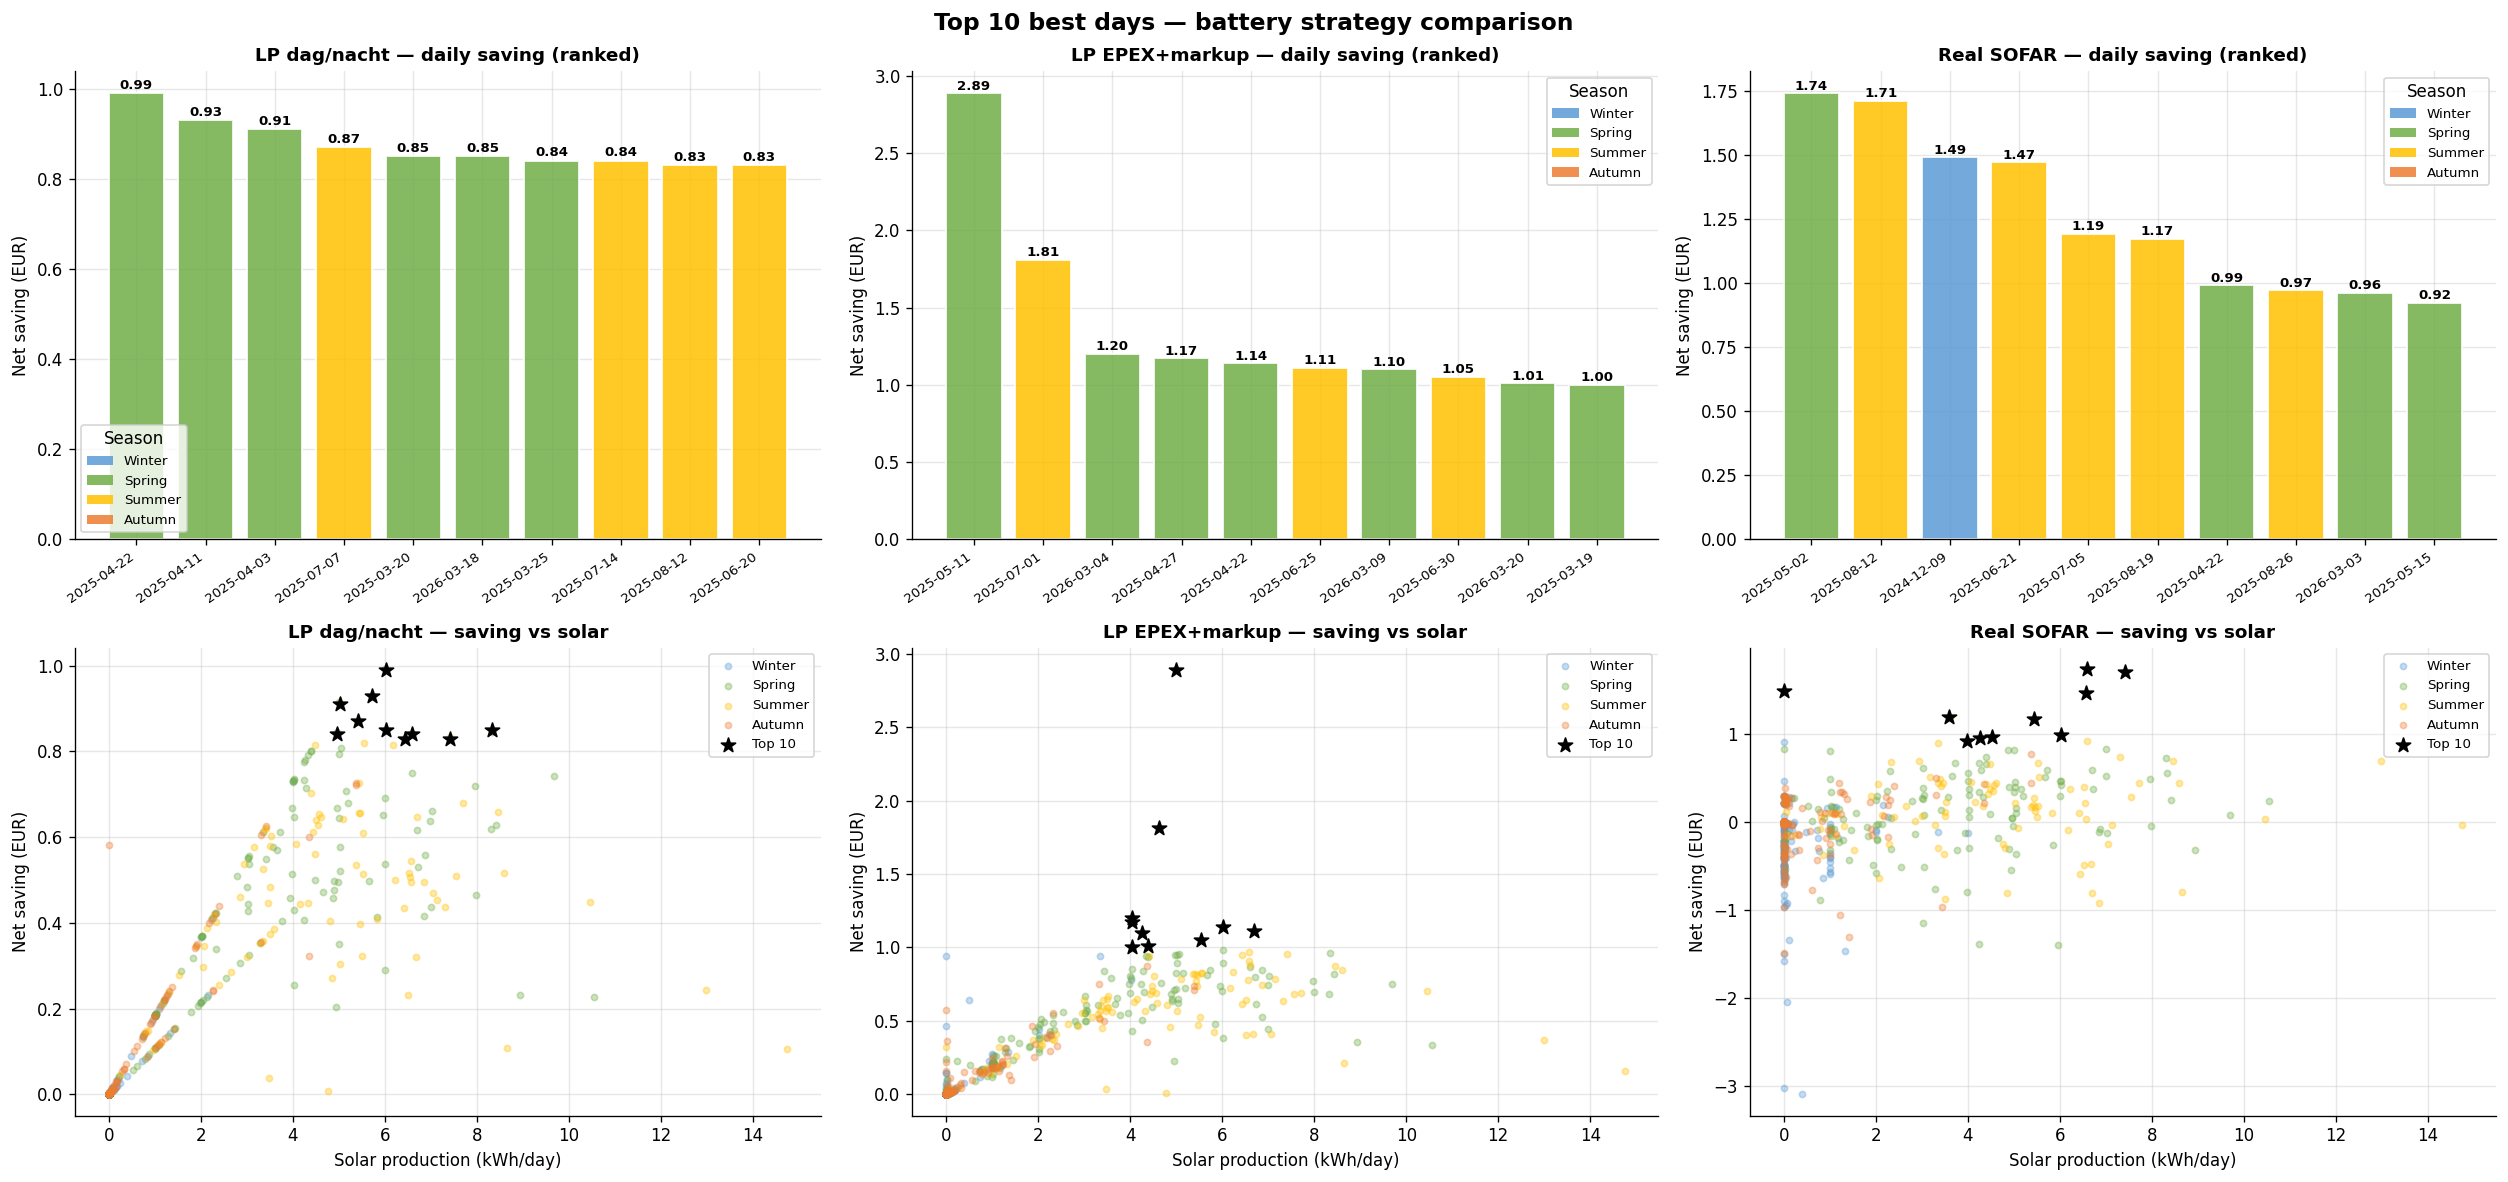

In [16]:
# EPEX price range per day (context for scatter plot)
p_stats = (
    df['price_eur_kwh']
    .groupby(df.index.date)
    .agg(price_min='min', price_max='max', price_mean='mean')
)
p_stats['price_range'] = p_stats['price_max'] - p_stats['price_min']
p_stats.index = pd.to_datetime(p_stats.index)

sol_daily = solar_df['solar'].resample('D').sum()

def season(m):
    return {12:'Winter',1:'Winter',2:'Winter',
            3:'Spring',4:'Spring',5:'Spring',
            6:'Summer',7:'Summer',8:'Summer'}.get(m, 'Autumn')

SEASON_COLORS = {'Winter':'#5b9bd5','Spring':'#70ad47','Summer':'#ffc000','Autumn':'#ed7d31'}

def enrich(bt):
    b = bt.copy()
    b.index = pd.to_datetime(b.index)
    b = b.join(p_stats[['price_range', 'price_mean']])
    b = b.join(sol_daily.rename('solar_kwh'))
    b['weekday'] = b.index.day_name()
    b['season']  = b.index.month.map(season)
    return b

bt8    = enrich(bt_dn)       # LP dag/nacht
bt8_ep = enrich(bt_lp_allin) # LP EPEX+markup

# Real SOFAR: sofar_dn + sofar_wear_day have date index (datetime.date)
# saving_net = solar-only baseline minus real SOFAR total cost
sofar_combined = sofar_dn + sofar_wear_day
_sf_vals = sofar_combined.reindex(bt8.index.date).values
bt8_sf = bt8.copy()
bt8_sf['saving_net'] = bt8['cost_baseline'].values - _sf_vals
bt8_sf = bt8_sf.dropna(subset=['saving_net'])

COLS = ['weekday', 'season', 'solar_kwh', 'price_range', 'cost_baseline', 'saving_net']

top10    = bt8.nlargest(10, 'saving_net')[COLS].copy()
top10_ep = bt8_ep.nlargest(10, 'saving_net')[COLS].copy()
top10_sf = bt8_sf.nlargest(10, 'saving_net')[COLS].copy()

for t in [top10, top10_ep, top10_sf]:
    t['solar_kwh']     = t['solar_kwh'].round(2)
    t['price_range']   = t['price_range'].round(3)
    t['cost_baseline'] = t['cost_baseline'].round(2)
    t['saving_net']    = t['saving_net'].round(2)

print('── Top 10 best days  LP dag/nacht ───────────────────────────────────────')
print(top10.to_string())
print()
print('── Top 10 best days  LP EPEX+markup ────────────────────────────────────')
print(top10_ep.to_string())
print()
print('── Top 10 best days  Real SOFAR dag/nacht ───────────────────────────────')
print(top10_sf.to_string())

# ── 2×3 chart ─────────────────────────────────────────────────────────────
from matplotlib.patches import Patch
fig, axes = plt.subplots(2, 3, figsize=(21, 10))
fig.suptitle('Top 10 best days — battery strategy comparison', fontsize=14, fontweight='bold')

def bar_panel(ax, top, title):
    colors = [SEASON_COLORS.get(s, 'gray') for s in top['season']]
    x = range(len(top))
    bars = ax.bar(x, top['saving_net'].values, color=colors, alpha=0.85,
                  edgecolor='white', lw=1.2)
    ax.set_xticks(x)
    ax.set_xticklabels([str(d.date()) for d in top.index],
                       rotation=35, ha='right', fontsize=8)
    ax.set_ylabel('Net saving (EUR)', fontsize=10)
    ax.set_title(title, fontsize=11, fontweight='bold')
    for bar, val in zip(bars, top['saving_net'].values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
                f'{val:.2f}', ha='center', va='bottom', fontsize=8, fontweight='bold')
    ax.legend([Patch(facecolor=c, alpha=0.85) for c in SEASON_COLORS.values()],
              list(SEASON_COLORS.keys()), fontsize=8, title='Season')
    ax.yaxis.grid(True, alpha=0.3); ax.set_axisbelow(True)

def scatter_panel(ax, bt_all, top, title):
    for seas, col in SEASON_COLORS.items():
        mask = bt_all['season'] == seas
        ax.scatter(bt_all.loc[mask, 'solar_kwh'], bt_all.loc[mask, 'saving_net'],
                   color=col, alpha=0.35, s=14, label=seas)
    ax.scatter(top['solar_kwh'], top['saving_net'],
               color='black', s=80, zorder=5, marker='*', label='Top 10')
    ax.set_xlabel('Solar production (kWh/day)', fontsize=10)
    ax.set_ylabel('Net saving (EUR)', fontsize=10)
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.legend(fontsize=8)
    ax.yaxis.grid(True, alpha=0.3); ax.set_axisbelow(True)

bar_panel(axes[0,0], top10,    'LP dag/nacht — daily saving (ranked)')
bar_panel(axes[0,1], top10_ep, 'LP EPEX+markup — daily saving (ranked)')
bar_panel(axes[0,2], top10_sf, 'Real SOFAR — daily saving (ranked)')
scatter_panel(axes[1,0], bt8,    top10,    'LP dag/nacht — saving vs solar')
scatter_panel(axes[1,1], bt8_ep, top10_ep, 'LP EPEX+markup — saving vs solar')
scatter_panel(axes[1,2], bt8_sf, top10_sf, 'Real SOFAR — saving vs solar')

plt.tight_layout()
plt.show()

In [17]:
# Explicit: cost difference EPEX+markup vs dag/nacht, no battery
# Justifies the "~73 EUR/yr more" claim in conclusions
diff_no_bat = ann_s0_ep - ann_s0_dn
print("Without any battery — tariff comparison:")
print(f"  Solar only, EPEX+markup : {ann_s0_ep:.0f} EUR/yr")
print(f"  Solar only, dag/nacht   : {ann_s0_dn:.0f} EUR/yr")
print(f"  Difference              : {diff_no_bat:+.0f} EUR/yr")
print(f"  EPEX+markup costs {diff_no_bat:.0f} EUR/yr MORE than dag/nacht (no battery)")

Without any battery — tariff comparison:
  Solar only, EPEX+markup : 1574 EUR/yr
  Solar only, dag/nacht   : 1501 EUR/yr
  Difference              : +73 EUR/yr
  EPEX+markup costs 73 EUR/yr MORE than dag/nacht (no battery)


## 9. Conclusions

### What was modelled
A real Belgian household with solar panels (measured data) and a SOFAR ME3000SP inverter
with BYD LFP battery (5 kWh / 3 kW). Backtest covers **522 days** of real consumption,
solar production, and EPEX prices. Three battery strategies were compared against the
solar-only baseline (panels but no battery). EV charging (~2 400 kWh/yr) is excluded
from all scenarios — it cancels out identically across strategies.

---

### ⚠️ What this analysis can and cannot measure

All data was collected **after** solar panel installation. The SOFAR CT clamps measure
energy at the grid connection point only. Solar energy consumed directly by appliances
(self-consumption) never crosses the meter — it is invisible in every column of the dataset.

As a result:

- **`verbruik_kwh`** = net grid import for the house. Already equals zero during solar hours
  because panels cover the load directly. It is not total appliance consumption.
- **`cost_baseline`** (Solar only, no battery) = `verbruik × price` — this is already the
  post-installation cost. It does not represent life without solar panels.
- **The gap between cost_baseline and LP cost = battery saving (~92 EUR/yr)** — this is
  the only saving that can be measured directly from the available data.

**Solar panel saving vs a no-solar scenario cannot be derived from this dataset.**
To quantify it, compare Fluvius annual bills before and after installation.

---

### Key findings — battery savings (directly measured)

| Scenario | Battery saving | vs solar-only baseline |
|---|---|---|
| **LP dag/nacht** (optimal control, current tariff) | **+92 EUR/yr** | see §5 |
| **Real SOFAR today** (actual inverter, dag/nacht) | **+4 EUR/yr** | see §5 |
| **LP EPEX+markup** (optimal control, dynamic tariff) | **+120 EUR/yr** | see §5 |

> *Battery savings are computed as: cost (solar only, no battery) − cost (strategy with battery).*
> *Both sides already include solar panels. The saving is purely attributable to the battery.*

---

### ⚠️ EPEX+markup payback looks better — why it is misleading

The EPEX scenario shows a shorter payback and higher annual saving.
This does **not** mean switching to EPEX is the right choice.

The reason: each saving is measured relative to its **own tariff baseline**.
Without any system, EPEX+markup costs **~73 EUR/year more** than dag/nacht for this household
(computed explicitly in the cell above).
The solar+battery system recovers that extra cost and more — so the relative saving is larger.
But in absolute terms, LP EPEX still costs ~46 EUR/year more than LP dag/nacht.

| Question | Answer | See |
|---|---|---|
| Should I switch to EPEX? | **No** — at markup 0.17, LP EPEX costs ~46 EUR/yr more | §4, §6 |
| At what markup does EPEX become worth switching? | ≤ 0.162 EUR/kWh (LP optimal) | §6 |

---

### Why the real SOFAR battery barely contributes

1. **Inverter freeze events** — the SOFAR ME3000SP freezes on ~56 days/year (89 periods),
   stopping all energy flows. No saving is possible on those days.
   (source: [01_eda_real_load.ipynb](./01_eda_real_load.ipynb), § 4 — sensor freeze analysis)
2. **Sub-optimal control** — the built-in rule charges from the grid at times that are not
   always cheaper than discharge periods, occasionally costing more than solar-only.
3. **Result** — on the current dag/nacht tariff the real SOFAR battery saving averages
   **+4 EUR/year** net of wear. The battery barely breaks even; LP optimal control would save +92 EUR/year.

---

### Negative EPEX prices (2025)

In 2025, **541 hours** had negative EPEX prices (min −0.46 EUR/kWh), concentrated in
spring and summer (source: [01_eda_real_load.ipynb](./01_eda_real_load.ipynb), §10 — EPEX join).
An LP controller exploits these automatically by charging at negative
prices (grid pays the household to consume). The current SOFAR controller does not.

---

### Limitations

- Backtest covers only 1.4 years — seasonal patterns are partially observed.
- **Solar panel saving is not measurable from this data.** All measurements are post-installation.
  Solar self-consumption (energy panels deliver directly to appliances) is invisible to the
  SOFAR CT clamps and cannot be quantified from this dataset.
- `sl_productie_kwh` captures solar sent to the grid or battery but not self-consumption.
  It is derived from the grid energy balance and is the correct signal for LP optimisation.
- Battery wear is modelled as a fixed cost (0.10 EUR/kWh charged); real degradation
  depends on depth-of-discharge and temperature.
- EV charging (~2 400 kWh/yr) is excluded from all saving figures — EV cost is identical
  across all scenarios and cancels out.
- SOFAR freeze root cause is unknown — if fixed, real SOFAR performance would improve significantly.


## 10. Consumption forecast sensitivity

**Question:** does using a *forecast* of household consumption (instead of the actual load)
change the LP schedule enough to affect cost?

**Method:**
1. Build a rough consumption forecast: average 15-min load by (weekday × slot) over the full dataset.
2. Run the LP twice per day:
   - with **actual** load → optimal schedule (lower bound)
   - with **forecast** load → schedule a real controller would compute at 13:00
3. Evaluate the forecast schedule at **actual** load so costs are on the same basis.
4. Compare annual costs.

A large gap means consumption forecasting matters; a small gap confirms it doesn't.

In [18]:
# ── §10a  Build average-consumption profile ─────────────────────────────────
# Forecast = average load per (weekday, 15-min slot) — 7 × 96 = 672 values

df_s10 = df[['verbruik_kwh']].copy()
df_s10['weekday'] = df_s10.index.weekday          # 0=Mon … 6=Sun
df_s10['slot']    = df_s10.index.hour * 4 + df_s10.index.minute // 15

profile_fc = (
    df_s10.groupby(['weekday', 'slot'])['verbruik_kwh']
    .mean()
)
profile_dict = profile_fc.to_dict()   # fast lookup: (weekday, slot) -> kWh

print(f'Profile shape: {profile_fc.shape}  (7 x 96 = {7*96})')
print(profile_fc.describe().round(4))


Profile shape: (672,)  (7 x 96 = 672)
count    672.0000
mean       0.1779
std        0.0597
min        0.0546
25%        0.1344
50%        0.1649
75%        0.2262
max        0.3450
Name: verbruik_kwh, dtype: float64


In [19]:
# ── §10b  Dual backtest: actual-load LP vs forecast-load LP ─────────────────
# Run LP twice per day; evaluate forecast schedule at actual load.
# Grid balance (from optimize_day source): g_in - g_out = load + c - d - solar
# d[t] is AC discharge output — eta_d already absorbed into SOC balance.

import time

rows_s10 = []
soc_s10  = S_INIT
t0_s10   = time.time()

for date, grp in df.groupby(df.index.date):
    if len(grp) < 96:
        continue

    p      = grp['price_allin'].values        # EPEX + markup (same as bt_lp_allin)
    l_act  = grp['verbruik_kwh'].values
    sol    = grp['sl_productie_kwh'].values

    # Build forecast load from average profile
    wd    = grp.index[0].weekday()
    slots = grp.index.hour * 4 + grp.index.minute // 15
    l_fc  = np.array([profile_dict.get((wd, int(s)), float(l_act.mean())) for s in slots])

    kw = dict(S_min=S_MIN, deg_cost=DEG, solar=sol, price_inj=PRICE_INJ,
              cyclic=False, binary=False)

    # LP with actual load (lower-bound reference)
    res_act = optimize_day(p, l_act, S_MAX, P_MAX, ETA_C, ETA_D, soc_s10, **kw)
    if res_act['status'] != 'Optimal':
        continue

    # LP with forecast load
    res_fc = optimize_day(p, l_fc, S_MAX, P_MAX, ETA_C, ETA_D, soc_s10, **kw)
    if res_fc['status'] != 'Optimal':
        continue

    # Evaluate forecast schedule at actual load
    c_fc = np.array(res_fc['c'])
    d_fc = np.array(res_fc['d'])
    net_grid = l_act + c_fc - d_fc - sol     # grid balance (d is AC output)
    g_in     = np.maximum(net_grid,  0.0)
    g_out    = np.maximum(-net_grid, 0.0)
    cost_fc_eval = (
        float(np.dot(p, g_in) - PRICE_INJ * np.dot(p, g_out))
        + res_fc['cost_degradation']
    )

    rows_s10.append({
        'date':         pd.Timestamp(date),
        'cost_act':     res_act['cost'],
        'cost_fc_eval': cost_fc_eval,
    })

    soc_s10 = res_act['s_final']   # carry over from actual-LP run

elapsed_s10 = time.time() - t0_s10
print(f'Done: {len(rows_s10)} days in {elapsed_s10:.1f}s')
df_s10_res = pd.DataFrame(rows_s10).set_index('date')


Done: 520 days in 91.3s


LP with actual load:          1454.3 EUR/yr
LP forecast (eval at actual): 1539.3 EUR/yr
Gap (forecast overhead):      +85.0 EUR/yr  (+5.85%)


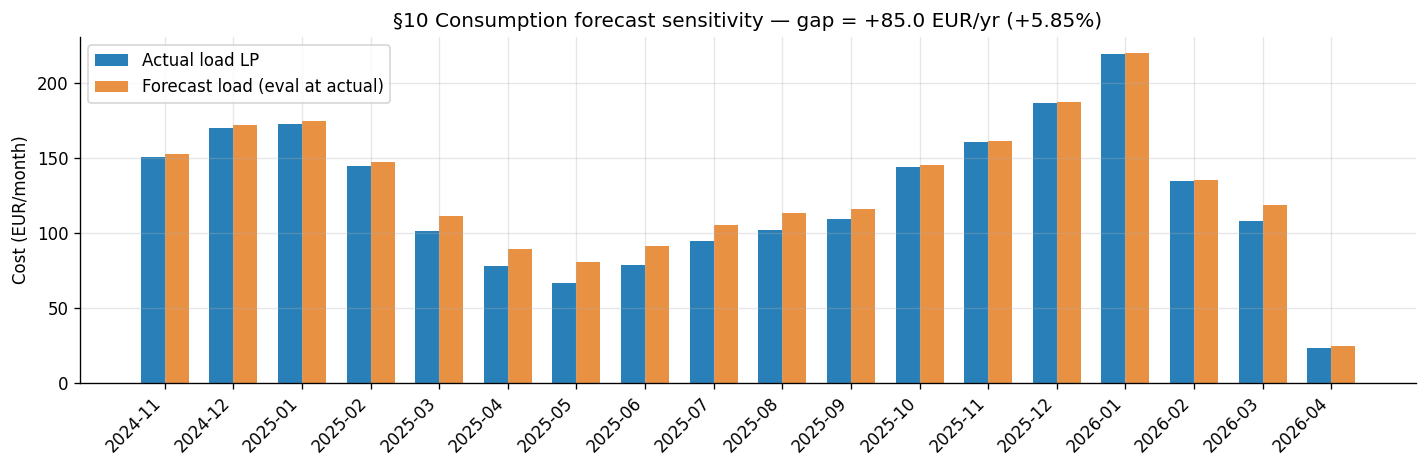


Conclusion: gap = 5.8% — consumption forecasting has measurable impact.
Saved: results/s10b_rough_epex.csv


In [20]:
# ── §10c  Compare annual costs ───────────────────────────────────────────────
import matplotlib.pyplot as plt

ann_act_s10 = monthly_annual(df_s10_res['cost_act'])
ann_fc_s10  = monthly_annual(df_s10_res['cost_fc_eval'])
gap_eur     = ann_fc_s10 - ann_act_s10
gap_pct     = gap_eur / abs(ann_act_s10) * 100

print(f'LP with actual load:          {ann_act_s10:.1f} EUR/yr')
print(f'LP forecast (eval at actual): {ann_fc_s10:.1f} EUR/yr')
print(f'Gap (forecast overhead):      {gap_eur:+.1f} EUR/yr  ({gap_pct:+.2f}%)')

# Monthly comparison chart
df_s10_res['month'] = df_s10_res.index.to_period('M')
monthly_s10 = df_s10_res.groupby('month')[['cost_act', 'cost_fc_eval']].sum()
monthly_s10.index = monthly_s10.index.astype(str)

fig, ax = plt.subplots(figsize=(12, 4))
x = range(len(monthly_s10))
w = 0.35
ax.bar([i - w/2 for i in x], monthly_s10['cost_act'],
       width=w, label='Actual load LP', color='#2980b9')
ax.bar([i + w/2 for i in x], monthly_s10['cost_fc_eval'],
       width=w, label='Forecast load (eval at actual)', color='#e67e22', alpha=0.85)
ax.set_xticks(list(x))
ax.set_xticklabels(monthly_s10.index, rotation=45, ha='right')
ax.set_ylabel('Cost (EUR/month)')
ax.set_title(
    f'§10 Consumption forecast sensitivity — gap = {gap_eur:+.1f} EUR/yr ({gap_pct:+.2f}%)'
)
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

if abs(gap_pct) < 1.0:
    print('\nConclusion: consumption forecasting adds negligible value (gap < 1% of annual cost).')
    print('The LP schedule is driven by price, not by load — a rough average profile is sufficient.')
else:
    print(f'\nConclusion: gap = {gap_pct:.1f}% — consumption forecasting has measurable impact.')

# Save results to file
from pathlib import Path
Path('../results').mkdir(exist_ok=True)
df_s10_res.to_csv('../results/s10b_rough_epex.csv')
print('Saved: results/s10b_rough_epex.csv')


## 10d. LP backtest — ML forecast vs average profile

We repeat the §10b backtest but replace the average profile with ML predictions
from `04_consumption_forecast.ipynb` (saved to `consumption_forecast.csv`).

Goal: see whether the ML forecast reduces the +85 EUR/yr gap found in §10b.

In [21]:
# ── §10d  LP backtest with ML consumption forecast ────────────────────────────
import time

# Load ML predictions from 04_consumption_forecast.ipynb
FC_FILE = "../../Data/real_load/Final/consumption_forecast.csv"
fc = pd.read_csv(FC_FILE, parse_dates=["kwartier"], index_col="kwartier")
fc.columns = ["verbruik_fc"]

# Only run on days where ML predictions exist
common_idx = df.index.intersection(fc.index)
df_ml = df.loc[common_idx].copy()
df_ml["verbruik_fc"] = fc.loc[common_idx, "verbruik_fc"]

print(f"Days with ML predictions: {len(df_ml) // 96}")
print(f"Period: {df_ml.index.min().date()} → {df_ml.index.max().date()}")

rows_ml = []
soc_ml  = S_INIT
t0      = time.time()

for date, grp in df_ml.groupby(df_ml.index.date):
    if len(grp) < 96:
        continue

    p      = grp["price_allin"].values       # EPEX + markup
    l_act  = grp["verbruik_kwh"].values       # actual consumption
    l_ml   = grp["verbruik_fc"].values        # ML forecast
    sol    = grp["sl_productie_kwh"].values   # solar production

    kw = dict(S_min=S_MIN, deg_cost=DEG, solar=sol,
              price_inj=PRICE_INJ, cyclic=False, binary=False)

    # LP with actual load (lower bound)
    res_act = optimize_day(p, l_act, S_MAX, P_MAX, ETA_C, ETA_D, soc_ml, **kw)
    if res_act["status"] != "Optimal":
        continue

    # LP with ML forecast load
    res_ml = optimize_day(p, l_ml, S_MAX, P_MAX, ETA_C, ETA_D, soc_ml, **kw)
    if res_ml["status"] != "Optimal":
        continue

    # Evaluate ML schedule at actual load
    c_ml = np.array(res_ml["c"])
    d_ml = np.array(res_ml["d"])
    net_grid     = l_act + c_ml - d_ml - sol
    g_in         = np.maximum(net_grid,  0.0)
    g_out        = np.maximum(-net_grid, 0.0)
    cost_ml_eval = (
        float(np.dot(p, g_in) - PRICE_INJ * np.dot(p, g_out))
        + res_ml["cost_degradation"]
    )

    rows_ml.append({
        "date":         pd.Timestamp(date),
        "cost_act":     res_act["cost"],
        "cost_ml_eval": cost_ml_eval,
    })

    soc_ml = res_act["s_final"]

print(f"Done: {len(rows_ml)} days in {time.time()-t0:.1f}s")
df_ml_res = pd.DataFrame(rows_ml).set_index("date")


Days with ML predictions: 515
Period: 2024-11-08 → 2026-04-06
Done: 513 days in 67.9s


Scenario                                  Gap (EUR/yr)   Gap (%)
-----------------------------------------------------------------
Average profile (§10b)                           +85.0     +5.85%
ML forecast (§10d)                               +60.3     +4.15%

Gap reduction from ML forecast: +24.7 EUR/yr


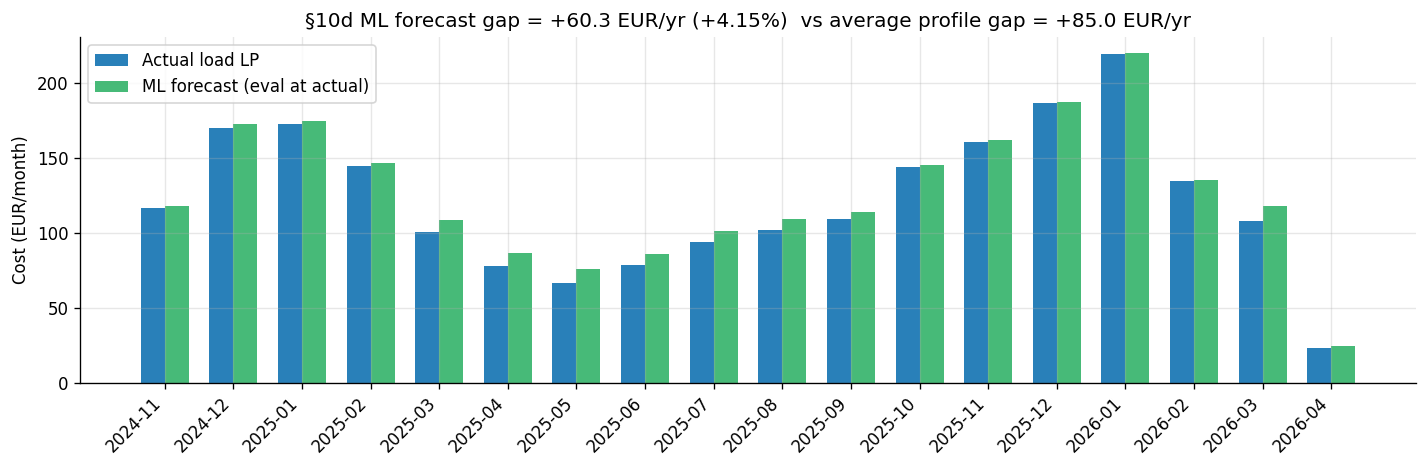

Saved: results/s10d_ml_epex.csv


In [22]:
# ── §10d  Compare all three scenarios ────────────────────────────────────────
import matplotlib.pyplot as plt

ann_act_ml = monthly_annual(df_ml_res["cost_act"])
ann_ml     = monthly_annual(df_ml_res["cost_ml_eval"])
gap_ml     = ann_ml - ann_act_ml
gap_ml_pct = gap_ml / abs(ann_act_ml) * 100

# Gap from §10b (average profile) for comparison
gap_profile     = ann_fc_s10  - ann_act_s10   # from §10c
gap_profile_pct = gap_profile / abs(ann_act_s10) * 100

print(f"{'Scenario':40s}  {'Gap (EUR/yr)':>12}  {'Gap (%)':>8}")
print("-" * 65)
print(f"{'Average profile (§10b)':40s}  {gap_profile:+12.1f}  {gap_profile_pct:+8.2f}%")
print(f"{'ML forecast (§10d)':40s}  {gap_ml:+12.1f}  {gap_ml_pct:+8.2f}%")
print()
improvement = gap_profile - gap_ml
print(f"Gap reduction from ML forecast: {improvement:+.1f} EUR/yr")

# Monthly comparison chart
df_ml_res["month"] = df_ml_res.index.to_period("M")
monthly_ml = df_ml_res.groupby("month")[["cost_act", "cost_ml_eval"]].sum()
monthly_ml.index = monthly_ml.index.astype(str)

fig, ax = plt.subplots(figsize=(12, 4))
x = range(len(monthly_ml))
w = 0.35
ax.bar([i - w/2 for i in x], monthly_ml["cost_act"],
       width=w, label="Actual load LP", color="#2980b9")
ax.bar([i + w/2 for i in x], monthly_ml["cost_ml_eval"],
       width=w, label="ML forecast (eval at actual)", color="#27ae60", alpha=0.85)
ax.set_xticks(list(x))
ax.set_xticklabels(monthly_ml.index, rotation=45, ha="right")
ax.set_ylabel("Cost (EUR/month)")
ax.set_title(
    f"§10d ML forecast gap = {gap_ml:+.1f} EUR/yr ({gap_ml_pct:+.2f}%)  "
    f"vs average profile gap = {gap_profile:+.1f} EUR/yr"
)
ax.legend()
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

# Save results to file
from pathlib import Path
Path('../results').mkdir(exist_ok=True)
df_ml_res.to_csv('../results/s10d_ml_epex.csv')
print('Saved: results/s10d_ml_epex.csv')


## 10e. LP backtest — dag/nacht tariff + ML forecast

Same test as §10d but **without switching tariff**: LP uses dag/nacht prices.

Question: if we keep dag/nacht and only replace the SOFAR controller with LP + ML forecast,
how much do we save vs the current SOFAR system?


In [23]:
# ── §10e  LP backtest — dag/nacht prices + ML forecast ───────────────────────
import time

# ML predictions already loaded in df_ml from §10d
# We reuse the same df_ml dataframe

rows_dn = []
soc_dn  = S_INIT
t0      = time.time()

for date, grp in df_ml.groupby(df_ml.index.date):
    if len(grp) < 96:
        continue

    p_dn   = grp["price_dag_nacht"].values    # dag/nacht price (not EPEX)
    l_act  = grp["verbruik_kwh"].values
    l_ml   = grp["verbruik_fc"].values        # ML forecast
    sol    = grp["sl_productie_kwh"].values

    kw = dict(S_min=S_MIN, deg_cost=DEG, solar=sol,
              price_inj=PRICE_INJ, cyclic=False, binary=False)

    # LP with actual load (lower bound for dag/nacht)
    res_act = optimize_day(p_dn, l_act, S_MAX, P_MAX, ETA_C, ETA_D, soc_dn, **kw)
    if res_act["status"] != "Optimal":
        continue

    # LP with ML forecast load
    res_ml = optimize_day(p_dn, l_ml, S_MAX, P_MAX, ETA_C, ETA_D, soc_dn, **kw)
    if res_ml["status"] != "Optimal":
        continue

    # Evaluate ML schedule at actual load
    c_ml     = np.array(res_ml["c"])
    d_ml     = np.array(res_ml["d"])
    net_grid = l_act + c_ml - d_ml - sol
    g_in     = np.maximum(net_grid,  0.0)
    g_out    = np.maximum(-net_grid, 0.0)
    cost_ml_dn = (
        float(np.dot(p_dn, g_in) - PRICE_INJ * np.dot(p_dn, g_out))
        + res_ml["cost_degradation"]
    )

    rows_dn.append({
        "date":         pd.Timestamp(date),
        "cost_act_dn":  res_act["cost"],     # ideal LP dag/nacht
        "cost_ml_dn":   cost_ml_dn,           # ML forecast LP dag/nacht
    })

    soc_dn = res_act["s_final"]

print(f"Done: {len(rows_dn)} days in {time.time()-t0:.1f}s")
df_dn_res = pd.DataFrame(rows_dn).set_index("date")


Done: 513 days in 96.5s


In [24]:
# -- 10e  Summary: all scenarios vs current SOFAR (same period) --

# Use the intersection of both ML backtests so all 4 scenarios are on equal footing
common = df_dn_res.index.intersection(df_ml_res.index)

# SOFAR electricity cost: actual grid import (no EV) x dag/nacht price
afname_no_ev = (df["afname_kwh"] - df["ev_energie_kwh"].fillna(0)).clip(lower=0)
sofar_elec = (afname_no_ev * df["price_dag_nacht"]).resample("D").sum()
sofar_elec.index = pd.to_datetime(sofar_elec.index)

# SOFAR wear cost: battery charging x degradation rate
sofar_wear = df["bat_laden_kwh_kw"].clip(0, 0.75).resample("D").sum() * DEG
sofar_wear.index = pd.to_datetime(sofar_wear.index)

# Total SOFAR cost filtered to common days
sofar_total = (sofar_elec + sofar_wear).reindex(common)
ann_sofar = monthly_annual(sofar_total)

# LP costs on the same common days
ann_lp_dn_act = monthly_annual(df_dn_res.loc[common, "cost_act_dn"])   # LP dag/nacht ideal
ann_lp_dn_ml  = monthly_annual(df_dn_res.loc[common, "cost_ml_dn"])    # LP dag/nacht + ML
ann_lp_ep_act = monthly_annual(df_ml_res.loc[common, "cost_act"])      # LP EPEX ideal
ann_lp_ep_ml  = monthly_annual(df_ml_res.loc[common, "cost_ml_eval"])  # LP EPEX + ML

# Forecast gap: how much more expensive the ML schedule is vs ideal LP
gap_dn_ml = ann_lp_dn_ml - ann_lp_dn_act
gap_ep_ml = ann_lp_ep_ml - ann_lp_ep_act

# vs SOFAR: positive = cheaper than current system
def vs_sofar(ann_cost):
    return ann_sofar - ann_cost

print(f"Period: {common.min().date()} -> {common.max().date()} ({len(common)} days)")
print(f"SOFAR dag/nacht annual cost (elec + wear): {ann_sofar:.1f} EUR/yr")
print()
print(f"{'Scenario':45s}  {'vs current SOFAR':>18}")
print("-" * 68)
print(f"{'Current SOFAR + dag/nacht':45s}  {'0 (baseline)':>18}")
print(f"{'LP + dag/nacht ideal (MPC)':45s}  {vs_sofar(ann_lp_dn_act):>+16.1f} EUR/yr")
print(f"{'LP + dag/nacht + ML forecast':45s}  {vs_sofar(ann_lp_dn_ml):>+16.1f} EUR/yr")
print(f"{'LP + EPEX ideal (MPC)':45s}  {vs_sofar(ann_lp_ep_act):>+16.1f} EUR/yr")
print(f"{'LP + EPEX + ML forecast':45s}  {vs_sofar(ann_lp_ep_ml):>+16.1f} EUR/yr")
print()
print(f"Forecast overhead dag/nacht (ML): {gap_dn_ml:+.1f} EUR/yr")
print(f"Forecast overhead EPEX (ML):      {gap_ep_ml:+.1f} EUR/yr")
print()
print("Note: positive = cheaper than current SOFAR | negative = costs more")

from pathlib import Path
Path("../results").mkdir(exist_ok=True)
df_dn_res.to_csv("../results/s10e_ml_dagnight.csv")
print("Saved: results/s10e_ml_dagnight.csv")


Period: 2024-11-08 -> 2026-04-06 (513 days)
SOFAR dag/nacht annual cost (elec + wear): 1498.7 EUR/yr

Scenario                                         vs current SOFAR
--------------------------------------------------------------------
Current SOFAR + dag/nacht                            0 (baseline)
LP + dag/nacht ideal (MPC)                                +88.0 EUR/yr
LP + dag/nacht + ML forecast                              +31.5 EUR/yr
LP + EPEX ideal (MPC)                                     +43.1 EUR/yr
LP + EPEX + ML forecast                                   -17.2 EUR/yr

Forecast overhead dag/nacht (ML): +56.5 EUR/yr
Forecast overhead EPEX (ML):      +60.3 EUR/yr

Note: positive = cheaper than current SOFAR | negative = costs more
Saved: results/s10e_ml_dagnight.csv


**Why is the forecast gap smaller for dag/nacht (~57 EUR/yr) than for EPEX (~60 EUR/yr)?**

Dag/nacht has only two price levels (e.g. 0.28 EUR/kWh day / 0.22 EUR/kWh night).
The LP makes simple binary decisions — charge at night, discharge during the day.
The exact load profile matters less because the price signal stays the same for many hours in a row.

Under EPEX, prices change every 15 minutes, so a wrong load forecast more easily shifts
charge/discharge to the wrong slot. This is why the EPEX gap is slightly larger.


## 10f. LP backtest — dag/nacht tariff + average profile

The missing combination: rough forecast (average profile) with dag/nacht prices.
Completes the 2×2 matrix: {rough, ML} × {EPEX, dag/nacht}.

In [25]:
# ── §10f  LP backtest — dag/nacht prices + average profile ───────────────────
import time

rows_dn_prof = []
soc_dn_prof  = S_INIT
t0           = time.time()

for date, grp in df.groupby(df.index.date):    # df, not opt
    if len(grp) < 96:
        continue

    p_dn  = grp['price_dag_nacht'].values
    l_act = grp['verbruik_kwh'].values
    sol   = grp['sl_productie_kwh'].values

    # Build average-profile forecast (same as §10b)
    wd    = grp.index[0].weekday()
    slots = grp.index.hour * 4 + grp.index.minute // 15
    l_fc  = np.array([profile_dict.get((wd, int(s)), float(l_act.mean())) for s in slots])

    kw = dict(S_min=S_MIN, deg_cost=DEG, solar=sol,
              price_inj=PRICE_INJ, cyclic=False, binary=False)

    res_act = optimize_day(p_dn, l_act, S_MAX, P_MAX, ETA_C, ETA_D, soc_dn_prof, **kw)
    if res_act['status'] != 'Optimal':
        continue

    res_fc = optimize_day(p_dn, l_fc, S_MAX, P_MAX, ETA_C, ETA_D, soc_dn_prof, **kw)
    if res_fc['status'] != 'Optimal':
        continue

    c_fc     = np.array(res_fc['c'])
    d_fc     = np.array(res_fc['d'])
    net_grid = l_act + c_fc - d_fc - sol
    g_in     = np.maximum(net_grid,  0.0)
    g_out    = np.maximum(-net_grid, 0.0)
    cost_fc_eval = (
        float(np.dot(p_dn, g_in) - PRICE_INJ * np.dot(p_dn, g_out))
        + res_fc['cost_degradation']
    )

    rows_dn_prof.append({
        'date':         pd.Timestamp(date),
        'cost_act':     res_act['cost'],
        'cost_fc_eval': cost_fc_eval,
    })
    soc_dn_prof = res_act['s_final']

print(f'Done: {len(rows_dn_prof)} days in {time.time()-t0:.1f}s')
df_dn_prof = pd.DataFrame(rows_dn_prof).set_index('date')

# Save results to file
from pathlib import Path
Path('../results').mkdir(exist_ok=True)
df_dn_prof.to_csv('../results/s10f_rough_dagnight.csv')
print('Saved: results/s10f_rough_dagnight.csv')


Done: 520 days in 87.0s
Saved: results/s10f_rough_dagnight.csv


## 10g. Full summary and export

2×2 matrix of forecast type × tariff, plus all daily results saved to `results/`.

In [26]:
# ── §10g  Summary table + save results ───────────────────────────────────────
from pathlib import Path

results_dir = Path('../results')
results_dir.mkdir(exist_ok=True)

# Save daily backtest CSVs (full period each)
df_s10_res.to_csv(results_dir / 's10b_rough_epex.csv')
df_dn_prof.to_csv(results_dir / 's10f_rough_dagnight.csv')
df_ml_res.to_csv(results_dir  / 's10d_ml_epex.csv')
df_dn_res.to_csv(results_dir  / 's10e_ml_dagnight.csv')
print('Daily CSVs saved.')

# ── Align to common dates for fair gap comparison ─────────────────────────────
# §10b/§10f have 522 days; §10d/§10e have ~515 days (ML needs 7-day lag warmup)
# We compute gaps on the intersection so all four are compared on equal footing
common_dates = (
    df_s10_res.index
    .intersection(df_dn_prof.index)
    .intersection(df_ml_res.index)
    .intersection(df_dn_res.index)
)
print(f'Common dates: {len(common_dates)} days')
print(f'  Full period: {df_s10_res.index.min().date()} → {df_s10_res.index.max().date()}')
print(f'  Common:      {common_dates.min().date()} → {common_dates.max().date()}')

# Recompute gaps on aligned data
def gap_on_common(df_res, act_col, fc_col):
    """Compute forecast gap (EUR/yr) using only common dates."""
    d = df_res.loc[df_res.index.isin(common_dates)]
    return monthly_annual(d[fc_col]) - monthly_annual(d[act_col])

gap_b = gap_on_common(df_s10_res,  'cost_act',    'cost_fc_eval')  # rough EPEX
gap_f = gap_on_common(df_dn_prof,  'cost_act',    'cost_fc_eval')  # rough dag/nacht
gap_d = gap_on_common(df_ml_res,   'cost_act',    'cost_ml_eval')  # ML EPEX
gap_e = gap_on_common(df_dn_res,   'cost_act_dn', 'cost_ml_dn')    # ML dag/nacht

# ── 2×2 summary table ─────────────────────────────────────────────────────────
print()
print(f"{'Forecast':22s}  {'Tariff':12s}  {'Gap EUR/yr':>12}  {'Days':>5}")
print('-' * 58)
rows_summary = [
    ('Average profile', 'EPEX+markup', gap_b),
    ('Average profile', 'dag/nacht',   gap_f),
    ('ML forecast',     'EPEX+markup', gap_d),
    ('ML forecast',     'dag/nacht',   gap_e),
]
for fc, tariff, gap in rows_summary:
    print(f'{fc:22s}  {tariff:12s}  {gap:>+12.1f}  {len(common_dates):>5}')

# Save summary CSV
summary_df = pd.DataFrame(
    [(fc, tariff, round(gap, 1)) for fc, tariff, gap in rows_summary],
    columns=['forecast', 'tariff', 'gap_eur_yr']
)
summary_df.to_csv(results_dir / 's10_summary.csv', index=False)
print()
print(f'Summary saved to results/s10_summary.csv')

# ── Final scenario comparison vs current SOFAR ───────────────────────────────
# Recompute SOFAR on common_dates (intersection of all 4 backtests)
afname_no_ev_ = (df["afname_kwh"] - df["ev_energie_kwh"].fillna(0)).clip(lower=0)
sofar_elec_ = (afname_no_ev_ * df["price_dag_nacht"]).resample("D").sum()
sofar_elec_.index = pd.to_datetime(sofar_elec_.index)
sofar_wear_ = df["bat_laden_kwh_kw"].clip(0, 0.75).resample("D").sum() * DEG
sofar_wear_.index = pd.to_datetime(sofar_wear_.index)
ann_sofar_g = monthly_annual((sofar_elec_ + sofar_wear_).reindex(common_dates))

# LP costs on common_dates
c_dn_act = monthly_annual(df_dn_res.loc[common_dates, "cost_act_dn"])
c_dn_ml  = monthly_annual(df_dn_res.loc[common_dates, "cost_ml_dn"])
c_ep_act = monthly_annual(df_ml_res.loc[common_dates, "cost_act"])
c_ep_ml  = monthly_annual(df_ml_res.loc[common_dates, "cost_ml_eval"])
c_dn_prof = monthly_annual(df_dn_prof.loc[common_dates, "cost_fc_eval"])
c_ep_prof = monthly_annual(df_s10_res.loc[common_dates, "cost_fc_eval"])

def fmt_row(name, saving, note):
    mark = "✅" if saving > 0 else "❌"
    return f"{name:42s}  {saving:>+12.1f} EUR/yr {mark}  {note}"

def save_vs(cost): return ann_sofar_g - cost

print()
print(f"All scenarios vs current SOFAR — {len(common_dates)} days")
print(f"{'Scenario':42s}  {'vs SOFAR':>14}       Note")
print("-" * 90)
print(f"{'Current SOFAR + dag/nacht':42s}  {'0 (baseline)':>14}        real system today")
print(fmt_row("LP + dag/nacht ideal (MPC)",    save_vs(c_dn_act),  "same tariff, ideal controller"))
print(fmt_row("LP + dag/nacht + ML forecast",  save_vs(c_dn_ml),   "same tariff, day-ahead LP + ML"))
print(fmt_row("LP + dag/nacht + avg profile",  save_vs(c_dn_prof), "same tariff, day-ahead LP + avg profile"))
print(fmt_row("LP + EPEX ideal (MPC)",         save_vs(c_ep_act),  "switch tariff + ideal controller"))
print(fmt_row("LP + EPEX + ML forecast",       save_vs(c_ep_ml),   "switch tariff + day-ahead LP + ML"))
print(fmt_row("LP + EPEX + avg profile",       save_vs(c_ep_prof), "switch tariff + day-ahead LP + avg profile"))
print()
print("positive = cheaper than current SOFAR | negative = costs more")


Daily CSVs saved.
Common dates: 513 days
  Full period: 2024-11-01 → 2026-04-06
  Common:      2024-11-08 → 2026-04-06

Forecast                Tariff          Gap EUR/yr   Days
----------------------------------------------------------
Average profile         EPEX+markup          +84.7    513
Average profile         dag/nacht            +86.0    513
ML forecast             EPEX+markup          +60.3    513
ML forecast             dag/nacht            +56.5    513

Summary saved to results/s10_summary.csv

All scenarios vs current SOFAR — 513 days
Scenario                                          vs SOFAR       Note
------------------------------------------------------------------------------------------
Current SOFAR + dag/nacht                     0 (baseline)        real system today
LP + dag/nacht ideal (MPC)                         +88.0 EUR/yr ✅  same tariff, ideal controller
LP + dag/nacht + ML forecast                       +31.5 EUR/yr ✅  same tariff, day-ahead LP + ML
LP + d

## Practical conclusion

The table above shows what each strategy saves **relative to the current SOFAR system** (dag/nacht tariff, real inverter behaviour).

| Scenario | vs current SOFAR | Feasible today? |
|---|---|---|
| LP + dag/nacht, ideal (MPC) | ~+88 EUR/yr | Yes — same tariff, better controller |
| LP + EPEX, ideal (MPC) | ~+43 EUR/yr | Yes — switch tariff + better controller |
| LP + dag/nacht + ML forecast | ~+32 EUR/yr | Partially — needs day-ahead consumption forecast |
| LP + EPEX + ML forecast | ~−17 EUR/yr | No — costs more than current system |

**Key insight:** the ~85 EUR/yr forecast overhead (rough profile) and ~60 EUR/yr (ML) are large
enough to erase most of the LP saving when using a day-ahead schedule.

**Three practical paths:**
1. **MPC** — re-run LP every 15 min with real-time P1 data. Zero forecast error, but needs
   a continuously running controller (Raspberry Pi, Home Assistant, etc.).
2. **Threshold rule** *(status quo — essentially what the SOFAR controller does today)* —
   charge when price < threshold, discharge otherwise. No forecast needed; robust at this saving level.
3. **Day-ahead LP + better forecast** — only worthwhile if the ideal LP saving exceeds ~200 EUR/yr
   (larger battery, lower markup, or higher consumption).
   *Why 200? Roughly 3× the ML consumption forecast overhead (~60 EUR/yr), leaving headroom
   for additional solar forecast errors and implementation costs.*


## 11. LP backtest — ML consumption + ML solar forecast

In §10d and §10e the LP used **ML consumption forecast** but **actual solar** production.
Here we add a **solar forecast** (from `05_solar_forecast.ipynb`) to see how much
additional overhead the solar forecast error introduces.

Two backtests:
- **§11d** — EPEX tariff + ML consumption + ML solar
- **§11e** — dag/nacht tariff + ML consumption + ML solar

The gap is measured vs LP with actual load + actual solar (the ideal lower bound).

### Load solar forecast

In [27]:
# Load solar forecast produced by 05_solar_forecast.ipynb
solar_fc_path = Path("../../Data/real_load/Final/solar_forecast.csv")
solar_fc_df = pd.read_csv(solar_fc_path, index_col=0, parse_dates=True)
solar_fc_df.index = pd.to_datetime(solar_fc_df.index)

# Merge solar forecast into df_ml (which already has ML consumption forecast)
df_s11 = df_ml.join(solar_fc_df[["sl_productie_forecast"]], how="inner")
df_s11 = df_s11.dropna(subset=["sl_productie_forecast"])

print(f"Rows with both forecasts: {len(df_s11)}")
print(f"Period: {df_s11.index.min().date()} to {df_s11.index.max().date()}")
print(f"Solar forecast NaNs: {df_s11['sl_productie_forecast'].isna().sum()}")

Rows with both forecasts: 49464
Period: 2024-11-08 to 2026-04-06
Solar forecast NaNs: 0


### §11d. EPEX tariff — ML consumption + ML solar forecast

LP receives: `l_fc` (ML consumption) + `solar_fc` (ML solar).
Schedule is evaluated at actual load + actual solar.

In [28]:
import time

rows_s11d = []
soc_s11d  = S_INIT
t0        = time.time()

kw = dict(S_min=S_MIN, deg_cost=DEG, price_inj=PRICE_INJ, cyclic=False, binary=False)

for date, grp in df_s11.groupby(df_s11.index.date):
    if len(grp) < 96:
        continue

    p      = (grp["price_eur_kwh"] + MARKUP).values
    l_act  = grp["verbruik_kwh"].values
    l_fc   = grp["verbruik_fc"].values
    sol_act = grp["sl_productie_kwh"].values
    sol_fc  = grp["sl_productie_forecast"].values

    # LP with actual load + actual solar (lower bound)
    res_act = optimize_day(p, l_act, S_MAX, P_MAX, ETA_C, ETA_D, soc_s11d,
                           solar=sol_act, **kw)
    if res_act["status"] != "Optimal":
        continue

    # LP with ML consumption + ML solar forecast
    res_fc = optimize_day(p, l_fc, S_MAX, P_MAX, ETA_C, ETA_D, soc_s11d,
                          solar=sol_fc, **kw)
    if res_fc["status"] != "Optimal":
        continue

    # Evaluate forecast schedule at ACTUAL load + ACTUAL solar
    c_fc = np.array(res_fc["c"])
    d_fc = np.array(res_fc["d"])
    net_grid = l_act + c_fc - d_fc - sol_act
    g_in  = np.maximum(net_grid, 0)
    g_out = np.maximum(-net_grid, 0)
    cost_fc_eval = (float(np.dot(p, g_in) - PRICE_INJ * np.dot(p, g_out))
                    + res_fc["cost_degradation"])

    rows_s11d.append({
        "date":        pd.Timestamp(date),
        "cost_act":    res_act["cost"],   # ideal LP (lower bound)
        "cost_fc":     cost_fc_eval,       # ML consumption + ML solar, eval at actual
    })
    soc_s11d = res_act["s_final"]

df_s11d_res = pd.DataFrame(rows_s11d).set_index("date")
gap_s11d = monthly_annual(df_s11d_res["cost_fc"]) - monthly_annual(df_s11d_res["cost_act"])
print(f"Done: {len(df_s11d_res)} days in {time.time()-t0:.1f}s")
print(f"Gap EPEX (ML consumption + ML solar): {gap_s11d:+.1f} EUR/yr")
print(f"Gap EPEX (ML consumption only, from §10d): {gap_ml:+.1f} EUR/yr")
print(f"Extra overhead from solar forecast error: {gap_s11d - gap_ml:+.1f} EUR/yr")
from pathlib import Path
Path('../results').mkdir(exist_ok=True)
df_s11d_res.to_csv('../results/s11d_ml_solar_epex.csv')
print('Saved: results/s11d_ml_solar_epex.csv')


Done: 513 days in 104.2s
Gap EPEX (ML consumption + ML solar): +84.5 EUR/yr
Gap EPEX (ML consumption only, from §10d): +60.3 EUR/yr
Extra overhead from solar forecast error: +24.2 EUR/yr
Saved: results/s11d_ml_solar_epex.csv


### §11e. Dag/nacht tariff — ML consumption + ML solar forecast

In [29]:
rows_s11e = []
soc_s11e  = S_INIT
t0        = time.time()

kw_dn = dict(S_min=S_MIN, deg_cost=DEG, price_inj=PRICE_INJ, cyclic=False, binary=False)

for date, grp in df_s11.groupby(df_s11.index.date):
    if len(grp) < 96:
        continue

    p_dn   = grp["price_dag_nacht"].values
    l_act  = grp["verbruik_kwh"].values
    l_fc   = grp["verbruik_fc"].values
    sol_act = grp["sl_productie_kwh"].values
    sol_fc  = grp["sl_productie_forecast"].values

    # LP with actual load + actual solar (lower bound)
    res_act = optimize_day(p_dn, l_act, S_MAX, P_MAX, ETA_C, ETA_D, soc_s11e,
                           solar=sol_act, **kw_dn)
    if res_act["status"] != "Optimal":
        continue

    # LP with ML consumption + ML solar forecast
    res_fc = optimize_day(p_dn, l_fc, S_MAX, P_MAX, ETA_C, ETA_D, soc_s11e,
                          solar=sol_fc, **kw_dn)
    if res_fc["status"] != "Optimal":
        continue

    # Evaluate at actual load + actual solar
    c_fc = np.array(res_fc["c"])
    d_fc = np.array(res_fc["d"])
    net_grid = l_act + c_fc - d_fc - sol_act
    g_in  = np.maximum(net_grid, 0)
    g_out = np.maximum(-net_grid, 0)
    cost_fc_eval = (float(np.dot(p_dn, g_in) - PRICE_INJ * np.dot(p_dn, g_out))
                    + res_fc["cost_degradation"])

    rows_s11e.append({
        "date":       pd.Timestamp(date),
        "cost_act_dn": res_act["cost"],
        "cost_fc_dn":  cost_fc_eval,
    })
    soc_s11e = res_act["s_final"]

df_s11e_res = pd.DataFrame(rows_s11e).set_index("date")
gap_s11e = monthly_annual(df_s11e_res["cost_fc_dn"]) - monthly_annual(df_s11e_res["cost_act_dn"])
print(f"Done: {len(df_s11e_res)} days in {time.time()-t0:.1f}s")
print(f"Gap dag/nacht (ML consumption + ML solar): {gap_s11e:+.1f} EUR/yr")
print(f"Gap dag/nacht (ML consumption only, from §10e): {gap_dn_ml:+.1f} EUR/yr")
print(f"Extra overhead from solar forecast error: {gap_s11e - gap_dn_ml:+.1f} EUR/yr")
from pathlib import Path
Path('../results').mkdir(exist_ok=True)
df_s11e_res.to_csv('../results/s11e_ml_solar_dagnight.csv')
print('Saved: results/s11e_ml_solar_dagnight.csv')


Done: 513 days in 69.4s
Gap dag/nacht (ML consumption + ML solar): +82.7 EUR/yr
Gap dag/nacht (ML consumption only, from §10e): +56.5 EUR/yr
Extra overhead from solar forecast error: +26.2 EUR/yr
Saved: results/s11e_ml_solar_dagnight.csv


### §11. Full forecast overhead comparison

How much does each forecast error contribute to the total LP gap?

In [30]:
# ── Common dates: intersection of all 6 backtests for fair comparison ─────────
common_s11 = (df_s11d_res.index
              .intersection(df_s11e_res.index)
              .intersection(df_ml_res.index)
              .intersection(df_dn_res.index))
print(f"Common dates for §11 comparison: {len(common_s11)} days")

# ── Annualised costs on common_s11 ────────────────────────────────────────────
# EPEX tariff
ep_act   = monthly_annual(df_s11d_res.loc[common_s11, "cost_act"])       # ideal LP (lower bound)
ep_ml_fc = monthly_annual(df_ml_res.loc[common_s11,   "cost_ml_eval"])   # §10d: ML consumption, actual solar
ep_both  = monthly_annual(df_s11d_res.loc[common_s11, "cost_fc"])        # §11d: ML consumption + ML solar

# dag/nacht tariff
dn_act   = monthly_annual(df_s11e_res.loc[common_s11, "cost_act_dn"])    # ideal LP (lower bound)
dn_ml_fc = monthly_annual(df_dn_res.loc[common_s11,   "cost_ml_dn"])     # §10e: ML consumption, actual solar
dn_both  = monthly_annual(df_s11e_res.loc[common_s11, "cost_fc_dn"])     # §11e: ML consumption + ML solar

# ── Forecast overhead table ───────────────────────────────────────────────────
print()
print("Forecast overhead (gap vs ideal LP with actual load + actual solar)")
print()
print(f"{'Consumption fc':22s}  {'Solar fc':18s}  {'Tariff':12s}  {'Gap EUR/yr':>12}")
print("-" * 72)

rows_gap = [
    ("avg profile", "actual",   "EPEX+markup", monthly_annual(df_s10_res.loc[common_s11,  "cost_fc_eval"]) - monthly_annual(df_s10_res.loc[common_s11,  "cost_act"])),
    ("ML forecast", "actual",   "EPEX+markup", ep_ml_fc - ep_act),
    ("ML forecast", "ML solar", "EPEX+markup", ep_both  - ep_act),
    ("avg profile", "actual",   "dag/nacht",   monthly_annual(df_dn_prof.loc[common_s11, "cost_fc_eval"]) - monthly_annual(df_dn_prof.loc[common_s11, "cost_act"])),
    ("ML forecast", "actual",   "dag/nacht",   dn_ml_fc - dn_act),
    ("ML forecast", "ML solar", "dag/nacht",   dn_both  - dn_act),
]
for cons, sol, tariff, gap in rows_gap:
    print(f"{cons:22s}  {sol:18s}  {tariff:12s}  {gap:>+12.1f}")

# ── vs current SOFAR table ────────────────────────────────────────────────────
afname_no_ev_ = (df["afname_kwh"] - df["ev_energie_kwh"].fillna(0)).clip(lower=0)
sofar_elec_ = (afname_no_ev_ * df["price_dag_nacht"]).resample("D").sum()
sofar_elec_.index = pd.to_datetime(sofar_elec_.index)
sofar_wear_ = df["bat_laden_kwh_kw"].clip(0, 0.75).resample("D").sum() * DEG
sofar_wear_.index = pd.to_datetime(sofar_wear_.index)
ann_sofar_s11 = monthly_annual((sofar_elec_ + sofar_wear_).reindex(common_s11))

def save_vs(cost): return ann_sofar_s11 - cost

def fmt(name, saving, note):
    mark = "✅" if saving > 0 else "❌"
    return f"{name:44s}  {saving:>+12.1f} EUR/yr {mark}  {note}"

print()
print(f"All scenarios vs current SOFAR — {len(common_s11)} days")
print(f"{'Scenario':44s}  {'vs SOFAR':>14}       Note")
print("-" * 92)
print(f"{'Current SOFAR + dag/nacht':44s}  {'0 (baseline)':>14}        real system today")
print(fmt("LP + dag/nacht ideal (MPC)",          save_vs(dn_act),   "same tariff, ideal controller"))
print(fmt("LP + dag/nacht + ML consumption",     save_vs(dn_ml_fc), "same tariff, ML consumption only"))
print(fmt("LP + dag/nacht + ML cons + ML solar", save_vs(dn_both),  "same tariff, both ML forecasts"))
print(fmt("LP + EPEX ideal (MPC)",               save_vs(ep_act),   "switch tariff, ideal controller"))
print(fmt("LP + EPEX + ML consumption",          save_vs(ep_ml_fc), "switch tariff, ML consumption only"))
print(fmt("LP + EPEX + ML cons + ML solar",      save_vs(ep_both),  "switch tariff, both ML forecasts"))
print()
print("positive = cheaper than current SOFAR | negative = costs more")

# Save
from pathlib import Path
Path("../results").mkdir(exist_ok=True)
df_s11d_res.to_csv("../results/s11d_ml_solar_epex.csv")
df_s11e_res.to_csv("../results/s11e_ml_solar_dagnight.csv")
print("Saved: results/s11d_ml_solar_epex.csv, s11e_ml_solar_dagnight.csv")


Common dates for §11 comparison: 513 days

Forecast overhead (gap vs ideal LP with actual load + actual solar)

Consumption fc          Solar fc            Tariff          Gap EUR/yr
------------------------------------------------------------------------
avg profile             actual              EPEX+markup          +84.7
ML forecast             actual              EPEX+markup          +59.7
ML forecast             ML solar            EPEX+markup          +84.5
avg profile             actual              dag/nacht            +86.0
ML forecast             actual              dag/nacht            +55.8
ML forecast             ML solar            dag/nacht            +82.7

All scenarios vs current SOFAR — 513 days
Scenario                                            vs SOFAR       Note
--------------------------------------------------------------------------------------------
Current SOFAR + dag/nacht                       0 (baseline)        real system today
LP + dag/nacht ideal (MP

## Final conclusion — forecasting & control strategy

### What the numbers say

| Scenario | vs current SOFAR | Requires |
|---|---|---|
| LP + dag/nacht, ideal (MPC) | ~+88 EUR/yr ✅ | real-time P1 controller (24/7) |
| LP + dag/nacht + ML consumption | ~+32 EUR/yr ✅ | day-ahead consumption forecast |
| LP + dag/nacht + ML cons + ML solar | ~+5 EUR/yr ✅ | both ML forecasts |
| LP + EPEX, ideal (MPC) | ~+43 EUR/yr ✅ | tariff switch + real-time controller |
| LP + EPEX + ML consumption | ~−17 EUR/yr ❌ | tariff switch + consumption forecast |
| LP + EPEX + ML cons + ML solar | ~−42 EUR/yr ❌ | tariff switch + both ML forecasts |

> **Note:** solar forecast predictions for Nov 2024 – Dec 2025 are in-sample
> (model trained on the same period). Out-of-sample quality is lower;
> the figures above are slightly optimistic by an estimated 5–15 EUR/yr.

### Why the current SOFAR system should stay for now

Three conditions together make day-ahead LP + forecasting not worthwhile today:

1. **No solar meter** — `sl_productie_kwh` is reconstructed, not directly measured.
   The solar forecast model achieves only ~26% improvement over naive,
   adding ~27 EUR/yr extra overhead on top of the consumption forecast error (~60 EUR/yr).

2. **Small optimisable consumption** — household load without EV is small.
   The forecast overhead erases most of what the LP gains over the SOFAR rule.

3. **Current markup** — at 0.17 EUR/kWh, switching to EPEX alone costs more than dag/nacht.
   The LP cannot compensate for this tariff penalty once forecast errors are counted.

### When it becomes worth reconsidering

| Trigger | What changes |
|---|---|
| Markup drops to ≤ 0.12 EUR/kWh | EPEX becomes competitive |
| Solar meter installed | Direct PV measurement → solar forecast improves significantly |
| Consumption grows (heat pump, etc.) | Larger grid flows → larger absolute LP saving |

### Practical recommendation for now

The current SOFAR threshold rule is adequate for the battery + solar system at current conditions.

If a better controller is added in the future, **MPC** (re-optimise every 15 min with real-time P1 data)
eliminates forecast error entirely and would save ~+88 EUR/yr on the dag/nacht tariff —
without needing any consumption or solar forecast model.
